## SVM

In [1]:
import pandas as pd  # Importando a biblioteca pandas para manipulação e análise de dados em formato tabular
import numpy as np # melhor manipulação numérica
import matplotlib.pyplot as plt # plotar os gráficos

from sklearn.preprocessing import StandardScaler  # Importando o normalizador para padronizar os dados, melhorando o desempenho do modelo
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

import random

# Importações para Oversampling
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

# ==================== REPRODUCIBILITY SETTINGS ====================
# Set global random seed for all libraries
RANDOM_SEED = 42

# Python random module
random.seed(RANDOM_SEED)

# NumPy
np.random.seed(RANDOM_SEED)

# Set environment variable for hash seed (should be set before Python starts, but helps in some cases)
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

# Set path to one folder above the current directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
# ==================================================================

### Definição de parâmetros e diretórios

In [2]:
OVERSAMP_UNDERSAMP_DA_FLOW = 'OVER_FILTERED_BY_MEDIAN_ENTROPY' # OVER_ORIGINAL_CAMPAIGN_DATA ou OVER_FILTERED_BY_MEDIAN_ENTROPY

In [3]:
MODE = 'sentinel'
output_classes = ['PRODES_class', 'Majority_response'] # PRODES_class e Majority_response

if MODE == 'sentinel':
    CAMPAIGN_NAME = 'Sentinel-2 Campaign'

    # Carregando os arquivos CSV de treinamento e teste
    train_file_path = ['data/train/sentinel_big_campaign_with_outliers_train.csv',
                    'data/train/sentinel_big_campaign_percentile_by_task_train.csv',
                    'data/train/sentinel_big_campaign_percentile_global_train.csv',
                    'data/train/sentinel_big_campaign_tukey_train.csv',
                    'data/train/sentinel_big_campaign_zscore_train.csv',
                    'data/train/sentinel_big_campaign_mad_train.csv'
                    ]
    test_file_path = 'data/test/sentinel_big_campaign_test.csv'    # Definindo o caminho do arquivo de teste
    bands_list = [11, 4, 3, 1] # 11, 4, 3, 2, 1. Utilizar qualquer combinação

elif MODE == 'landsat':
    CAMPAIGN_NAME = 'Landsat-8 Campaign'
    train_file_path = ['data/train/landsat_flip_campaign_with_outliers_train.csv',
                       'data/train/landsat_flip_campaign_percentile_by_task_train.csv',
                       'data/train/landsat_flip_campaign_percentile_global_train.csv',
                       'data/train/landsat_flip_campaign_tukey_train.csv',
                       'data/train/landsat_flip_campaign_zscore_train.csv',
                       'data/train/landsat_flip_campaign_mad_train.csv'
                       ]
    test_file_path = 'data/test/landsat_flip_campaign_test.csv'    # Definindo o caminho do arquivo de teste
    bands_list = [6, 4, 3, 1]
CAMPAIGN_NAME_PATH = CAMPAIGN_NAME.replace(' ', '_')  # Sanitized for file paths

### Separando as características (X) e a variável alvo (y) para o conjunto de treinamento, mantendo os dados por banda em linhas separadas


In [4]:
for outlier_remove_approach_train in train_file_path:
    print(outlier_remove_approach_train)


data/train/sentinel_big_campaign_with_outliers_train.csv
data/train/sentinel_big_campaign_percentile_by_task_train.csv
data/train/sentinel_big_campaign_percentile_global_train.csv
data/train/sentinel_big_campaign_tukey_train.csv
data/train/sentinel_big_campaign_zscore_train.csv
data/train/sentinel_big_campaign_mad_train.csv


In [5]:
df_train = []
X_train = []

# lendo os arquivos de treino, por abordagem de remoção de outliers
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    df_train.append(pd.read_csv(outlier_remove_approach_train))

    # df_train[idx] = df_train[idx].sort_values(by=['Task_id'])

    # Removendo algumas colunas desnecessárias, de modo a ficar somente com 4 + 13 features
    X_train.append(df_train[idx].drop(columns=['Task_id', 'Majority_response', 'is_match', 'Entropy', 'Mean_duration_response'])) # Entropia foi retirada, mas será

    #X_train.append(df_train)

df_test = pd.read_csv(test_file_path)    # Lendo o arquivo CSV de teste

### União, em uma só linha (amostra), das features de diferentes bandas

In [6]:
def join_features_band_per_segment(dataframe, columns_to_ignore):

    # lista para guardar as features de um segmento conforme as bandas escolhidas 
    segment_features_join_bands_list = []

    # novo conjunto de treino com estrutura atualizada: colunas -> 13 features x quantidade de bandas selecionadas
    global_list = []

    # pega o tamanho da lista com as bandas para verificar quando passar para o próximo segmento
    bands_len = len(bands_list)

    # controle para pegar as features por segmento
    bands_count = 1

    # percorrendo as linhas do arquivo de treino
    for id, row in dataframe.iterrows():

        # se ainda não pegou todas as features das bandas do segmento atual
        if bands_count <= bands_len:

            # se a banda da linha atual está na lista para seleção
            if row['band'] in bands_list:

                # coloca numa lista, em "sequência" e atualiza a contagem
                segment_features_join_bands_list.extend(list(row[columns_to_ignore:]))
                bands_count += 1
        # se pegou as features para todas as bandas
        else:

            # atualiza a contagem para 2, pois aqui já está na primeira linha das features do próximo 
            bands_count = 2

            # atualiza a lista global (que será o dataset com a nova estrutura)
            global_list.append(segment_features_join_bands_list)

            # se a banda da linha atual estiver na lista, já pega as features de uma vez
            if row['band'] in bands_list:
                segment_features_join_bands_list = list(row[columns_to_ignore:])
            
            # senão, esvazia a lista que coloca as features por banda em sequência
            else:
                segment_features_join_bands_list = []
        
    # para adicionar as features do último segmento
    global_list.append(segment_features_join_bands_list)

    return pd.DataFrame(global_list)

In [7]:
new_X_train = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):

    new_X_train.append(join_features_band_per_segment(X_train[idx], 4)) # ignorando as colunas Segment_id, Study_Area, PRODES_class e band

new_X_test = join_features_band_per_segment(df_test, 4) # idem para o dataframe de teste

len(new_X_train[0])

1800

In [8]:
new_X_test

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
0,0.999739,0.186520,0.967124,2.837907,0.999922,0.037852,11.165106,0.002511,0.002766,0.006133,...,0.866564,0.999982,0.020920,3.409732,0.002241,0.002269,0.011492,0.000495,-0.903900,0.061111
1,0.999754,0.210738,0.957153,2.459114,0.999921,0.034025,9.625718,0.002455,0.002707,0.006328,...,0.893649,0.999974,0.020523,3.496573,0.002227,0.002270,0.010867,0.000725,-0.878562,0.059583
2,0.999830,0.223960,0.935454,1.734821,0.999951,0.023552,6.715324,0.001719,0.001864,0.006328,...,0.615103,0.999981,0.014025,2.382123,0.001595,0.001623,0.010751,0.000512,-0.854344,0.049164
3,0.999777,0.209436,0.952659,2.211912,0.999937,0.030611,8.638213,0.002255,0.002450,0.006409,...,0.777600,0.999973,0.018162,3.036505,0.002042,0.002088,0.011109,0.000713,-0.864859,0.056363
4,0.999785,0.223325,0.949807,2.224579,0.999933,0.030160,8.674992,0.002149,0.002350,0.006210,...,0.726663,0.999979,0.017242,2.834402,0.001926,0.001959,0.011361,0.000581,-0.871164,0.054947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55597,0.999886,0.197827,0.936168,1.549551,0.999968,0.018134,6.000378,0.001235,0.001311,0.005181,...,2.410080,0.999988,0.022683,9.327990,0.001088,0.001104,0.004587,0.000319,-0.864232,0.040971
55598,0.999806,0.283328,0.950566,2.865614,0.999964,0.032494,11.179129,0.001924,0.002016,0.005318,...,3.521466,0.999982,0.036032,13.732494,0.001786,0.001813,0.004975,0.000497,-0.874185,0.053023
55599,0.999827,0.263320,0.949839,2.624697,0.999949,0.029337,10.235468,0.001835,0.001978,0.004974,...,3.827452,0.999982,0.035526,14.917551,0.001619,0.001646,0.004525,0.000488,-0.877775,0.050705
55600,0.999830,0.345729,0.940773,2.918617,0.999938,0.030525,11.328738,0.001826,0.002014,0.004716,...,3.408982,0.999956,0.033030,13.233019,0.001751,0.001867,0.004545,0.001126,-0.799425,0.049831


### Função para pegar apenas um dos valores de 5 bandas (repetidos)

In [9]:
# Esse método pode ser utilizado para qualquer coluna, mas foi criado para a coluna "Entropy", apenas para colocar a coluna de volta no conjunto de treino

def compact_replicate_values(dataframe, column):
    count_bands = 1
    
    compact_values_list = []

    for id, row in dataframe.iterrows():
        if count_bands < 5: # pega sempre a saída da úlltima linha (banda)
            count_bands += 1
            continue
        else:
            compact_values_list.append(row[column])
            count_bands = 1
    
    return compact_values_list

In [10]:
df_train[0].head(5)

,Task_id,Segment_id,Study_Area,PRODES_class,Majority_response,is_match,Entropy,Mean_duration_response,band,ASM,...,Variance,IDM,Sum_Average,Sum_Variance,Sum_Entropy,Entropy.1,Diff_Variance,Diff_Entropy,IMC1,IMC2
0,1,4654,1,Forest,Forest,yes,0.0,9.75,11,0.999775,...,2.337870,0.999940,0.031710,9.138938,0.002207,0.002388,0.006328,0.001486,-0.795143,0.056093
1,1,4654,1,Forest,Forest,yes,0.0,9.75,4,0.999775,...,3.422479,0.999934,0.038374,13.376707,0.002095,0.002309,0.005375,0.001587,-0.780713,0.054338
2,1,4654,1,Forest,Forest,yes,0.0,9.75,3,0.999775,...,2.361033,0.999916,0.031865,9.226119,0.002192,0.002491,0.006248,0.001845,-0.747447,0.054484
3,1,4654,1,Forest,Forest,yes,0.0,9.75,2,0.999775,...,2.066795,0.999928,0.029818,8.077525,0.002113,0.002357,0.006801,0.001669,-0.769856,0.054276
4,1,4654,1,Forest,Forest,yes,0.0,9.75,1,0.999775,...,0.746039,0.999982,0.017917,2.916063,0.001942,0.001968,0.011492,0.000476,-0.883717,0.055776


In [11]:
entropy_values = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    entropy_values.append(compact_replicate_values(df_train[idx], 'Entropy'))

print(f'Entropies: - {len(entropy_values[0]), entropy_values[0]}')

Entropies: - (1800, [0.0, 0.0, 0.0, 0.35, 0.0, 0.0, 0.57, 0.35, 0.57, 0.35, 0.35, 0.0, 0.35, 0.0, 0.0, 0.0, 0.0, 0.35, 0.35, 0.0, 0.0, 0.7, 0.57, 0.0, 0.35, 0.35, 0.35, 0.35, 0.0, 0.0, 0.35, 0.35, 0.35, 0.0, 0.35, 0.0, 0.0, 0.0, 0.35, 0.0, 0.35, 0.35, 0.0, 0.35, 0.35, 0.91, 0.0, 0.35, 0.0, 0.0, 1.1, 1.1, 0.72, 1.27, 1.05, 1.16, 0.92, 1.24, 0.91, 0.7, 1.16, 1.05, 1.05, 1.37, 1.27, 1.24, 0.91, 1.05, 0.35, 1.24, 0.35, 0.35, 0.91, 0.91, 1.16, 1.16, 0.91, 1.16, 1.16, 1.4, 1.24, 1.05, 0.7, 1.16, 0.91, 1.24, 0.72, 0.7, 0.92, 0.7, 0.92, 0.91, 1.0, 0.91, 1.16, 0.7, 1.34, 0.97, 1.05, 1.24, 0.0, 0.0, 0.7, 0.0, 0.35, 0.0, 0.0, 0.0, 0.35, 0.35, 0.35, 0.0, 0.0, 0.35, 0.0, 0.57, 0.35, 0.57, 0.35, 0.0, 0.57, 0.35, 0.35, 0.0, 0.35, 0.57, 0.7, 0.57, 0.0, 0.35, 0.0, 0.72, 0.0, 0.84, 0.91, 0.91, 0.0, 1.24, 0.0, 0.0, 0.0, 0.0, 0.35, 0.35, 0.72, 1.05, 0.35, 0.97, 1.24, 0.0, 0.72, 1.05, 0.84, 0.57, 1.23, 0.97, 1.05, 1.05, 1.27, 0.35, 1.27, 0.0, 0.92, 0.35, 1.05, 1.4, 1.27, 1.27, 1.24, 0.35, 0.35, 1.24, 1.23,

### Calculando a quantidade de segmentos de teste (por classe)

In [12]:
print('\nQUANTIDADE DE SEGMENTOS DE TESTE (POR CLASSE):\n')


number_forest_segs = list(df_test['PRODES_class']).count('Forest') / 5 # divisão por 5 bandas (uma por linha)
number_non_forest_segs = list(df_test['PRODES_class']).count('Non-forest') / 5 # idem

print(f'Forest: {int(number_forest_segs)}')
print(f'Non-forest:  {int(number_non_forest_segs)}')


QUANTIDADE DE SEGMENTOS DE TESTE (POR CLASSE):

Forest: 50833
Non-forest:  4769


### Função para padronizar a saída esperada (rótulo). Ela captura apenas um rótulo alvo (resposta esperada) a cada 5 bandas (linhas)

In [13]:
def standarding_y(dataframe, data_type):

    count_bands = 1
    
    y_list_PRODES_class = []
    y_list_Majority_response = []

    for id, row in dataframe.iterrows():
        if count_bands < 5: # pega sempre a saída da úlltima linha (banda)
            count_bands += 1
            continue
        else:
            if data_type == 'train': # somente datasets de treino tem PRODES_class e Majority_response
                y_list_PRODES_class.append(row[output_classes[0]]) # PRODES_class
                y_list_Majority_response.append(row[output_classes[1]]) # Majority_response
            
            else: # se não for treino, somente PRODES_class como alvo para teste
                y_list_PRODES_class.append(row['PRODES_class'])

            count_bands = 1

    return y_list_PRODES_class, y_list_Majority_response

In [14]:
y_train_majority_reponse = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    y_train_PRODES_class_temp, y_list_Majority_response_temp = standarding_y(df_train[idx], data_type='train') # pega os dois retornos

    y_train_majority_reponse.append(y_list_Majority_response_temp)

y_train_PRODES_class = y_train_PRODES_class_temp
y_test, _ = standarding_y(df_test, data_type='test') # pega apenas o retorno com PRODES_class

In [15]:
print(len(y_train_majority_reponse[0]), y_train_majority_reponse[0])

1800 ['Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non

In [16]:
# TESTE DE IMPRESSÃO DE DADOS DAS LISTAS

print(len(y_train_PRODES_class), y_train_PRODES_class)
print(len(y_train_majority_reponse[0]), y_train_majority_reponse[0])
print(len(y_test), y_test)

1800 ['Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non-forest', 'Non

### Removendo as amostras com resposta majoritária "Draw" ou "Undefined" do conjunto de treino e buscando aumentar a confiabilidade das tasks

In [17]:
len(entropy_values)

6

In [18]:
# IDENTIFICADO O VALOR DO THRESHOLD DA ENTROPIA, COM BASE NA MEDIANA

median_entropy_threshold = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    median_entropy_threshold.append(np.median(entropy_values[idx]))


print(f'Median entropy threshold value: {median_entropy_threshold[0]}')


Median entropy threshold value: 0.57


In [19]:
len(y_train_majority_reponse[0])

1800

In [20]:
print(f'Forest samples: {y_train_majority_reponse[0].count("Forest")}')
print(f'Non-forest samples: {y_train_majority_reponse[0].count("Non-forest")}')

Forest samples: 1068
Non-forest samples: 709


In [21]:
# ------------------- OBJETOS PARA ARMAZENAMENTO DE DADOS SEM draw e undefined, por abordagem de remoção de outliers ---------------------

# dados (amostras), por abordagem
new_X_train_without_draws_and_undefined_with_outliers = []
new_X_train_without_draws_and_undefined_perc_task = []
new_X_train_without_draws_and_undefined_perc_global = []
new_X_train_without_draws_and_undefined_tukey = []
new_X_train_without_draws_and_undefined_zscore = []
new_X_train_without_draws_and_undefined_mad = []

# lista geral de listas de dados (amostras)
new_X_train_without_draws_and_undefined = [
    new_X_train_without_draws_and_undefined_with_outliers,
    new_X_train_without_draws_and_undefined_perc_task,
    new_X_train_without_draws_and_undefined_perc_global,
    new_X_train_without_draws_and_undefined_tukey,
    new_X_train_without_draws_and_undefined_zscore,
    new_X_train_without_draws_and_undefined_mad
] # lista sem os dados das amostras draw e undefined


# rótulos, por abordagem
y_train_majority_response_without_draws_and_undefined_with_outliers = []
y_train_majority_response_without_draws_and_undefined_perc_task = []
y_train_majority_response_without_draws_and_undefined_perc_global = []
y_train_majority_response_without_draws_and_undefined_tukey = []
y_train_majority_response_without_draws_and_undefined_zscore = []
y_train_majority_response_without_draws_and_undefined_mad = []

# lista de listas de rótulos
y_train_majority_response_without_draws_and_undefined = [
    y_train_majority_response_without_draws_and_undefined_with_outliers,
    y_train_majority_response_without_draws_and_undefined_perc_task,
    y_train_majority_response_without_draws_and_undefined_perc_global,
    y_train_majority_response_without_draws_and_undefined_tukey,
    y_train_majority_response_without_draws_and_undefined_zscore,
    y_train_majority_response_without_draws_and_undefined_mad
] # lista com os rótulos sem draw e undefined

# lista com os valores das entropias, por abordagem, que irão para os conjuntos de treino (sem draw e undef.). Necessário para ordenar futuramente
new_X_train_entropies_values_with_outliers = []
new_X_train_entropies_values_perc_task = []
new_X_train_entropies_values_perc_global = []
new_X_train_entropies_values_tukey = []
new_X_train_entropies_values_zscore = []
new_X_train_entropies_values_mad = []

# lista de listas de valores de entropia (para o caso do paper do SIBGRAPI 2024) - abordagem por entropia, crescente, decrescente, etc.
# vale lembrar que aqui estão as altas entropias também. Só foram removiddas as amostras draw e undef.
new_X_train_entropies_values_without_draws_and_undefined = [
    new_X_train_entropies_values_with_outliers,
    new_X_train_entropies_values_perc_task,
    new_X_train_entropies_values_perc_global,
    new_X_train_entropies_values_tukey,
    new_X_train_entropies_values_zscore,
    new_X_train_entropies_values_mad
]
# --------------------------------------------------------------------------------------------------


# ------------------- OBJETOS PARA ARMAZENAMENTO DE DADOS SEM draw e undefined E COM ENTROPIA > ENTROPIA MEDIANA ---------------------

# lista de amostras por abordagem, filtradas por entropia
new_X_train_filtered_by_entropy_with_outliers = []
new_X_train_filtered_by_entropy_perc_task = []
new_X_train_filtered_by_entropy_perc_global = []
new_X_train_filtered_by_entropy_tukey = []
new_X_train_filtered_by_entropy_zscore = []
new_X_train_filtered_by_entropy_mad = []

# lista sem os dados das amostras que possuem entropia acima da mediana
new_X_train_filtered_by_entropy = [
    new_X_train_filtered_by_entropy_with_outliers,
    new_X_train_filtered_by_entropy_perc_task,
    new_X_train_filtered_by_entropy_perc_global,
    new_X_train_filtered_by_entropy_tukey,
    new_X_train_filtered_by_entropy_zscore,
    new_X_train_filtered_by_entropy_mad
]

# rótulos das amostras com entropia < mediana, por abordagem
y_train_filtered_by_entropy_with_outliers = []
y_train_filtered_by_entropy_perc_task = []
y_train_filtered_by_entropy_perc_global = []
y_train_filtered_by_entropy_tukey = []
y_train_filtered_by_entropy_zscore = []
y_train_filtered_by_entropy_mad = []

# lista das listas desses rótulos
y_train_filtered_by_entropy = [
    y_train_filtered_by_entropy_with_outliers,
    y_train_filtered_by_entropy_perc_task,
    y_train_filtered_by_entropy_perc_global,
    y_train_filtered_by_entropy_tukey,
    y_train_filtered_by_entropy_zscore,
    y_train_filtered_by_entropy_mad
]

# os valores das entropias menores que a entropia mediana (por abordagem)
new_X_train_filtered_entropies_values_with_outliers = []
new_X_train_filtered_entropies_values_perc_task = []
new_X_train_filtered_entropies_values_perc_global = []
new_X_train_filtered_entropies_values_tukey = []
new_X_train_filtered_entropies_values_zscore = []
new_X_train_filtered_entropies_values_mad = []

# lista das listas com essas entropias boas
new_X_train_filtered_entropies_values = [
    new_X_train_filtered_entropies_values_with_outliers,
    new_X_train_filtered_entropies_values_perc_task,
    new_X_train_filtered_entropies_values_perc_global,
    new_X_train_filtered_entropies_values_tukey,
    new_X_train_filtered_entropies_values_zscore,
    new_X_train_filtered_entropies_values_mad
]
# ------------------------------------------------------------------------------------------------------------------------------------

# para cada abordagem de remoção de outliers
for idx, outlier_remove_approach_train in enumerate(train_file_path):

    # para cada amostra do conjunto (tendo como base as saídas desejadas definidas pelos voluntários)
    for sample_id, sample in enumerate(y_train_majority_reponse[idx]):

        # se a amostra atual for 'Forest' ou 'Non-forest'
        if sample == 'Forest' or sample == 'Non-forest':
            new_X_train_without_draws_and_undefined[idx].append(new_X_train[idx].iloc[sample_id])  # adiciona os dados (linha) da amostra em lista
            y_train_majority_response_without_draws_and_undefined[idx].append(sample) # adiciona o seu rótulo em lista
            new_X_train_entropies_values_without_draws_and_undefined[idx].append(entropy_values[idx][sample_id])

            # se a entropia da id-ésima amostra for menor que a métrica adotada (media, mediana, percentil) das entropias das amostras
            if entropy_values[idx][sample_id] <= median_entropy_threshold[idx]:
                new_X_train_filtered_by_entropy[idx].append(new_X_train[idx].iloc[sample_id])
                y_train_filtered_by_entropy[idx].append(sample)
                new_X_train_filtered_entropies_values[idx].append(entropy_values[idx][sample_id])
        
    new_X_train_without_draws_and_undefined[idx] = np.float64(new_X_train_without_draws_and_undefined[idx])
    new_X_train_filtered_by_entropy[idx] = np.float64(new_X_train_filtered_by_entropy[idx])

In [22]:
# Conversão necessária para executar o modelo com dados com mesmo tipagem
y_train_PRODES_class = np.array(y_train_PRODES_class)

In [23]:
print('Na abordagem "com outliers", ao remover draw e undefined"... \n')
print(f'Amostras que restaram: {len(new_X_train_without_draws_and_undefined[0])}')
print(f'Forest: {y_train_majority_response_without_draws_and_undefined[0].count("Forest")}')
print(f'Non-forest: {y_train_majority_response_without_draws_and_undefined[0].count("Non-forest")}')

Na abordagem "com outliers", ao remover draw e undefined"... 

Amostras que restaram: 1777
Forest: 1068
Non-forest: 709


In [24]:
y_train_majority_reponse[0]

['Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',


In [25]:
y_train_majority_response_without_draws_and_undefined[0]

['Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',
 'Non-forest',


In [26]:
print(f'Na abordagem "com outliers", ao remover respostas majoritárias "DRAW" e "UNDEFINED" E com entropia > {median_entropy_threshold[0]} \n')

print(f'Amostras do método que restaram: {len(y_train_filtered_by_entropy[0])}')
print(f'Forest: {y_train_filtered_by_entropy[0].count("Forest")}')
print(f'Non-forest: {y_train_filtered_by_entropy[0].count("Non-forest")}')

Na abordagem "com outliers", ao remover respostas majoritárias "DRAW" e "UNDEFINED" E com entropia > 0.57 

Amostras do método que restaram: 958
Forest: 691
Non-forest: 267


### Manipulação final dos dados: Criação de listas de dataframes ordenados por entropia e com as amostras com entropias <= métrica de threshold

In [27]:

# Cria os dataframes e gerar as listas ordenadas por entropia: new_X_train_without_draws_and_undefined_sorted e new_X_train_filtered_by_entropy_sorted

# Listas a manipular: 
    # SEM filtro da entropia:
        # new_X_train_without_draws_and_undefined -> lista ordenada por entropia que contém as features de haralick das amostras forest e non-forest
        # new_X_train_entropies_values_without_draws_and_undefined -> lista com as entropias ordenadas
        # y_train_Majority_response_without_draws_and_undefined -> contém os rótulos de cada amostra filtrada por entropia

    # COM filtro da entropia:
        # new_X_train_filtered_by_entropy -> contém as features de haralick das amostras com baixa entropia
        # new_X_train_filtered_entropies_values -> contém as as baixas entropias 
        # y_train_filtered_by_entropy -> contém os rótulos de cada amostra com baixa entropia

# juntar tudo em um dataframe e ordená-lo por entropia crescente. Na sequência, separar tudo de novo em objetos temporários e manter os nomes originais

# dados (amostras), por abordagem, ordenados por entropia crescente
new_X_train_without_draws_and_undefined_with_outliers_sorted = []
new_X_train_without_draws_and_undefined_perc_task_sorted = []
new_X_train_without_draws_and_undefined_perc_global_sorted = []
new_X_train_without_draws_and_undefined_tukey_sorted = []
new_X_train_without_draws_and_undefined_zscore_sorted = []
new_X_train_without_draws_and_undefined_mad_sorted = []

# lista geral de listas de dados (amostras) ordenados por entropia crescente
new_X_train_without_draws_and_undefined_sorted = [
    new_X_train_without_draws_and_undefined_with_outliers_sorted,
    new_X_train_without_draws_and_undefined_perc_task_sorted,
    new_X_train_without_draws_and_undefined_perc_global_sorted,
    new_X_train_without_draws_and_undefined_tukey_sorted,
    new_X_train_without_draws_and_undefined_zscore_sorted,
    new_X_train_without_draws_and_undefined_mad_sorted
] 

# rótulos, por abordagem
y_train_Majority_response_without_draws_and_undefined_with_outliers_sorted = []
y_train_Majority_response_without_draws_and_undefined_perc_task_sorted = []
y_train_Majority_response_without_draws_and_undefined_perc_global_sorted = []
y_train_Majority_response_without_draws_and_undefined_tukey_sorted = []
y_train_Majority_response_without_draws_and_undefined_zscore_sorted = []
y_train_Majority_response_without_draws_and_undefined_mad_sorted = []

# mesma coisa para os rótulos (associados às amostras ordenadas por entropia)
y_train_Majority_response_without_draws_and_undefined_sorted = [
    y_train_Majority_response_without_draws_and_undefined_with_outliers_sorted,
    y_train_Majority_response_without_draws_and_undefined_perc_task_sorted,
    y_train_Majority_response_without_draws_and_undefined_perc_global_sorted,
    y_train_Majority_response_without_draws_and_undefined_tukey_sorted,
    y_train_Majority_response_without_draws_and_undefined_zscore_sorted,
    y_train_Majority_response_without_draws_and_undefined_mad_sorted
]

# lista de amostras por abordagem, filtradas por entropia e ordenadas por entropia crescente
new_X_train_filtered_by_entropy_with_outliers_sorted = []
new_X_train_filtered_by_entropy_perc_task_sorted = []
new_X_train_filtered_by_entropy_perc_global_sorted = []
new_X_train_filtered_by_entropy_tukey_sorted = []
new_X_train_filtered_by_entropy_zscore_sorted = []
new_X_train_filtered_by_entropy_mad_sorted = []

# lista sem os dados das amostras que possuem entropia acima da mediana
new_X_train_filtered_by_entropy_sorted = [
    new_X_train_filtered_by_entropy_with_outliers_sorted,
    new_X_train_filtered_by_entropy_perc_task_sorted,
    new_X_train_filtered_by_entropy_perc_global_sorted,
    new_X_train_filtered_by_entropy_tukey_sorted,
    new_X_train_filtered_by_entropy_zscore_sorted,
    new_X_train_filtered_by_entropy_mad_sorted
]


# rótulos das amostras com entropia < mediana, por abordagem, ordenadas por entropia crescente
y_train_filtered_by_entropy_with_outliers_sorted = []
y_train_filtered_by_entropy_perc_task_sorted = []
y_train_filtered_by_entropy_perc_global_sorted = []
y_train_filtered_by_entropy_tukey_sorted = []
y_train_filtered_by_entropy_zscore_sorted = []
y_train_filtered_by_entropy_mad_sorted = []

# lista das listas desses rótulos
y_train_filtered_by_entropy_sorted = [
    y_train_filtered_by_entropy_with_outliers_sorted,
    y_train_filtered_by_entropy_perc_task_sorted,
    y_train_filtered_by_entropy_perc_global_sorted,
    y_train_filtered_by_entropy_tukey_sorted,
    y_train_filtered_by_entropy_zscore_sorted,
    y_train_filtered_by_entropy_mad_sorted
]

# Criação dos DataFrames (faz uma cópia dos valores das features e define as colunas conforme a quantidade (52, por exemplo)), por abordagem
features_without_draws_and_undefined_df = []
features_filtered_by_entropy_df = []

# varredura por abordagem de remoção de outliers
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    features_without_draws_and_undefined_df.append(pd.DataFrame(np.float64(new_X_train_without_draws_and_undefined[idx]), columns=[f'Feature_{i}' for i in range(1, len(new_X_train_without_draws_and_undefined[idx][0]) + 1 )]))
    features_filtered_by_entropy_df.append(pd.DataFrame(np.float64(new_X_train_filtered_by_entropy[idx]), columns=[f'Feature_{i}' for i in range(1, len(new_X_train_filtered_by_entropy[idx][0]) + 1 )]))

# Adiciona a coluna 'Entropy' (como a primeira coluna, para ordenação), por abordagem
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    features_without_draws_and_undefined_df[idx].insert(0, 'Entropy', new_X_train_entropies_values_without_draws_and_undefined[idx])
    features_filtered_by_entropy_df[idx].insert(0, 'Entropy', new_X_train_filtered_entropies_values[idx])

# Adicionando a coluna 'Class' (como a última coluna), por abordagem
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    features_without_draws_and_undefined_df[idx]['Class'] = y_train_majority_response_without_draws_and_undefined[idx]
    features_filtered_by_entropy_df[idx]['Class'] = y_train_filtered_by_entropy[idx]


# Ordenando o DataFrame pelas entropias ('Entropy') em ordem crescente, por abordagem
sorted_features_without_draws_and_undefined_df = []
sorted_features_filtered_by_entropy_df = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    sorted_features_without_draws_and_undefined_df.append(features_without_draws_and_undefined_df[idx].sort_values(by='Entropy', ascending=True).reset_index(drop=True))

    sorted_features_filtered_by_entropy_df.append(features_filtered_by_entropy_df[idx].sort_values(by='Entropy', ascending=True).reset_index(drop=True))



# Filtrando as amostras por classe após a ordenação, por abordagem. São consideradas todas amostras + amostras filtradas por entropia mediana
forest_samples = []
non_forest_samples = []

forest_samples_filtered_median_entropy = []
non_forest_samples_filtered_median_entropy = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):
    forest_samples.append(sorted_features_without_draws_and_undefined_df[idx][sorted_features_without_draws_and_undefined_df[idx]['Class'] == 'Forest'])
    non_forest_samples.append(sorted_features_without_draws_and_undefined_df[idx][sorted_features_without_draws_and_undefined_df[idx]['Class'] == 'Non-forest'])

    forest_samples_filtered_median_entropy.append(sorted_features_filtered_by_entropy_df[idx][sorted_features_filtered_by_entropy_df[idx]['Class'] == 'Forest'])
    non_forest_samples_filtered_median_entropy.append(sorted_features_filtered_by_entropy_df[idx][sorted_features_filtered_by_entropy_df[idx]['Class'] == 'Non-forest'])

# Extraindo os valores ordenados de cada classe separadamente
# Floresta
X_train_forest_sorted = []
y_train_forest_sorted = []
X_train_filtered_median_entropy_forest_sorted = []
y_train_filtered_median_entropy_forest_sorted = []

# Para não-floresta
X_train_non_forest_sorted = []
y_train_non_forest_sorted = []
X_train_filtered_median_entropy_non_forest_sorted = []
y_train_filtered_median_entropy_non_forest_sorted = []

# para cada abordagem
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    X_train_forest_sorted.append(forest_samples[idx].iloc[:, 1:-1].values.tolist())  # Remove 'Entropy' e 'Class'
    y_train_forest_sorted.append(forest_samples[idx]['Class'].tolist()) # adiciona o rótulo

    X_train_non_forest_sorted.append(non_forest_samples[idx].iloc[:, 1:-1].values.tolist())  # Remove 'Entropy' e 'Class'
    y_train_non_forest_sorted.append(non_forest_samples[idx]['Class'].tolist())

    X_train_filtered_median_entropy_forest_sorted.append(forest_samples_filtered_median_entropy[idx].iloc[:, 1:-1].values.tolist())  # Remove 'Entropy' e 'Class'
    y_train_filtered_median_entropy_forest_sorted.append(forest_samples_filtered_median_entropy[idx]['Class'].tolist()) # adiciona o rótulo

    X_train_filtered_median_entropy_non_forest_sorted.append(non_forest_samples_filtered_median_entropy[idx].iloc[:, 1:-1].values.tolist())  # Remove 'Entropy' e 'Class'
    y_train_filtered_median_entropy_non_forest_sorted.append(non_forest_samples_filtered_median_entropy[idx]['Class'].tolist())


# Extraindo os valores ordenados para novas listas
for idx, outlier_remove_approach_train in enumerate(train_file_path):
    new_X_train_without_draws_and_undefined_sorted[idx] = (np.float64(sorted_features_without_draws_and_undefined_df[idx].iloc[:, 1:-1].values.tolist()))  # Remove 'Entropy' (0) e 'Class' (último)
    new_X_train_filtered_by_entropy_sorted[idx] = (np.float64(sorted_features_filtered_by_entropy_df[idx].iloc[:, 1:-1].values.tolist()))  # Remove 'Entropy' (0) e 'Class' (último)

    y_train_Majority_response_without_draws_and_undefined_sorted[idx] = (sorted_features_without_draws_and_undefined_df[idx]['Class'].tolist())
    y_train_filtered_by_entropy_sorted[idx] = (sorted_features_filtered_by_entropy_df[idx]['Class'].tolist())

print('Conjuntos de treino e respectivos rótulos criados em ordem crescente de entropia.')


Conjuntos de treino e respectivos rótulos criados em ordem crescente de entropia.


In [28]:
print(f'Tamanho do conjunto de treino (amostras) SEM FILTRO DA ENTROPIA e ordenado (With Outliers): {len(new_X_train_without_draws_and_undefined_sorted[0])}')
print(f'Tamanho do conjunto de treino (rótulos) SEM FILTRO DA ENTROPIA e ordenado (With Outliers): {len(y_train_Majority_response_without_draws_and_undefined_sorted[0])}\n')

print(f'Tamanho do conjunto de treino (amostras) filtrado e ordenado por entropia (With Outliers): {len(new_X_train_filtered_by_entropy_sorted[0])}')
print(f'Tamanho do conjunto de treino (rótulos) ordenado por entropia (With Outliers): {len(y_train_filtered_by_entropy_sorted[0])}\n')

print(f'Tamanho do conjunto de treino para a classe "Forest", ordenado, mas SEM FILTRO DA ENTROPIA (With Outliers): {len(X_train_forest_sorted[0])}')
print(f'Tamanho do conjunto de treino para a classe "Non-forest", ordenado, mas SEM FILTRO DA ENTROPIA (With Outliers): {len(X_train_non_forest_sorted[0])}\n')

print(f'Tamanho do conjunto de treino para a classe "Forest", ordenado, COM FILTRO DA ENTROPIA (With Outliers): {len(X_train_filtered_median_entropy_forest_sorted[0])}')
print(f'Tamanho do conjunto de treino para a classe "Non-forest", ordenado, COM FILTRO DA ENTROPIA (With Outliers): {len(X_train_filtered_median_entropy_non_forest_sorted[0])}')

Tamanho do conjunto de treino (amostras) SEM FILTRO DA ENTROPIA e ordenado (With Outliers): 1777
Tamanho do conjunto de treino (rótulos) SEM FILTRO DA ENTROPIA e ordenado (With Outliers): 1777

Tamanho do conjunto de treino (amostras) filtrado e ordenado por entropia (With Outliers): 958
Tamanho do conjunto de treino (rótulos) ordenado por entropia (With Outliers): 958

Tamanho do conjunto de treino para a classe "Forest", ordenado, mas SEM FILTRO DA ENTROPIA (With Outliers): 1068
Tamanho do conjunto de treino para a classe "Non-forest", ordenado, mas SEM FILTRO DA ENTROPIA (With Outliers): 709

Tamanho do conjunto de treino para a classe "Forest", ordenado, COM FILTRO DA ENTROPIA (With Outliers): 691
Tamanho do conjunto de treino para a classe "Non-forest", ordenado, COM FILTRO DA ENTROPIA (With Outliers): 267


### Normalização dos dados

In [29]:
# Normalizando as características numéricas

PRODESscaler = StandardScaler()  # Inicializando o normalizador PRODES-based
# Normalizando os dados das 180 amostras com base nos rótulos PRODES (pode ser qualquer posição, pois são todas iguais)
X_train_PRODES_scaled = PRODESscaler.fit_transform(new_X_train[0]) # a lista sempre terá tamanho 180, pois considera-se os rótulos sempre certos (verdade)
X_test_PRODES_scaled = PRODESscaler.transform(new_X_test)


# Normalizando os dados do conjunto de treinamento campaign-based e filtered entropy-based
X_train_campaign_scaled = []

# Agora, para as amostras de baixa entropia
X_train_filtered_by_entropy_scaled = []

# por classe
X_train_forest_class_campaign_scaled = []
X_train_non_forest_class_campaign_scaled = []

X_train_forest_class_filtered_entropy_campaign_scaled = []
X_train_non_forest_class_filtered_entropy_campaign_scaled = []

# Crição das listas para armazenar os conjuntos de teste normalizados por abordagem
X_test_campaign_scaled = []
X_test_filtered_by_entropy_scaled = []


# Normalização, por abordagem
for idx, outlier_remove_approach_train in enumerate(train_file_path):

    # ==========================================================
    # CAMPAIGN-BASED (SEM FILTRO DE ENTROPIA)
    # ==========================================================
    campaign_based_scaler = StandardScaler()

    # FIT ÚNICO (estatísticas globais das features das amostras rotulads na campanha)
    campaign_based_scaler.fit(new_X_train_without_draws_and_undefined_sorted[idx])

    # Transformações (normalização)
    X_train_campaign_scaled.append(campaign_based_scaler.transform(new_X_train_without_draws_and_undefined_sorted[idx]))

    # Normalização por classe
    X_train_forest_class_campaign_scaled.append(campaign_based_scaler.transform(X_train_forest_sorted[idx]))
    X_train_non_forest_class_campaign_scaled.append(campaign_based_scaler.transform(X_train_non_forest_sorted[idx]))

    # Normalização do conjunto de teste com base no conjunto de treino atual
    X_test_campaign_scaled.append(campaign_based_scaler.transform(new_X_test))


    # ==========================================================
    # FILTERED BY MEDIAN ENTROPY
    # ==========================================================
    filtered_by_entropy_scaler = StandardScaler()

    # FIT ÚNICO (cômputo das estatísticas nos dados após filtro de entropia)
    filtered_by_entropy_scaler.fit(new_X_train_filtered_by_entropy_sorted[idx])

    # Transformações (normalização)
    X_train_filtered_by_entropy_scaled.append(filtered_by_entropy_scaler.transform(new_X_train_filtered_by_entropy_sorted[idx]))

    # Normalização por classe
    X_train_forest_class_filtered_entropy_campaign_scaled.append(filtered_by_entropy_scaler.transform(X_train_filtered_median_entropy_forest_sorted[idx]))
    X_train_non_forest_class_filtered_entropy_campaign_scaled.append(filtered_by_entropy_scaler.transform(X_train_filtered_median_entropy_non_forest_sorted[idx]))
    
    # Normalização do conjunto de teste com base no conjunto de treino atual
    X_test_filtered_by_entropy_scaled.append(filtered_by_entropy_scaler.transform(new_X_test))

In [30]:
"""
# normalização, por abordagem
for idx, outlier_remove_approach_train in enumerate(train_file_path):
   
    # SEM CONSIDERAR O FILTRO DA ENTROPIA MEDIANA...

    campaign_based_scaler = StandardScaler()  # Inicializando o normalizador campaign-based
    X_train_campaign_scaled.append(campaign_based_scaler.fit_transform(new_X_train_without_draws_and_undefined_sorted[idx])) 
    X_test_campaign_scaled.append(campaign_based_scaler.transform(new_X_test))  # Aplicando a transformação ao conjunto de teste

    # Importante! -> Cálculo correto dos parâmetro de normalização (pois as listas irão para undersampling depois). As duas listas estão na lista new_X_train_without_draws_and_undefined_sorted
    campaign_based_scaler.fit(new_X_train_without_draws_and_undefined_sorted[idx])
    X_train_forest_class_campaign_scaled.append(campaign_based_scaler.fit_transform(X_train_forest_sorted[idx])) # para as amostras de floresta
    X_train_non_forest_class_campaign_scaled.append(campaign_based_scaler.fit_transform(X_train_non_forest_sorted[idx])) # idem para não-floresta
    # Para teste não é necessário normalizar. Basta utilizar X_test_campaign_scaled


    # CONSIDERANDO O FILTRO DA ENTROPIA MEDIANA...

    filtered_by_entropy_scaler = StandardScaler()  # Inicializando o normalizador PRODES-based
    X_train_filtered_by_entropy_scaled.append(filtered_by_entropy_scaler.fit_transform(new_X_train_filtered_by_entropy_sorted[idx])) # idem para rótulos das amostras com entropia baixa
    X_test_filtered_by_entropy_scaled.append(filtered_by_entropy_scaler.transform(new_X_test))  # Aplicando a transformação ao conjunto de teste

    # Importante! -> Cálculo correto dos parâmetro de normalização (pois as listas irão para undersampling depois). As duas listas estão na lista new_X_train_without_draws_and_undefined_sorted
    filtered_by_entropy_scaler.fit(new_X_train_filtered_by_entropy_sorted[idx])
    X_train_forest_class_filtered_entropy_campaign_scaled.append(filtered_by_entropy_scaler.fit_transform(X_train_filtered_median_entropy_forest_sorted[idx])) # para as amostras de floresta
    X_train_non_forest_class_filtered_entropy_campaign_scaled.append(filtered_by_entropy_scaler.fit_transform(X_train_filtered_median_entropy_non_forest_sorted[idx])) # idem para não-floresta
    # Para teste não é necessário normalizar. Basta utilizar X_test_filtered_by_entropy_scaled
"""

'\n# normalização, por abordagem\nfor idx, outlier_remove_approach_train in enumerate(train_file_path):\n   \n    # SEM CONSIDERAR O FILTRO DA ENTROPIA MEDIANA...\n\n    campaign_based_scaler = StandardScaler()  # Inicializando o normalizador campaign-based\n    X_train_campaign_scaled.append(campaign_based_scaler.fit_transform(new_X_train_without_draws_and_undefined_sorted[idx])) \n    X_test_campaign_scaled.append(campaign_based_scaler.transform(new_X_test))  # Aplicando a transformação ao conjunto de teste\n\n    # Importante! -> Cálculo correto dos parâmetro de normalização (pois as listas irão para undersampling depois). As duas listas estão na lista new_X_train_without_draws_and_undefined_sorted\n    campaign_based_scaler.fit(new_X_train_without_draws_and_undefined_sorted[idx])\n    X_train_forest_class_campaign_scaled.append(campaign_based_scaler.fit_transform(X_train_forest_sorted[idx])) # para as amostras de floresta\n    X_train_non_forest_class_campaign_scaled.append(campaig

--------------

### Para qualquer modelo de ML, até aqui o código é o mesmo. Objetos para testar outros modelos:

##### - *X_train_PRODES_scaled*: lista com dados normalizados. Contém as 180 amostras de treino (independentemente do rótulo alvo);

##### - *X_train_campaign_scaled*: idêntico ao anterior, porém com (provavelmente) menos de 180 amostras de treino (pois é baseado nos rótulos da campanha - sem draw e undefined). São 5 posições ("With Outliers" + uma para cada abordagem de remoção de outliers);
##### - *X_train_forest_class_campaign_scaled*: somente amostras de floresta para a abordagem campaign-based ("With Outliers + 1 por abordagem);
##### - *X_train_non_forest_class_campaign_scaled*: somente amostras de não-floresta para a abordagem campaign-based ("With Outliers + 1 por abordagem);
##### - *X_train_forest_class_filtered_entropy_campaign_scaled*: idem listas anteriores, porém com menos amostras de floresta (apenas a com entropia < entropia mediana);
##### - *X_train_non_forest_class_filtered_entropy_campaign_scaled*: idem listas anteriores, porém com menos amostras de não-floresta (apenas a com entropia < entropia mediana);

##### - *X_train_filtered_by_entropy_scaled*: idêntico ao *X_train_campaign_scaled*, porém com menos amostras ainda, pois aquelas com entropias altas saíram. Estão ordenadas em ordem crescente de valores de entropia ("With Outliers + 1 por abordagem);

##### - Para cada lista anterior, existe o respectivo conjunto de rótulos: *y_train_PRODES_class*, *y_train_majority_reponse_without_draws_and_undefined_sorted* e *y_train_filtered_by_entropy_sorted*;

##### - *X_test_PRODES_scaled*: amostras de teste normalizadas com base nas features das 180 tasks que foram para a campanha (o conjunto tem milhares e milhares);

##### - *X_test_campaign_scaled*: (list com 6 posições) amostras de teste normalizadas com base nas features das tasks rotuladas na campanha como 'forest' ou 'non-forest';

##### - *X_test_filtered_by_entropy_scaled*: (list com 6 posições) amostras de teste normalizadas com base nas features apenas das taks com entropia < entropia mediana da campanha.

-----------------------------------------

### Definição dos modelos e dos Stratified Folds para cada abordagem

In [31]:
# lista de modelos

# definição e criação prodes-based
svm_prodes_based = SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False)
cv_prodes_based = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# definição campaign-based
svm_campaign_based = []
cv_campaign_based = []

# definição dos modelos para os dados filtrados por entropia
svm_campaign_based_filtered_by_entropy = []
cv_campaign_based_filtered_by_entropy = []

# definição dos modelos para random undersampling
svm_campaign_based_filtered_by_entropy_random_undersample = []
cv_campaign_based_filtered_by_entropy_random_undersample = []

# definição dos modelos para entropy undersampling - crescente
svm_campaign_based_ascending_entropy_undersample = []
cv_campaign_based_ascending_entropy_undersample = []

# definição dos modelos para entropy undersampling - decrescente
svm_campaign_based_descending_entropy_undersample = []
cv_campaign_based_descending_entropy_undersample = []

# definição dos modelos para gni
svm_campaign_based_filtered_by_entropy_gni = []
cv_campaign_based_filtered_by_entropy_gni = []

# definição dos modelos para smote
svm_campaign_based_filtered_by_entropy_smote = []
cv_campaign_based_filtered_by_entropy_smote = []

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY': # apenas nesse caso o Adasyn funcionará. Para o caso original, ele não encontra discrepância significativa entre clases.
    
    # definição dos modelos para adasyn
    svm_campaign_based_filtered_by_entropy_adasyn = []
    cv_campaign_based_filtered_by_entropy_adasyn = []

In [32]:
# criação dos modelos

for idx, outlier_remove_approach_train in enumerate(train_file_path):

    # campaign-based
    svm_campaign_based.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    # campaign-based + median entropy filter
    svm_campaign_based_filtered_by_entropy.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based_filtered_by_entropy.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    # random undersampling
    svm_campaign_based_filtered_by_entropy_random_undersample.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based_filtered_by_entropy_random_undersample.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    # entropy undersampling - crescente
    svm_campaign_based_ascending_entropy_undersample.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based_ascending_entropy_undersample.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    # entropy undersampling - decrescente
    svm_campaign_based_descending_entropy_undersample.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based_descending_entropy_undersample.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    # gni
    svm_campaign_based_filtered_by_entropy_gni.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based_filtered_by_entropy_gni.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    # smote
    svm_campaign_based_filtered_by_entropy_smote.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
    cv_campaign_based_filtered_by_entropy_smote.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

    if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
        # adsasyn
        svm_campaign_based_filtered_by_entropy_adasyn.append(SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False))
        cv_campaign_based_filtered_by_entropy_adasyn.append(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED))

#### Treinamento com 5-fold Cross Validation

In [33]:
len(X_train_PRODES_scaled)

1800

In [34]:
def train_5_fold_cross_validation(model, cv, X_train, y_train):

    scores_cv = []

    # Loop pelos folds
    fold = 1
    for train_idx, val_idx in cv.split(X_train, y_train):

        print(f'Fold {fold}/5...')

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = np.array(y_train)[train_idx], np.array(y_train)[val_idx]

        # Treina no fold
        model.fit(X_tr, y_tr)

        # Avalia no fold de validação
        y_val_pred = model.predict(X_val)
        scores_cv.append(balanced_accuracy_score(y_val, y_val_pred))

        fold += 1

    # caso necessário, basta imprimir os scores
    # print(f'Mean CV score: {np.mean(scores_cv)}')

    return model

In [35]:
svm_prodes_based = train_5_fold_cross_validation(svm_prodes_based, cv_prodes_based, X_train_PRODES_scaled, y_train_PRODES_class)

for idx, outlier_remove_approach_train in enumerate(train_file_path):

    svm_campaign_based[idx] = train_5_fold_cross_validation(svm_campaign_based[idx], cv_campaign_based[idx], X_train_campaign_scaled[idx], y_train_Majority_response_without_draws_and_undefined_sorted[idx])

    svm_campaign_based_filtered_by_entropy[idx] = train_5_fold_cross_validation(svm_campaign_based_filtered_by_entropy[idx], cv_campaign_based_filtered_by_entropy[idx], X_train_filtered_by_entropy_scaled[idx], y_train_filtered_by_entropy_sorted[idx])


Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...


#### Teste

In [36]:
y_test_prodes_based = svm_prodes_based.predict(X_test_PRODES_scaled)
scores_test_prodes_based = balanced_accuracy_score(y_test, y_test_prodes_based)

print(f'Acurácia balanceada com treinamento PRODES-based: {scores_test_prodes_based:.3f}')

Acurácia balanceada com treinamento PRODES-based: 0.949


In [37]:
scores_test_campaign_based = []
scores_test_campaign_based_filtered_by_entropy = []

for idx, outlier_remove_approach_train in enumerate(train_file_path):

    y_test_pred_campaign_based = svm_campaign_based[idx].predict(X_test_campaign_scaled[idx])
    y_test_pred_campaign_based_filtered_by_entropy = svm_campaign_based_filtered_by_entropy[idx].predict(X_test_filtered_by_entropy_scaled[0])

    scores_test_campaign_based.append(balanced_accuracy_score(y_test, y_test_pred_campaign_based))
    scores_test_campaign_based_filtered_by_entropy.append(balanced_accuracy_score(y_test, y_test_pred_campaign_based_filtered_by_entropy))

print(f'Bal. Acc. SVM Campaign-based: {scores_test_campaign_based}\n')
print(f'Bal. Acc. SVM Campaign-based + median entropy filter: {scores_test_campaign_based_filtered_by_entropy}')

Bal. Acc. SVM Campaign-based: [0.9228928314708906, 0.9224566880996401, 0.9191182304773535, 0.929681972236439, 0.9283547691187195, 0.9276208626393737]

Bal. Acc. SVM Campaign-based + median entropy filter: [0.9178017627458848, 0.916694757765899, 0.9215213750491564, 0.922230681922006, 0.9203410394403984, 0.9141677715933199]


In [38]:
scores_test_prodes_based_list_for_plot = [scores_test_prodes_based] * 6
scores_test_prodes_based_list_for_plot

[0.9485716897564371,
 0.9485716897564371,
 0.9485716897564371,
 0.9485716897564371,
 0.9485716897564371,
 0.9485716897564371]

In [39]:
scores_test_campaign_based_with_outliers_list_for_plot = [scores_test_campaign_based[0]] * 6
scores_test_campaign_based_with_outliers_list_for_plot

[0.9228928314708906,
 0.9228928314708906,
 0.9228928314708906,
 0.9228928314708906,
 0.9228928314708906,
 0.9228928314708906]

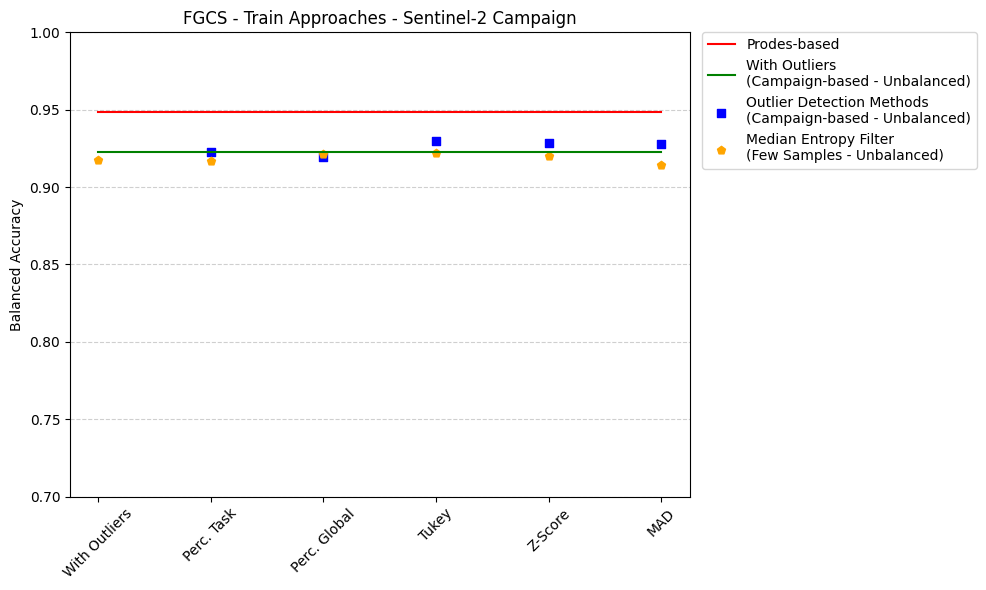

In [40]:
remove_outliers_approach_names = ['With Outliers', 'Perc. Task', 'Perc. Global', 'Tukey', 'Z-Score', 'MAD']


# Posições no eixo X ----------------------
x = np.arange(len(remove_outliers_approach_names))

# Plot ------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(x, scores_test_prodes_based_list_for_plot, label='Prodes-based', color='red') # plota o valor para PRODES-base em uma linha
plt.plot(x, scores_test_campaign_based_with_outliers_list_for_plot, label='With Outliers\n(Campaign-based - Unbalanced)', color='green')
plt.scatter(x, [0] + scores_test_campaign_based[1:], label='Outlier Detection Methods\n(Campaign-based - Unbalanced)', marker='s', color='blue') # plota todas as abordagens, exceto "With Outliers"
plt.scatter(x, scores_test_campaign_based_filtered_by_entropy, label= 'Median Entropy Filter\n(Few Samples - Unbalanced)', marker='p', color='orange')

plt.xticks(x, remove_outliers_approach_names, rotation=45)
plt.ylabel("Balanced Accuracy")
plt.ylim(0.7, 1)
plt.title(f'FGCS - Train Approaches - {CAMPAIGN_NAME}')

plt.legend(
    loc='upper left',          # Posição de referência (canto superior esquerdo da caixa da legenda)
    bbox_to_anchor=(1.02, 1),  # desloca a legenda para fora (x=1.02 move para a direita, y=1 mantém no topo)
    borderaxespad=0,           # distância entre gráfico e legenda
    frameon=True  )

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [41]:
scores_test_campaign_based[1:]

[0.9224566880996401,
 0.9191182304773535,
 0.929681972236439,
 0.9283547691187195,
 0.9276208626393737]

#### Checagem de balanceamento e desbalanceamento de amostras

In [42]:
def print_samples_per_class(y_train, approach):

    print(f' == Approach: {approach} == \n\n')

    remove_outliers_approach_names = ['Perc. Task', 'Perc. Global', 'Tukey', 'Z-Score', 'MAD']

    for idx, outlier_remove_approach_train in enumerate(train_file_path):

        if isinstance(y_train[idx], np.ndarray):
            y_train[idx] = y_train[idx].tolist()

        forest_samples_num = y_train[idx].count('Forest')
        non_forest_samples_num = y_train[idx].count('Non-forest')

        if idx == 0:
            print(f'With Outliers\nForest samples: {forest_samples_num} - Non-Forest samples: {non_forest_samples_num}\n\n')
        else:
            print(f'{remove_outliers_approach_names[idx - 1]}\nForest samples: {forest_samples_num} - Non-Forest samples: {non_forest_samples_num}\n\n')

In [43]:
print_samples_per_class(y_train_filtered_by_entropy, approach='Campaign-based - Filtered by Median Entropy')

 == Approach: Campaign-based - Filtered by Median Entropy == 


With Outliers
Forest samples: 691 - Non-Forest samples: 267


Perc. Task
Forest samples: 657 - Non-Forest samples: 260


Perc. Global
Forest samples: 653 - Non-Forest samples: 254


Tukey
Forest samples: 651 - Non-Forest samples: 260


Z-Score
Forest samples: 671 - Non-Forest samples: 255


MAD
Forest samples: 677 - Non-Forest samples: 278




#### Oversampling e Undersampling

In [44]:
def random_undersampling(X, y, random_state=RANDOM_SEED):

    # Garante que X e y sejam arrays NumPy
    X = np.array(X)
    y = np.array(y)

    # Define semente para reprodutibilidade
    np.random.seed(random_state)

    # Conta quantas amostras há de cada classe
    n_forest = np.sum(y == "Forest")
    n_nonforest = np.sum(y == "Non-forest")

    # Identifica classe majoritária e minoritária
    if n_forest > n_nonforest:
        maj_class, min_class = "Forest", "Non-forest"
    else:
        maj_class, min_class = "Non-forest", "Forest"

    # Número de amostras que a majoritária deve manter (igual à minoritária)
    n_to_keep = np.sum(y == min_class)

    # Obtém os índices da classe majoritária e minoritária
    idx_majority = np.where(y == maj_class)[0]
    idx_minority = np.where(y == min_class)[0]

    # Sorteia aleatoriamente quais índices da majoritária serão mantidos
    idx_majority_selected = np.random.choice(idx_majority, n_to_keep, replace=False)

    # Combina majoritária reduzida + minoritária completa
    idx_final = np.concatenate([idx_majority_selected, idx_minority])

    # Embaralha os índices finais (para evitar ordenação por classe)
    np.random.shuffle(idx_final)

    # Retorna os arrays balanceados
    X_bal = X[idx_final]
    y_bal = y[idx_final]

    return X_bal, y_bal

In [45]:
def ascending_entropy_undersampling(forest_features, non_forest_features, y_forest, y_non_forest):
    
    # verifica a classe minoritária
    if len(forest_features) < len(non_forest_features):
        min_len = len(forest_features)
    else:
        min_len = len(non_forest_features)

    X_bal = []
    y_bal = []

    # iterage conforme a quantidade de amostras minoritárias, por classe, em ordem crescente de entropia
    for idx in range(min_len):
        X_bal.append(forest_features[idx])
        X_bal.append(non_forest_features[idx])

        y_bal.append(y_forest[idx])
        y_bal.append(y_non_forest[idx])

    return np.float64(X_bal), y_bal

In [46]:
def descending_entropy_undersampling(forest_features, non_forest_features, y_forest, y_non_forest):
    
    # verifica a classe minoritária
    if len(forest_features) < len(non_forest_features):
        min_len = len(forest_features)
    else:
        min_len = len(non_forest_features)

    X_bal = []
    y_bal = []

    # iterage conforme a quantidade de amostras minoritárias, por classe, em ordem decrescente de entropia
    # sintaxe decrescente: range(tam - 1, onde parar +1, passo)
    for idx in range(min_len - 1, -1, -1):
        X_bal.append(forest_features[idx])
        X_bal.append(non_forest_features[idx])

        y_bal.append(y_forest[idx])
        y_bal.append(y_non_forest[idx])

    return np.float64(X_bal), y_bal

In [47]:
def gaussian_noise_injection_DA(X, y, noise_std=0.2, random_state=RANDOM_SEED):
    np.random.seed(random_state)
    random.seed(random_state)

    # Garantir que seja ndarray
    X = np.array(X)
    y = np.array(y)

    # Contagem de classes
    n_forest = np.sum(y == "Forest")
    n_nonforest = np.sum(y == "Non-forest")

    if n_forest >= n_nonforest:
        maj_class, min_class = "Forest", "Non-forest"
        diff = n_forest - n_nonforest
    else:
        maj_class, min_class = "Non-forest", "Forest"
        diff = n_nonforest - n_forest

    # Filtra minoritária
    X_min = X[y == min_class]

    # Sorteia índices
    idx_selected = np.random.choice(len(X_min), diff, replace=True)
    X_selected = X_min[idx_selected]

    # Adiciona ruído
    noise = np.random.normal(0, noise_std, X_selected.shape)
    X_synth = X_selected + noise

    # Concatena
    X_bal = np.vstack([X, X_synth])
    y_bal = np.concatenate([y, np.array([min_class]*diff)])

    return X_bal, y_bal

In [48]:
def smote(X, y, random_state=RANDOM_SEED):

    # instancia o objeto SMOTE com uma semente para reprodutibilidade
    smote = SMOTE(random_state=random_state)
    
    # fit_resample: ajusta internamente e retorna (X_resampled, y_resampled)
    X_bal, y_bal = smote.fit_resample(X, y)
    
    # retorna os dados balanceados
    return X_bal, y_bal

In [49]:
def adasyn(X, y, random_state=RANDOM_SEED):
    
    # instancia Adaptive Synthetic Sampling (ADASYN)
    adasyn = ADASYN(random_state=random_state)

    # ajusta e gera os exemplos sintéticos
    X_bal, y_bal = adasyn.fit_resample(X, y)
    
    return X_bal, y_bal

In [50]:
def gaussian_noise_injection_expand(X, y, noise_std=0.01, factor=10, random_state=RANDOM_SEED):
  
    np.random.seed(random_state)

    X = np.array(X)
    y = np.array(y)

    X_aug = [X]
    y_aug = [y]

    # Para cada classe, gerar (factor-1) vezes mais dados
    classes = np.unique(y)
    for cls in classes:
        X_cls = X[y == cls]
        n_samples = len(X_cls)
        n_to_generate = (factor - 1) * n_samples

        # Sorteia amostras da classe
        idx_selected = np.random.choice(n_samples, n_to_generate, replace=True)
        X_selected = X_cls[idx_selected]

        # Adiciona ruído
        noise = np.random.normal(0, noise_std, X_selected.shape)
        X_synth = X_selected + noise

        X_aug.append(X_synth)
        y_aug.append(np.array([cls] * n_to_generate))

    # Concatena tudo
    X_final = np.vstack(X_aug)
    y_final = np.concatenate(y_aug)

    return X_final, y_final

In [51]:
len(X_train_campaign_scaled[0])

1777

In [52]:
print_samples_per_class(y_train_Majority_response_without_draws_and_undefined_sorted, approach=f'No Draws/Undef. Original Campaign Data')

 == Approach: No Draws/Undef. Original Campaign Data == 


With Outliers
Forest samples: 1068 - Non-Forest samples: 709


Perc. Task
Forest samples: 1047 - Non-Forest samples: 725


Perc. Global
Forest samples: 1050 - Non-Forest samples: 711


Tukey
Forest samples: 1053 - Non-Forest samples: 706


Z-Score
Forest samples: 1065 - Non-Forest samples: 718


MAD
Forest samples: 1057 - Non-Forest samples: 710




In [53]:
X_train_random_undersampling = []
y_train_random_undersampling = []

X_train_ascending_entropy_undersampling = []
y_train_ascending_entropy_undersampling = []

X_train_descending_entropy_undersampling = []
y_train_descending_entropy_undersampling = []

X_train_gni = []
y_train_gni = []

X_train_smote = []
y_train_smote = []

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    X_train_adasyn = []
    y_train_adasyn = []


for idx, remove_outliers_approach_names in enumerate (train_file_path):

    if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_ORIGINAL_CAMPAIGN_DATA': # para o caso dos dados originais da campanha (maior entropia -> maior diversidade para geração de dados sintéticos)

        # random undersampling
        X_train_random_undersampling_temp, y_train_random_undersampling_temp = random_undersampling(X_train_campaign_scaled[idx], 
                                                                                                    y_train_Majority_response_without_draws_and_undefined_sorted[idx])
        X_train_random_undersampling.append(X_train_random_undersampling_temp)
        y_train_random_undersampling.append(y_train_random_undersampling_temp)

        # entropy undersampling - crescente
        X_train_entropy_undersampling_temp, y_train_entropy_undersampling_temp = ascending_entropy_undersampling(X_train_forest_class_campaign_scaled[idx], 
                                                                                                                 X_train_non_forest_class_campaign_scaled[idx], 
                                                                                                                 y_train_forest_sorted[idx], 
                                                                                                                 y_train_non_forest_sorted[idx])
        
        X_train_ascending_entropy_undersampling.append(X_train_entropy_undersampling_temp)
        y_train_ascending_entropy_undersampling.append(y_train_entropy_undersampling_temp)

        # entropy undersampling - decrescente
        X_train_entropy_undersampling_temp, y_train_entropy_undersampling_temp = descending_entropy_undersampling(X_train_forest_class_campaign_scaled[idx], 
                                                                                                                  X_train_non_forest_class_campaign_scaled[idx], 
                                                                                                                  y_train_forest_sorted[idx], 
                                                                                                                  y_train_non_forest_sorted[idx])
        
        X_train_descending_entropy_undersampling.append(X_train_entropy_undersampling_temp)
        y_train_descending_entropy_undersampling.append(y_train_entropy_undersampling_temp)

        # gni
        X_train_gni_temp, y_train_gni_temp = gaussian_noise_injection_DA(X_train_campaign_scaled[idx], y_train_Majority_response_without_draws_and_undefined_sorted[idx])
        X_train_gni.append(X_train_gni_temp)
        y_train_gni.append(y_train_gni_temp)

        # smote
        X_train_smote_temp, y_train_smote_temp = smote(X_train_campaign_scaled[idx], y_train_Majority_response_without_draws_and_undefined_sorted[idx])
        X_train_smote.append(X_train_smote_temp)
        y_train_smote.append(y_train_smote_temp)

        # adasyn
        # X_train_adasyn_temp, y_train_adasyn_temp = adasyn(X_train_campaign_scaled[idx], y_train_Majority_response_without_draws_and_undefined_sorted[idx])
        # X_train_adasyn.append(X_train_adasyn_temp)
        # y_train_adasyn.append(y_train_adasyn_temp)
    
    
    else: # OVER_FILTERED_BY_MEDIAN_ENTROPY

        # random undersampling
        X_train_random_undersampling_temp, y_train_random_undersampling_temp = random_undersampling(X_train_filtered_by_entropy_scaled[idx], y_train_filtered_by_entropy_sorted[idx])
        X_train_random_undersampling.append(X_train_random_undersampling_temp)
        y_train_random_undersampling.append(y_train_random_undersampling_temp)

        # entropy undersampling - crescente
        X_train_entropy_undersampling_temp, y_train_entropy_undersampling_temp = ascending_entropy_undersampling(X_train_forest_class_filtered_entropy_campaign_scaled[idx], 
                                                                                                                 X_train_non_forest_class_filtered_entropy_campaign_scaled[idx], 
                                                                                                                 y_train_filtered_median_entropy_forest_sorted[idx], 
                                                                                                                 y_train_filtered_median_entropy_non_forest_sorted[idx])
        
        X_train_ascending_entropy_undersampling.append(X_train_entropy_undersampling_temp)
        y_train_ascending_entropy_undersampling.append(y_train_entropy_undersampling_temp)

        # entropy undersampling - decrescente
        X_train_entropy_undersampling_temp, y_train_entropy_undersampling_temp = descending_entropy_undersampling(X_train_forest_class_filtered_entropy_campaign_scaled[idx], 
                                                                                                                 X_train_non_forest_class_filtered_entropy_campaign_scaled[idx], 
                                                                                                                 y_train_filtered_median_entropy_forest_sorted[idx], 
                                                                                                                 y_train_filtered_median_entropy_non_forest_sorted[idx])
        
        X_train_descending_entropy_undersampling.append(X_train_entropy_undersampling_temp)
        y_train_descending_entropy_undersampling.append(y_train_entropy_undersampling_temp)

        # gni
        X_train_gni_temp, y_train_gni_temp = gaussian_noise_injection_DA(X_train_filtered_by_entropy_scaled[idx], y_train_filtered_by_entropy_sorted[idx])
        X_train_gni.append(X_train_gni_temp)
        y_train_gni.append(y_train_gni_temp)

        # smote
        X_train_smote_temp, y_train_smote_temp = smote(X_train_filtered_by_entropy_scaled[idx], y_train_filtered_by_entropy_sorted[idx])
        X_train_smote.append(X_train_smote_temp)
        y_train_smote.append(y_train_smote_temp)

        # adasyn
        X_train_adasyn_temp, y_train_adasyn_temp = adasyn(X_train_filtered_by_entropy_scaled[idx], y_train_filtered_by_entropy_sorted[idx])
        X_train_adasyn.append(X_train_adasyn_temp)
        y_train_adasyn.append(y_train_adasyn_temp)


In [54]:
print_samples_per_class(y_train_random_undersampling, approach=f'Random Undersampling - {OVERSAMP_UNDERSAMP_DA_FLOW}')

 == Approach: Random Undersampling - OVER_FILTERED_BY_MEDIAN_ENTROPY == 


With Outliers
Forest samples: 267 - Non-Forest samples: 267


Perc. Task
Forest samples: 260 - Non-Forest samples: 260


Perc. Global
Forest samples: 254 - Non-Forest samples: 254


Tukey
Forest samples: 260 - Non-Forest samples: 260


Z-Score
Forest samples: 255 - Non-Forest samples: 255


MAD
Forest samples: 278 - Non-Forest samples: 278




In [55]:
print_samples_per_class(y_train_ascending_entropy_undersampling, approach=f'Ascending Entropy-based Undersampling - {OVERSAMP_UNDERSAMP_DA_FLOW}')

 == Approach: Ascending Entropy-based Undersampling - OVER_FILTERED_BY_MEDIAN_ENTROPY == 


With Outliers
Forest samples: 267 - Non-Forest samples: 267


Perc. Task
Forest samples: 260 - Non-Forest samples: 260


Perc. Global
Forest samples: 254 - Non-Forest samples: 254


Tukey
Forest samples: 260 - Non-Forest samples: 260


Z-Score
Forest samples: 255 - Non-Forest samples: 255


MAD
Forest samples: 278 - Non-Forest samples: 278




In [56]:
print_samples_per_class(y_train_descending_entropy_undersampling, approach=f'Descending Entropy-based Undersampling - {OVERSAMP_UNDERSAMP_DA_FLOW}')

 == Approach: Descending Entropy-based Undersampling - OVER_FILTERED_BY_MEDIAN_ENTROPY == 


With Outliers
Forest samples: 267 - Non-Forest samples: 267


Perc. Task
Forest samples: 260 - Non-Forest samples: 260


Perc. Global
Forest samples: 254 - Non-Forest samples: 254


Tukey
Forest samples: 260 - Non-Forest samples: 260


Z-Score
Forest samples: 255 - Non-Forest samples: 255


MAD
Forest samples: 278 - Non-Forest samples: 278




In [57]:
print_samples_per_class(y_train_gni, approach=f'GNIs {OVERSAMP_UNDERSAMP_DA_FLOW}')

 == Approach: GNIs OVER_FILTERED_BY_MEDIAN_ENTROPY == 


With Outliers
Forest samples: 691 - Non-Forest samples: 691


Perc. Task
Forest samples: 657 - Non-Forest samples: 657


Perc. Global
Forest samples: 653 - Non-Forest samples: 653


Tukey
Forest samples: 651 - Non-Forest samples: 651


Z-Score
Forest samples: 671 - Non-Forest samples: 671


MAD
Forest samples: 677 - Non-Forest samples: 677




In [58]:
print_samples_per_class(y_train_smote, approach=f'SMOTE {OVERSAMP_UNDERSAMP_DA_FLOW}')

 == Approach: SMOTE OVER_FILTERED_BY_MEDIAN_ENTROPY == 


With Outliers
Forest samples: 691 - Non-Forest samples: 691


Perc. Task
Forest samples: 657 - Non-Forest samples: 657


Perc. Global
Forest samples: 653 - Non-Forest samples: 653


Tukey
Forest samples: 651 - Non-Forest samples: 651


Z-Score
Forest samples: 671 - Non-Forest samples: 671


MAD
Forest samples: 677 - Non-Forest samples: 677




In [59]:
if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    print_samples_per_class(y_train_adasyn, approach='Adasyn')

 == Approach: Adasyn == 


With Outliers
Forest samples: 691 - Non-Forest samples: 680


Perc. Task
Forest samples: 657 - Non-Forest samples: 637


Perc. Global
Forest samples: 653 - Non-Forest samples: 661


Tukey
Forest samples: 651 - Non-Forest samples: 645


Z-Score
Forest samples: 671 - Non-Forest samples: 678


MAD
Forest samples: 677 - Non-Forest samples: 686




In [60]:
for idx, remove_outliers_approach_names in enumerate (train_file_path):

    # random undersampling
    svm_campaign_based_filtered_by_entropy_random_undersample[idx] = train_5_fold_cross_validation(svm_campaign_based_filtered_by_entropy_random_undersample[idx], cv_campaign_based_filtered_by_entropy_random_undersample[idx], X_train_random_undersampling[idx], y_train_random_undersampling[idx])

    # entropy undersampling - ascending
    svm_campaign_based_ascending_entropy_undersample[idx] = train_5_fold_cross_validation(svm_campaign_based_ascending_entropy_undersample[idx], cv_campaign_based_ascending_entropy_undersample[idx], X_train_ascending_entropy_undersampling[idx], y_train_ascending_entropy_undersampling[idx])

    # entropy undersampling - descending
    svm_campaign_based_descending_entropy_undersample[idx] = train_5_fold_cross_validation(svm_campaign_based_descending_entropy_undersample[idx], cv_campaign_based_descending_entropy_undersample[idx], X_train_descending_entropy_undersampling[idx], y_train_descending_entropy_undersampling[idx])

    # gni
    svm_campaign_based_filtered_by_entropy_gni[idx] = train_5_fold_cross_validation(svm_campaign_based_filtered_by_entropy_gni[idx], cv_campaign_based_filtered_by_entropy_gni[idx], X_train_gni[idx], y_train_gni[idx])

    # smote
    svm_campaign_based_filtered_by_entropy_smote[idx] = train_5_fold_cross_validation(svm_campaign_based_filtered_by_entropy_smote[idx], cv_campaign_based_filtered_by_entropy_smote[idx], X_train_smote[idx], y_train_smote[idx])

    if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
        # adasyn
        svm_campaign_based_filtered_by_entropy_adasyn[idx] = train_5_fold_cross_validation(svm_campaign_based_filtered_by_entropy_adasyn[idx], cv_campaign_based_filtered_by_entropy_adasyn[idx], X_train_adasyn[idx], y_train_adasyn[idx])

Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold 4/5...
Fold 5/5...
Fold 1/5...
Fold 2/5...
Fold 3/5...
Fold

#### Teste com Undersampling e Oversampling

In [61]:
scores_test_random_undersample = []
scores_test_ascending_entropy_undersample = []
scores_test_descending_entropy_undersample = []
scores_test_gni = []
scores_test_smote = []
scores_test_adasyn = []


for idx, outlier_remove_approach_train in enumerate(train_file_path):

    if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":

        y_test_pred_random_undersample = svm_campaign_based_filtered_by_entropy_random_undersample[idx].predict(X_test_campaign_scaled[idx])
        y_test_pred_ascending_entropy_undersample = svm_campaign_based_ascending_entropy_undersample[idx].predict(X_test_campaign_scaled[idx])
        y_test_pred_descending_entropy_undersample = svm_campaign_based_descending_entropy_undersample[idx].predict(X_test_campaign_scaled[idx])
        y_test_pred_gni = svm_campaign_based_filtered_by_entropy_gni[idx].predict(X_test_campaign_scaled[idx])
        y_test_pred_smote = svm_campaign_based_filtered_by_entropy_smote[idx].predict(X_test_campaign_scaled[idx])
        
        # y_test_pred_adasyn = svm_campaign_based_filtered_by_entropy_adasyn[idx].predict(X_test_scaled)

        scores_test_random_undersample.append(balanced_accuracy_score(y_test, y_test_pred_random_undersample))
        scores_test_ascending_entropy_undersample.append(balanced_accuracy_score(y_test, y_test_pred_ascending_entropy_undersample))
        scores_test_descending_entropy_undersample.append(balanced_accuracy_score(y_test, y_test_pred_descending_entropy_undersample))
        scores_test_gni.append(balanced_accuracy_score(y_test, y_test_pred_gni))
        scores_test_smote.append(balanced_accuracy_score(y_test, y_test_pred_smote))

        # scores_test_adasyn.append(balanced_accuracy_score(y_test, y_test_pred_adasyn))

    else: # OVER_FILTERED_BY_MEDIAN_ENTROPY

        y_test_pred_random_undersample = svm_campaign_based_filtered_by_entropy_random_undersample[idx].predict(X_test_filtered_by_entropy_scaled[idx])
        y_test_pred_ascending_entropy_undersample = svm_campaign_based_ascending_entropy_undersample[idx].predict(X_test_filtered_by_entropy_scaled[idx])
        y_test_pred_descending_entropy_undersample = svm_campaign_based_descending_entropy_undersample[idx].predict(X_test_filtered_by_entropy_scaled[idx])
        y_test_pred_gni = svm_campaign_based_filtered_by_entropy_gni[idx].predict(X_test_filtered_by_entropy_scaled[idx])
        y_test_pred_smote = svm_campaign_based_filtered_by_entropy_smote[idx].predict(X_test_filtered_by_entropy_scaled[idx])        
        y_test_pred_adasyn = svm_campaign_based_filtered_by_entropy_adasyn[idx].predict(X_test_filtered_by_entropy_scaled[idx])

        scores_test_random_undersample.append(balanced_accuracy_score(y_test, y_test_pred_random_undersample))
        scores_test_ascending_entropy_undersample.append(balanced_accuracy_score(y_test, y_test_pred_ascending_entropy_undersample))
        scores_test_descending_entropy_undersample.append(balanced_accuracy_score(y_test, y_test_pred_descending_entropy_undersample))
        scores_test_gni.append(balanced_accuracy_score(y_test, y_test_pred_gni))
        scores_test_smote.append(balanced_accuracy_score(y_test, y_test_pred_smote))
        scores_test_adasyn.append(balanced_accuracy_score(y_test, y_test_pred_adasyn))

    

print(f'Bal. Acc. SVM Random Undersample: {scores_test_random_undersample}\n')
print(f'Bal. Acc. SVM Ascending Entropy Undersample: {scores_test_ascending_entropy_undersample}\n')
print(f'Bal. Acc. SVM Descending Entropy Undersample: {scores_test_descending_entropy_undersample}\n')
print(f'Bal. Acc. SVM GNI: {scores_test_gni}\n')
print(f'Bal. Acc. SVM SMOTE: {scores_test_smote}\n')

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    print(f'Bal. Acc. SVM Adasyn: {scores_test_adasyn}\n')

Bal. Acc. SVM Random Undersample: [0.9261861365329846, 0.9421150097748527, 0.9434777541367362, 0.9325375602289716, 0.9354539635142975, 0.923123971246292]

Bal. Acc. SVM Ascending Entropy Undersample: [0.9405032147645225, 0.9395547119359267, 0.9444931051120704, 0.9360543985142109, 0.93019410687974, 0.9369633505710979]

Bal. Acc. SVM Descending Entropy Undersample: [0.9403639538078172, 0.9457992870853773, 0.9381152832972318, 0.9367451571971368, 0.9375494902853045, 0.9363606674307401]

Bal. Acc. SVM GNI: [0.9252315822878163, 0.9240139254851663, 0.9270179546849715, 0.9198177012201302, 0.9250247987422393, 0.9211972138222093]

Bal. Acc. SVM SMOTE: [0.9222452205843847, 0.9153747115723467, 0.915371582738352, 0.9192145684516835, 0.9225295691003235, 0.9249143717336195]

Bal. Acc. SVM Adasyn: [0.9292044795811242, 0.9216452166499327, 0.926818552877606, 0.9159255162938063, 0.9250527519967746, 0.9229513986232396]



### Comprehensive Metrics Table (Train & Test)

In [62]:
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from collections import Counter
import pandas as pd
import numpy as np

def compute_label_agreement(prodes_labels, campaign_labels):
    """
    Compute label agreement metrics between PRODES and Campaign labels.
    Returns: global_mismatch_pct, prodes_forest_mismatch_pct, prodes_nonforest_mismatch_pct
    
    - global_mismatch_pct: % of valid samples (Forest/Non-forest only) where PRODES != Campaign
    - prodes_forest_mismatch_pct: % of PRODES=Forest samples where Campaign=Non-forest
    - prodes_nonforest_mismatch_pct: % of PRODES=Non-forest samples where Campaign=Forest
    """
    prodes_list = list(prodes_labels) if hasattr(prodes_labels, 'tolist') else list(prodes_labels)
    campaign_list = list(campaign_labels)
    
    # Filter to only include samples where campaign label is Forest or Non-forest
    valid_indices = [i for i, label in enumerate(campaign_list) if label in ['Forest', 'Non-forest']]
    
    if len(valid_indices) == 0:
        return 0.0, 0.0, 0.0
    
    prodes_valid = [prodes_list[i] for i in valid_indices]
    campaign_valid = [campaign_list[i] for i in valid_indices]
    
    # Global mismatch
    n_samples = len(prodes_valid)
    mismatches = sum(1 for p, c in zip(prodes_valid, campaign_valid) if p != c)
    global_mismatch_pct = 100 * mismatches / n_samples if n_samples > 0 else 0
    
    # PRODES=Forest but Campaign=Non-forest
    prodes_forest_count = sum(1 for p in prodes_valid if p == 'Forest')
    prodes_forest_campaign_nonforest = sum(1 for p, c in zip(prodes_valid, campaign_valid) 
                                            if p == 'Forest' and c == 'Non-forest')
    prodes_forest_mismatch_pct = 100 * prodes_forest_campaign_nonforest / prodes_forest_count if prodes_forest_count > 0 else 0
    
    # PRODES=Non-forest but Campaign=Forest
    prodes_nonforest_count = sum(1 for p in prodes_valid if p == 'Non-forest')
    prodes_nonforest_campaign_forest = sum(1 for p, c in zip(prodes_valid, campaign_valid) 
                                            if p == 'Non-forest' and c == 'Forest')
    prodes_nonforest_mismatch_pct = 100 * prodes_nonforest_campaign_forest / prodes_nonforest_count if prodes_nonforest_count > 0 else 0
    
    return global_mismatch_pct, prodes_forest_mismatch_pct, prodes_nonforest_mismatch_pct

def compute_metrics(y_true, y_pred, pos_label='Non-forest'):
    """Compute balanced accuracy, F1, precision, recall, sensitivity, and specificity."""
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    
    # Compute sensitivity and specificity from confusion matrix
    # For binary classification with pos_label='Non-forest'
    # Sensitivity = Recall (for positive class) = TP / (TP + FN)
    # Specificity = TN / (TN + FP)
    labels = ['Forest', 'Non-forest']  # Negative class first, then positive
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return bal_acc, f1, precision, recall, sensitivity, specificity

def count_samples(y, pos_label='Non-forest', neg_label='Forest'):
    """Count positive and negative samples in a label array."""
    y_arr = np.array(y)
    n_pos = np.sum(y_arr == pos_label)
    n_neg = np.sum(y_arr == neg_label)
    return n_pos, n_neg

def compute_5fold_metrics(model, cv, X_train, y_train, X_test, y_test):
    """
    Perform 5-fold CV and compute metrics for each fold.
    Uses the same protocol as train_5_fold_cross_validation.
    Returns mean ± std for train (validation fold) and test metrics.
    """
    # Storage for each fold's metrics
    train_metrics = {'bal_acc': [], 'f1': [], 'precision': [], 'recall': [], 'sensitivity': [], 'specificity': []}
    test_metrics = {'bal_acc': [], 'f1': [], 'precision': [], 'recall': [], 'sensitivity': [], 'specificity': []}
    
    # Loop pelos folds (same as train_5_fold_cross_validation)
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = np.array(y_train)[train_idx], np.array(y_train)[val_idx]
        
        # Treina no fold (same as train_5_fold_cross_validation)
        model.fit(X_tr, y_tr)
        
        # Validation (train) metrics
        y_val_pred = model.predict(X_val)
        bal_acc, f1, prec, rec, sens, spec = compute_metrics(y_val, y_val_pred)
        train_metrics['bal_acc'].append(bal_acc)
        train_metrics['f1'].append(f1)
        train_metrics['precision'].append(prec)
        train_metrics['recall'].append(rec)
        train_metrics['sensitivity'].append(sens)
        train_metrics['specificity'].append(spec)
        
        # Test metrics
        y_test_pred = model.predict(X_test)
        bal_acc, f1, prec, rec, sens, spec = compute_metrics(y_test, y_test_pred)
        test_metrics['bal_acc'].append(bal_acc)
        test_metrics['f1'].append(f1)
        test_metrics['precision'].append(prec)
        test_metrics['recall'].append(rec)
        test_metrics['sensitivity'].append(sens)
        test_metrics['specificity'].append(spec)
    
    return train_metrics, test_metrics

def format_mean_std(values):
    """Format as mean ± std with 4 decimal places."""
    mean = np.mean(values)
    std = np.std(values)
    return f"{mean:.4f} ± {std:.4f}"

# Outlier approach names
outlier_names = ['With Outliers', 'Perc. Task', 'Perc. Global', 'Tukey', 'Z-Score', 'MAD']

# Results storage
results = []

# Count test samples (same for all methods)
test_pos, test_neg = count_samples(y_test)

print("Computing 5-fold CV metrics for all methods...")
print("=" * 60)

# =====================================================================
# 1. PRODES-based (single model, no outlier approaches)
# =====================================================================
print("Processing: PRODES-based...")
train_m, test_m = compute_5fold_metrics(svm_prodes_based, cv_prodes_based,
                                         X_train_PRODES_scaled, y_train_PRODES_class, 
                                         X_test_PRODES_scaled, y_test)
train_pos, train_neg = count_samples(y_train_PRODES_class)
# For PRODES-based, label agreement is 100% (no mismatch since we use PRODES labels)
results.append({
    'Method': 'PRODES-based',
    'Outlier Approach': 'N/A',
    'Train Pos': train_pos,
    'Train Neg': train_neg,
    'Test Pos': test_pos,
    'Test Neg': test_neg,
    'Label Mismatch (%)': 'N/A',
    'PRODES-F Mismatch (%)': 'N/A',
    'PRODES-NF Mismatch (%)': 'N/A',
    'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
    'Train F1': format_mean_std(train_m['f1']),
    'Train Precision': format_mean_std(train_m['precision']),
    'Train Recall': format_mean_std(train_m['recall']),
    'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
    'Test F1': format_mean_std(test_m['f1']),
    'Test Precision': format_mean_std(test_m['precision']),
    'Test Recall': format_mean_std(test_m['recall']),
    'Test Sensitivity': format_mean_std(test_m['sensitivity']),
    'Test Specificity': format_mean_std(test_m['specificity'])
})

# =====================================================================
# 2. Campaign-based (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: Campaign-based - {outlier_name}...")
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based[idx], cv_campaign_based[idx],
        X_train_campaign_scaled[idx], 
        y_train_Majority_response_without_draws_and_undefined_sorted[idx],
        X_test_campaign_scaled[idx], y_test)
    
    train_pos, train_neg = count_samples(y_train_Majority_response_without_draws_and_undefined_sorted[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign)
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'Campaign-based',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity'])
    })

# =====================================================================
# 3. Campaign-based + Median Entropy Filter (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: Campaign + Median Entropy - {outlier_name}...")
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based_filtered_by_entropy[idx], cv_campaign_based_filtered_by_entropy[idx],
        X_train_filtered_by_entropy_scaled[idx], 
        y_train_filtered_by_entropy_sorted[idx],
        X_test_filtered_by_entropy_scaled[idx], y_test)
    
    train_pos, train_neg = count_samples(y_train_filtered_by_entropy_sorted[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign) - same as Campaign-based
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'Campaign + Median Entropy',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity'])
    })

# =====================================================================
# 4. Random Undersampling (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: Random Undersample - {outlier_name}...")
    if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
        X_test_for_pred = X_test_campaign_scaled[idx]
    else:
        X_test_for_pred = X_test_filtered_by_entropy_scaled[idx]
    
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based_filtered_by_entropy_random_undersample[idx], cv_campaign_based_filtered_by_entropy_random_undersample[idx],
        X_train_random_undersampling[idx], 
        y_train_random_undersampling[idx],
        X_test_for_pred, y_test)
    
    train_pos, train_neg = count_samples(y_train_random_undersampling[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign)
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'Random Undersample',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity'])
    })

# =====================================================================
# 5. Ascending Entropy Undersampling (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: Ascending Entropy Undersample - {outlier_name}...")
    if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
        X_test_for_pred = X_test_campaign_scaled[idx]
    else:
        X_test_for_pred = X_test_filtered_by_entropy_scaled[idx]
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based_ascending_entropy_undersample[idx], cv_campaign_based_ascending_entropy_undersample[idx],
        X_train_ascending_entropy_undersampling[idx], 
        y_train_ascending_entropy_undersampling[idx],
        X_test_for_pred, y_test)
    
    train_pos, train_neg = count_samples(y_train_ascending_entropy_undersampling[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign)
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'Ascending Entropy Undersample',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity']),
    })

# =====================================================================
# 6. Descending Entropy Undersampling (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: Descending Entropy Undersample - {outlier_name}...")
    if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
        X_test_for_pred = X_test_campaign_scaled[idx]
    else:
        X_test_for_pred = X_test_filtered_by_entropy_scaled[idx]
    
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based_descending_entropy_undersample[idx], cv_campaign_based_descending_entropy_undersample[idx],
        X_train_descending_entropy_undersampling[idx], 
        y_train_descending_entropy_undersampling[idx],
        X_test_for_pred, y_test)
    
    train_pos, train_neg = count_samples(y_train_descending_entropy_undersampling[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign)
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'Descending Entropy Undersample',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity'])
    })

# =====================================================================
# 7. GNI - Gaussian Noise Injection (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: GNI - {outlier_name}...")
    if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
        X_test_for_pred = X_test_campaign_scaled[idx]
    else:
        X_test_for_pred = X_test_filtered_by_entropy_scaled[idx]
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based_filtered_by_entropy_gni[idx], cv_campaign_based_filtered_by_entropy_gni[idx],
        X_train_gni[idx], 
        y_train_gni[idx],
        X_test_for_pred, y_test)
    
    train_pos, train_neg = count_samples(y_train_gni[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign)
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'GNI',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity'])
    })

# =====================================================================
# 8. SMOTE (per outlier approach)
# =====================================================================
for idx, outlier_name in enumerate(outlier_names):
    print(f"Processing: SMOTE - {outlier_name}...")
    if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
        X_test_for_pred = X_test_campaign_scaled[idx]
    else:
        X_test_for_pred = X_test_filtered_by_entropy_scaled[idx]
    train_m, test_m = compute_5fold_metrics(
        svm_campaign_based_filtered_by_entropy_smote[idx], cv_campaign_based_filtered_by_entropy_smote[idx],
        X_train_smote[idx], 
        y_train_smote[idx],
        X_test_for_pred, y_test)
    
    train_pos, train_neg = count_samples(y_train_smote[idx])
    
    # Compute label agreement metrics (PRODES vs Campaign)
    global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
        y_train_PRODES_class, y_train_majority_reponse[idx])
    
    results.append({
        'Method': 'SMOTE',
        'Outlier Approach': outlier_name,
        'Train Pos': train_pos,
        'Train Neg': train_neg,
        'Test Pos': test_pos,
        'Test Neg': test_neg,
        'Label Mismatch (%)': f"{global_mismatch:.1f}",
        'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
        'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
        'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
        'Train F1': format_mean_std(train_m['f1']),
        'Train Precision': format_mean_std(train_m['precision']),
        'Train Recall': format_mean_std(train_m['recall']),
        'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
        'Test F1': format_mean_std(test_m['f1']),
        'Test Precision': format_mean_std(test_m['precision']),
        'Test Recall': format_mean_std(test_m['recall']),
        'Test Sensitivity': format_mean_std(test_m['sensitivity']),
        'Test Specificity': format_mean_std(test_m['specificity'])
    })

# =====================================================================
# 9. ADASYN (per outlier approach) - only if available
# =====================================================================
if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    for idx, outlier_name in enumerate(outlier_names):
        print(f"Processing: ADASYN - {outlier_name}...")
        X_test_for_pred = X_test_filtered_by_entropy_scaled[idx]
        
        train_m, test_m = compute_5fold_metrics(
            svm_campaign_based_filtered_by_entropy_adasyn[idx], cv_campaign_based_filtered_by_entropy_adasyn[idx],
            X_train_adasyn[idx], 
            y_train_adasyn[idx],
            X_test_for_pred, y_test)
        
        train_pos, train_neg = count_samples(y_train_adasyn[idx])
        
        # Compute label agreement metrics (PRODES vs Campaign)
        global_mismatch, prodes_f_mismatch, prodes_nf_mismatch = compute_label_agreement(
            y_train_PRODES_class, y_train_majority_reponse[idx])
        
        results.append({
            'Method': 'ADASYN',
            'Outlier Approach': outlier_name,
            'Train Pos': train_pos,
            'Train Neg': train_neg,
            'Test Pos': test_pos,
            'Test Neg': test_neg,
            'Label Mismatch (%)': f"{global_mismatch:.1f}",
            'PRODES-F Mismatch (%)': f"{prodes_f_mismatch:.1f}",
            'PRODES-NF Mismatch (%)': f"{prodes_nf_mismatch:.1f}",
            'Train Bal. Acc.': format_mean_std(train_m['bal_acc']),
            'Train F1': format_mean_std(train_m['f1']),
            'Train Precision': format_mean_std(train_m['precision']),
            'Train Recall': format_mean_std(train_m['recall']),
            'Test Bal. Acc.': format_mean_std(test_m['bal_acc']),
            'Test F1': format_mean_std(test_m['f1']),
            'Test Precision': format_mean_std(test_m['precision']),
            'Test Recall': format_mean_std(test_m['recall']),
            'Test Sensitivity': format_mean_std(test_m['sensitivity']),
            'Test Specificity': format_mean_std(test_m['specificity'])
        })

# =====================================================================
# Create DataFrame and display
# =====================================================================
df_metrics = pd.DataFrame(results)

print("\n" + "=" * 60)
print(f"=== Comprehensive Metrics Table (Mean ± Std of 5 Folds) ===")
print(f"=== Campaign: {CAMPAIGN_NAME} ===")
print(f"=== Data Augmentation Flow: {OVERSAMP_UNDERSAMP_DA_FLOW} ===")
print(f"Total method-outlier combinations evaluated: {len(df_metrics)}")
print("=" * 60)
df_metrics

Computing 5-fold CV metrics for all methods...
Processing: PRODES-based...


Processing: Campaign-based - With Outliers...
Processing: Campaign-based - Perc. Task...
Processing: Campaign-based - Perc. Global...
Processing: Campaign-based - Tukey...
Processing: Campaign-based - Z-Score...
Processing: Campaign-based - MAD...
Processing: Campaign + Median Entropy - With Outliers...
Processing: Campaign + Median Entropy - Perc. Task...
Processing: Campaign + Median Entropy - Perc. Global...
Processing: Campaign + Median Entropy - Tukey...
Processing: Campaign + Median Entropy - Z-Score...
Processing: Campaign + Median Entropy - MAD...
Processing: Random Undersample - With Outliers...
Processing: Random Undersample - Perc. Task...
Processing: Random Undersample - Perc. Global...
Processing: Random Undersample - Tukey...
Processing: Random Undersample - Z-Score...
Processing: Random Undersample - MAD...
Processing: Ascending Entropy Undersample - With Outliers...
Processing: Ascending Entropy Undersample - Perc. Task...
Processing: Ascending Entropy Undersample - Per

,Method,Outlier Approach,Train Pos,Train Neg,Test Pos,Test Neg,Label Mismatch (%),PRODES-F Mismatch (%),PRODES-NF Mismatch (%),Train Bal. Acc.,Train F1,Train Precision,Train Recall,Test Bal. Acc.,Test F1,Test Precision,Test Recall,Test Sensitivity,Test Specificity
0,PRODES-based,N/A,900,900,4769,50833,N/A,N/A,N/A,0.9567 ± 0.0153,0.9559 ± 0.0158,0.9725 ± 0.0148,0.9400 ± 0.0221,0.9495 ± 0.0007,0.7881 ± 0.0029,0.6779 ± 0.0042,0.9410 ± 0.0011,0.9410 ± 0.0011,0.9581 ± 0.0008
1,Campaign-based,With Outliers,709,1068,4769,50833,10.1,0.6,19.8,0.9223 ± 0.0145,0.9078 ± 0.0169,0.9194 ± 0.0197,0.8970 ± 0.0262,0.9225 ± 0.0019,0.8287 ± 0.0013,0.7946 ± 0.0048,0.8660 ± 0.0045,0.8660 ± 0.0045,0.9790 ± 0.0007
2,Campaign-based,Perc. Task,725,1047,4769,50833,9.0,0.4,17.7,0.9225 ± 0.0096,0.9096 ± 0.0101,0.9237 ± 0.0112,0.8966 ± 0.0258,0.9207 ± 0.0018,0.8193 ± 0.0038,0.7786 ± 0.0049,0.8644 ± 0.0033,0.8644 ± 0.0033,0.9769 ± 0.0006
3,Campaign-based,Perc. Global,711,1050,4769,50833,9.0,0.4,18.0,0.9253 ± 0.0133,0.9122 ± 0.0152,0.9251 ± 0.0166,0.9002 ± 0.0253,0.9189 ± 0.0045,0.8222 ± 0.0058,0.7881 ± 0.0048,0.8594 ± 0.0089,0.8594 ± 0.0089,0.9783 ± 0.0006
4,Campaign-based,Tukey,706,1053,4769,50833,9.5,0.7,18.7,0.9233 ± 0.0110,0.9096 ± 0.0130,0.9218 ± 0.0165,0.8980 ± 0.0200,0.9288 ± 0.0014,0.8360 ± 0.0024,0.7975 ± 0.0046,0.8785 ± 0.0031,0.8785 ± 0.0031,0.9791 ± 0.0006
5,Campaign-based,Z-Score,718,1065,4769,50833,9.9,0.7,19.4,0.9229 ± 0.0158,0.9091 ± 0.0194,0.9206 ± 0.0263,0.8983 ± 0.0205,0.9263 ± 0.0037,0.8325 ± 0.0048,0.7951 ± 0.0082,0.8736 ± 0.0078,0.8736 ± 0.0078,0.9789 ± 0.0011
6,Campaign-based,MAD,710,1057,4769,50833,9.6,0.7,18.9,0.9256 ± 0.0147,0.9123 ± 0.0174,0.9237 ± 0.0184,0.9014 ± 0.0240,0.9279 ± 0.0008,0.8353 ± 0.0022,0.7976 ± 0.0044,0.8767 ± 0.0019,0.8767 ± 0.0019,0.9791 ± 0.0006
7,Campaign + Median Entropy,With Outliers,267,691,4769,50833,10.1,0.6,19.8,0.9981 ± 0.0037,0.9981 ± 0.0037,1.0000 ± 0.0000,0.9963 ± 0.0074,0.9223 ± 0.0023,0.8355 ± 0.0055,0.8090 ± 0.0080,0.8638 ± 0.0040,0.8638 ± 0.0040,0.9809 ± 0.0009
8,Campaign + Median Entropy,Perc. Task,260,657,4769,50833,9.0,0.4,17.7,0.9962 ± 0.0047,0.9961 ± 0.0048,1.0000 ± 0.0000,0.9923 ± 0.0094,0.9171 ± 0.0047,0.8306 ± 0.0042,0.8093 ± 0.0020,0.8530 ± 0.0098,0.8530 ± 0.0098,0.9811 ± 0.0004
9,Campaign + Median Entropy,Perc. Global,254,653,4769,50833,9.0,0.4,18.0,0.9945 ± 0.0054,0.9922 ± 0.0073,0.9922 ± 0.0095,0.9922 ± 0.0096,0.9218 ± 0.0064,0.8371 ± 0.0061,0.8137 ± 0.0101,0.8621 ± 0.0137,0.8621 ± 0.0137,0.9815 ± 0.0014


In [63]:
# Label Agreement Analysis: PRODES vs Campaign-based with outliers
print("=" * 70)
print("Label Agreement Analysis: PRODES vs Campaign-based (with outliers)")
print("=" * 70)

# Get the labels from both approaches (with outliers is index 0)
prodes_labels = y_train_PRODES_class.tolist() if hasattr(y_train_PRODES_class, 'tolist') else list(y_train_PRODES_class)
campaign_labels = y_train_majority_reponse[0]  # index 0 = with_outliers

# Filter to only include samples where campaign label is Forest or Non-forest
# (excluding Draw and Undefined)
valid_indices = [i for i, label in enumerate(campaign_labels) if label in ['Forest', 'Non-forest']]

# Get the corresponding labels for valid samples
prodes_valid = [prodes_labels[i] for i in valid_indices]
campaign_valid = [campaign_labels[i] for i in valid_indices]

n_samples = len(prodes_valid)
print(f"\nChecking if PRODES and Campaign labels match for the {n_samples} valid samples...")
print(f"(Excluding {len(prodes_labels) - n_samples} samples with Draw/Undefined campaign labels)")

# Count matches and mismatches
matches = sum(1 for p, c in zip(prodes_valid, campaign_valid) if p == c)
mismatches = n_samples - matches

print(f"\n   Matches:     {matches} ({100*matches/n_samples:.1f}%)")
print(f"   Mismatches:  {mismatches} ({100*mismatches/n_samples:.1f}%)")

# Analyze mismatch types
prodes_forest_campaign_nonforest = 0
prodes_nonforest_campaign_forest = 0

for p, c in zip(prodes_valid, campaign_valid):
    if p != c:
        if p == 'Forest' and c == 'Non-forest':
            prodes_forest_campaign_nonforest += 1
        elif p == 'Non-forest' and c == 'Forest':
            prodes_nonforest_campaign_forest += 1

if mismatches > 0:
    print(f"\n   Mismatch breakdown:")
    print(f"     - PRODES=Forest, Campaign=Non-forest:     {prodes_forest_campaign_nonforest:4d} ({100*prodes_forest_campaign_nonforest/mismatches:.1f}% of mismatches)")
    print(f"     - PRODES=Non-forest, Campaign=Forest:     {prodes_nonforest_campaign_forest:4d} ({100*prodes_nonforest_campaign_forest/mismatches:.1f}% of mismatches)")

# Also show the full picture including Draw/Undefined
print("\n" + "-" * 70)
print("Full breakdown of Campaign labels by PRODES class:")
print("-" * 70)

# Create a cross-tabulation
from collections import Counter

# Count campaign labels for each PRODES class
prodes_forest_idx = [i for i, p in enumerate(prodes_labels) if p == 'Forest']
prodes_nonforest_idx = [i for i, p in enumerate(prodes_labels) if p == 'Non-forest']

campaign_for_prodes_forest = [campaign_labels[i] for i in prodes_forest_idx]
campaign_for_prodes_nonforest = [campaign_labels[i] for i in prodes_nonforest_idx]

print(f"\nPRODES=Forest ({len(prodes_forest_idx)} samples):")
for label, count in sorted(Counter(campaign_for_prodes_forest).items()):
    print(f"   Campaign={label}: {count} ({100*count/len(prodes_forest_idx):.1f}%)")

print(f"\nPRODES=Non-forest ({len(prodes_nonforest_idx)} samples):")
for label, count in sorted(Counter(campaign_for_prodes_nonforest).items()):
    print(f"   Campaign={label}: {count} ({100*count/len(prodes_nonforest_idx):.1f}%)")

Label Agreement Analysis: PRODES vs Campaign-based (with outliers)

Checking if PRODES and Campaign labels match for the 1777 valid samples...
(Excluding 23 samples with Draw/Undefined campaign labels)

   Matches:     1598 (89.9%)
   Mismatches:  179 (10.1%)

   Mismatch breakdown:
     - PRODES=Forest, Campaign=Non-forest:        5 (2.8% of mismatches)
     - PRODES=Non-forest, Campaign=Forest:      174 (97.2% of mismatches)

----------------------------------------------------------------------
Full breakdown of Campaign labels by PRODES class:
----------------------------------------------------------------------

PRODES=Forest (900 samples):
   Campaign=Draw: 1 (0.1%)
   Campaign=Forest: 894 (99.3%)
   Campaign=Non-forest: 5 (0.6%)

PRODES=Non-forest (900 samples):
   Campaign=Draw: 22 (2.4%)
   Campaign=Forest: 174 (19.3%)
   Campaign=Non-forest: 704 (78.2%)


In [64]:
# Save the comprehensive metrics table to CSV
import os
metrics_output_dir = f'./metrics_tables/{CAMPAIGN_NAME_PATH}/'
os.makedirs(metrics_output_dir, exist_ok=True)
metrics_filename = f'{metrics_output_dir}/comprehensive_metrics_5fold_{CAMPAIGN_NAME_PATH}_{OVERSAMP_UNDERSAMP_DA_FLOW}.csv'
df_metrics.to_csv(metrics_filename, index=False)
print(f"Metrics table saved to: {metrics_filename}")

# Extract mean values for comparison (parse from "mean ± std" format)
def extract_mean(value_str):
    """Extract mean value from 'mean ± std' string format."""
    return float(value_str.split(' ± ')[0])

# Create a copy with numeric means for finding best performers
df_metrics_numeric = df_metrics.copy()
df_metrics_numeric['Test Bal. Acc. Mean'] = df_metrics['Test Bal. Acc.'].apply(extract_mean)

# Display best test performance per method
print("\n=== Best Test Balanced Accuracy per Method (based on mean) ===")
best_idx = df_metrics_numeric.groupby('Method')['Test Bal. Acc. Mean'].idxmax()
best_per_method = df_metrics.loc[best_idx][['Method', 'Outlier Approach', 'Test Bal. Acc.', 'Test F1']]
print(best_per_method.to_string(index=False))

Metrics table saved to: ./metrics_tables/Sentinel-2_Campaign//comprehensive_metrics_5fold_Sentinel-2_Campaign_OVER_FILTERED_BY_MEDIAN_ENTROPY.csv

=== Best Test Balanced Accuracy per Method (based on mean) ===
                        Method Outlier Approach  Test Bal. Acc.         Test F1
                        ADASYN     Perc. Global 0.9311 ± 0.0051 0.8407 ± 0.0041
 Ascending Entropy Undersample    With Outliers 0.9418 ± 0.0016 0.8282 ± 0.0116
     Campaign + Median Entropy              MAD 0.9227 ± 0.0061 0.8276 ± 0.0063
                Campaign-based            Tukey 0.9288 ± 0.0014 0.8360 ± 0.0024
Descending Entropy Undersample    With Outliers 0.9434 ± 0.0030 0.8261 ± 0.0066
                           GNI     Perc. Global 0.9302 ± 0.0038 0.8309 ± 0.0065
                  PRODES-based              N/A 0.9495 ± 0.0007 0.7881 ± 0.0029
            Random Undersample     Perc. Global 0.9428 ± 0.0019 0.8405 ± 0.0066
                         SMOTE          Z-Score 0.9250 ± 0.0017 0.8370

### Save Classification Reports to CSV

In [65]:
# # =====================================================================
# # SAVE CLASSIFICATION REPORTS TO CSV
# # =====================================================================
# # Each CSV will contain: segment_id, all 52 features, class_prodes, predicted_class

# import os

# # Create output directory for classification reports
# output_dir = f'classification_reports/{CAMPAIGN_NAME_PATH}'
# os.makedirs(output_dir, exist_ok=True)

# # Extract segment_ids from test data (one per segment, not per band)
# test_segment_ids = compact_replicate_values(df_test, 'Segment_id')

# # Get feature column names (52 features)
# num_features = new_X_test.shape[1]
# feature_columns = [f'Feature_{i}' for i in range(1, num_features + 1)]

# def save_classification_report(segment_ids, features, y_true, y_pred, model_name, outlier_approach_name=None):
#     """
#     Save classification report to CSV with segment_id, all features, class_prodes, and predicted_class.
    
#     Parameters:
#     - segment_ids: list of segment identifiers
#     - features: array of features (normalized or raw, depending on model)
#     - y_true: true labels (class_prodes)
#     - y_pred: predicted labels
#     - model_name: name of the SVM model
#     - outlier_approach_name: name of the outlier removal approach (optional)
#     """
#     # Create DataFrame with features
#     df_report = pd.DataFrame(features, columns=feature_columns)
    
#     # Insert segment_id as first column
#     df_report.insert(0, 'segment_id', segment_ids)
    
#     # Add class_prodes and predicted_class
#     df_report['class_prodes'] = y_true
#     df_report['predicted_class'] = y_pred
    
#     # Create filename
#     if outlier_approach_name:
#         filename = f'{output_dir}/svm_{model_name}_{outlier_approach_name}.csv'
#     else:
#         filename = f'{output_dir}/svm_{model_name}.csv'
    
#     # Save to CSV
#     df_report.to_csv(filename, index=False)
#     print(f'Saved: {filename}')

# # Outlier removal approach names for file naming
# outlier_approach_names = ['with_outliers', 'perc_task', 'perc_global', 'tukey', 'zscore', 'mad']

# # =====================================================================
# # 1. PRODES-based SVM
# # =====================================================================
# y_pred_prodes = svm_prodes_based.predict(X_test_PRODES_scaled)
# save_classification_report(
#     test_segment_ids, 
#     X_test_PRODES_scaled, 
#     y_test, 
#     y_pred_prodes, 
#     'prodes_based'
# )

# # =====================================================================
# # 2. Campaign-based SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     y_pred = svm_campaign_based[idx].predict(X_test_campaign_scaled[idx])
#     save_classification_report(
#         test_segment_ids,
#         X_test_campaign_scaled[idx],
#         y_test,
#         y_pred,
#         'campaign_based',
#         outlier_name
#     )

# # =====================================================================
# # 3. Campaign-based + Median Entropy Filter SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     y_pred = svm_campaign_based_filtered_by_entropy[idx].predict(X_test_filtered_by_entropy_scaled[idx])
#     save_classification_report(
#         test_segment_ids,
#         X_test_filtered_by_entropy_scaled[idx],
#         y_test,
#         y_pred,
#         'campaign_based_median_entropy',
#         outlier_name
#     )

# # =====================================================================
# # 4. Random Undersampling SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
#         X_test_scaled = X_test_campaign_scaled[idx]
#     else:
#         X_test_scaled = X_test_filtered_by_entropy_scaled[idx]
    
#     y_pred = svm_campaign_based_filtered_by_entropy_random_undersample[idx].predict(X_test_scaled)
#     save_classification_report(
#         test_segment_ids,
#         X_test_scaled,
#         y_test,
#         y_pred,
#         'random_undersample',
#         outlier_name
#     )

# # =====================================================================
# # 5. Ascending Entropy Undersampling SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
#         X_test_scaled = X_test_campaign_scaled[idx]
#     else:
#         X_test_scaled = X_test_filtered_by_entropy_scaled[idx]
    
#     y_pred = svm_campaign_based_ascending_entropy_undersample[idx].predict(X_test_scaled)
#     save_classification_report(
#         test_segment_ids,
#         X_test_scaled,
#         y_test,
#         y_pred,
#         'ascending_entropy_undersample',
#         outlier_name
#     )

# # =====================================================================
# # 6. Descending Entropy Undersampling SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
#         X_test_scaled = X_test_campaign_scaled[idx]
#     else:
#         X_test_scaled = X_test_filtered_by_entropy_scaled[idx]
    
#     y_pred = svm_campaign_based_descending_entropy_undersample[idx].predict(X_test_scaled)
#     save_classification_report(
#         test_segment_ids,
#         X_test_scaled,
#         y_test,
#         y_pred,
#         'descending_entropy_undersample',
#         outlier_name
#     )

# # =====================================================================
# # 7. GNI (Gaussian Noise Injection) SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
#         X_test_scaled = X_test_campaign_scaled[idx]
#     else:
#         X_test_scaled = X_test_filtered_by_entropy_scaled[idx]
    
#     y_pred = svm_campaign_based_filtered_by_entropy_gni[idx].predict(X_test_scaled)
#     save_classification_report(
#         test_segment_ids,
#         X_test_scaled,
#         y_test,
#         y_pred,
#         'gni',
#         outlier_name
#     )

# # =====================================================================
# # 8. SMOTE SVM (per outlier approach)
# # =====================================================================
# for idx, outlier_name in enumerate(outlier_approach_names):
#     if OVERSAMP_UNDERSAMP_DA_FLOW == "OVER_ORIGINAL_CAMPAIGN_DATA":
#         X_test_scaled = X_test_campaign_scaled[idx]
#     else:
#         X_test_scaled = X_test_filtered_by_entropy_scaled[idx]
    
#     y_pred = svm_campaign_based_filtered_by_entropy_smote[idx].predict(X_test_scaled)
#     save_classification_report(
#         test_segment_ids,
#         X_test_scaled,
#         y_test,
#         y_pred,
#         'smote',
#         outlier_name
#     )

# # =====================================================================
# # 9. ADASYN SVM (per outlier approach) - Only for OVER_FILTERED_BY_MEDIAN_ENTROPY
# # =====================================================================
# if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
#     for idx, outlier_name in enumerate(outlier_approach_names):
#         X_test_scaled = X_test_filtered_by_entropy_scaled[idx]
        
#         y_pred = svm_campaign_based_filtered_by_entropy_adasyn[idx].predict(X_test_scaled)
#         save_classification_report(
#             test_segment_ids,
#             X_test_scaled,
#             y_test,
#             y_pred,
#             'adasyn',
#             outlier_name
#         )

# print(f'\n=== All classification reports saved to "{output_dir}/" directory ===')

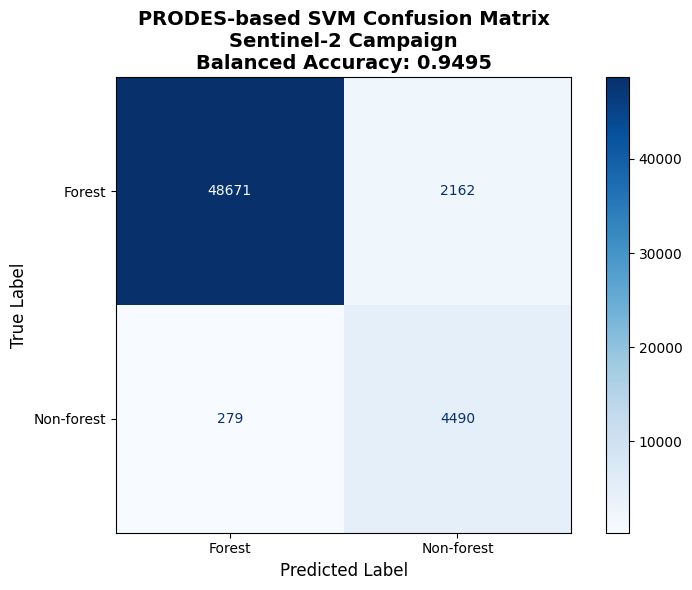


PRODES-based Classification Metrics
True Negatives (Forest correctly classified):     48671
False Positives (Forest misclassified as Non-forest):  2162
False Negatives (Non-forest misclassified as Forest):   279
True Positives (Non-forest correctly classified):     4490

Total samples: 55602
Accuracy: 0.9561
Balanced Accuracy: 0.9495


In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-train PRODES-based SVM with proper methodology
svm_prodes_retrain = SVC(C=1.0, kernel='linear', random_state=RANDOM_SEED, verbose=False)
svm_prodes_retrain.fit(X_train_PRODES_scaled, y_train_PRODES_class)

# Generate predictions for test set
y_test_prodes_based = svm_prodes_retrain.predict(X_test_PRODES_scaled)
scores_test_prodes_based = balanced_accuracy_score(y_test, y_test_prodes_based)
# Generate confusion matrix for PRODES-based classification
cm = confusion_matrix(y_test, y_test_prodes_based, labels=['Forest', 'Non-forest'])

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Forest', 'Non-forest'])
disp.plot(ax=ax, cmap='Blues', values_format='d')

# Add title and labels
plt.title(f'PRODES-based SVM Confusion Matrix\n{CAMPAIGN_NAME}\nBalanced Accuracy: {scores_test_prodes_based:.4f}', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# Print detailed metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n{'='*60}")
print(f"PRODES-based Classification Metrics")
print(f"{'='*60}")
print(f"True Negatives (Forest correctly classified):     {tn:5d}")
print(f"False Positives (Forest misclassified as Non-forest): {fp:5d}")
print(f"False Negatives (Non-forest misclassified as Forest): {fn:5d}")
print(f"True Positives (Non-forest correctly classified):    {tp:5d}")
print(f"\nTotal samples: {tn + fp + fn + tp}")
print(f"Accuracy: {(tn + tp) / (tn + fp + fn + tp):.4f}")
print(f"Balanced Accuracy: {scores_test_prodes_based:.4f}")
print(f"{'='*60}")

#### Plot com dados balanceados x desbalanceados

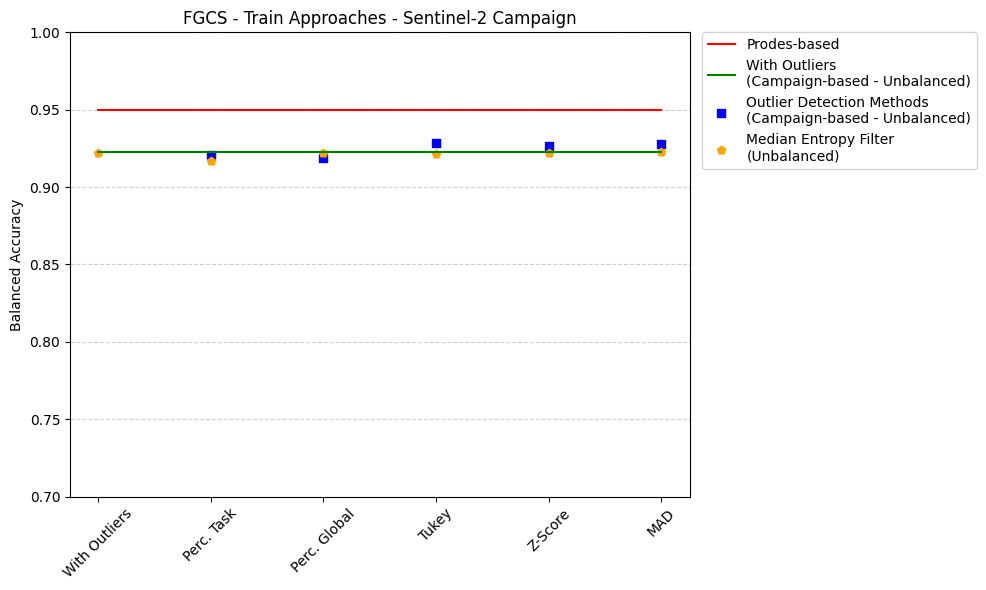

In [67]:
remove_outliers_approach_names = ['With Outliers', 'Perc. Task', 'Perc. Global', 'Tukey', 'Z-Score', 'MAD']

# Extract mean balanced accuracy from df_metrics for plotting
def extract_mean(value_str):
    """Extract mean value from 'mean ± std' string format."""
    return float(value_str.split(' ± ')[0])

# Get PRODES-based score (single value, repeated for all x positions)
prodes_bal_acc = extract_mean(df_metrics[df_metrics['Method'] == 'PRODES-based']['Test Bal. Acc.'].values[0])
prodes_scores = [prodes_bal_acc] * len(remove_outliers_approach_names)

# Get Campaign-based scores for each outlier approach
campaign_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Campaign-based') & 
                                           (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                   for outlier in remove_outliers_approach_names]

# Get Campaign + Median Entropy scores for each outlier approach
median_entropy_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Campaign + Median Entropy') & 
                                                  (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                         for outlier in remove_outliers_approach_names]

# Posições no eixo X ----------------------
x = np.arange(len(remove_outliers_approach_names))

# Plot ------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(x, prodes_scores, label='Prodes-based', color='red')
plt.plot(x, [campaign_scores[0]] * len(x), label='With Outliers\n(Campaign-based - Unbalanced)', color='green')
plt.scatter(x, [0] + campaign_scores[1:], label='Outlier Detection Methods\n(Campaign-based - Unbalanced)', marker='s', color='blue')
plt.scatter(x, median_entropy_scores, label='Median Entropy Filter\n(Unbalanced)', marker='p', color='orange')

plt.xticks(x, remove_outliers_approach_names, rotation=45)
plt.ylabel("Balanced Accuracy")
plt.ylim(0.7, 1)
plt.title(f'FGCS - Train Approaches - {CAMPAIGN_NAME}')

plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

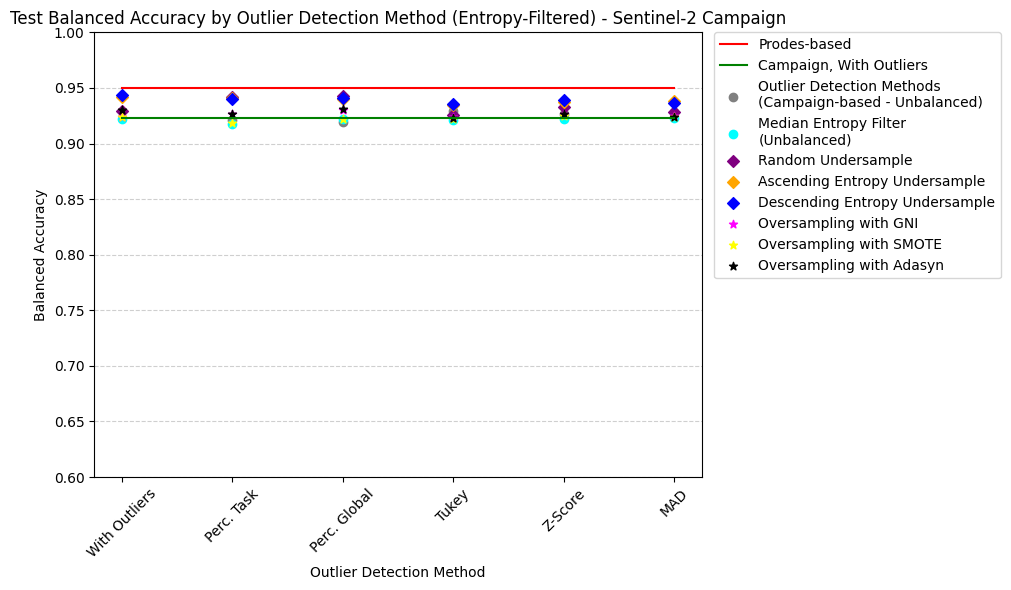

In [68]:
remove_outliers_approach_names = ['With Outliers', 'Perc. Task', 'Perc. Global', 'Tukey', 'Z-Score', 'MAD']

# Extract mean balanced accuracy from df_metrics for plotting
def extract_mean(value_str):
    """Extract mean value from 'mean ± std' string format."""
    return float(value_str.split(' ± ')[0])

# Get PRODES-based score (single value, repeated for all x positions)
prodes_bal_acc = extract_mean(df_metrics[df_metrics['Method'] == 'PRODES-based']['Test Bal. Acc.'].values[0])
prodes_scores = [prodes_bal_acc] * len(remove_outliers_approach_names)

# Get Campaign-based scores for each outlier approach
campaign_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Campaign-based') & 
                                           (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                   for outlier in remove_outliers_approach_names]

# Get Campaign + Median Entropy scores for each outlier approach
median_entropy_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Campaign + Median Entropy') & 
                                                  (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                         for outlier in remove_outliers_approach_names]

# Get Random Undersample scores
random_undersample_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Random Undersample') & 
                                                      (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                             for outlier in remove_outliers_approach_names]

# Get Ascending Entropy Undersample scores
ascending_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Ascending Entropy Undersample') & 
                                             (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                    for outlier in remove_outliers_approach_names]

# Get Descending Entropy Undersample scores
descending_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'Descending Entropy Undersample') & 
                                              (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                     for outlier in remove_outliers_approach_names]

# Get GNI scores
gni_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'GNI') & 
                                       (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
              for outlier in remove_outliers_approach_names]

# Get SMOTE scores
smote_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'SMOTE') & 
                                         (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                for outlier in remove_outliers_approach_names]

# Posições no eixo X ----------------------
x = np.arange(len(remove_outliers_approach_names))

# Plot ------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(x, prodes_scores, label='Prodes-based', color='red')
plt.plot(x, [campaign_scores[0]] * len(x), label='Campaign, With Outliers', color='green')
plt.scatter(x, [0] + campaign_scores[1:], label='Outlier Detection Methods\n(Campaign-based - Unbalanced)', marker='o', color='gray')
plt.scatter(x, median_entropy_scores, label='Median Entropy Filter\n(Unbalanced)', marker='o', color='cyan')
plt.scatter(x, random_undersample_scores, label='Random Undersample', marker='D', color='purple')
plt.scatter(x, ascending_scores, label='Ascending Entropy Undersample', marker='D', color='orange')
plt.scatter(x, descending_scores, label='Descending Entropy Undersample', marker='D', color='blue')
plt.scatter(x, gni_scores, label='Oversampling with GNI', marker='*', color='magenta')
plt.scatter(x, smote_scores, label='Oversampling with SMOTE', marker='*', color='yellow')

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    # Get ADASYN scores
    adasyn_scores = [extract_mean(df_metrics[(df_metrics['Method'] == 'ADASYN') & 
                                              (df_metrics['Outlier Approach'] == outlier)]['Test Bal. Acc.'].values[0])
                     for outlier in remove_outliers_approach_names]
    plt.scatter(x, adasyn_scores, label='Oversampling with Adasyn', marker='*', color='black')

plt.xticks(x, remove_outliers_approach_names, rotation=45)
plt.xlabel("Outlier Detection Method")
plt.ylabel("Balanced Accuracy")
plt.ylim(0.6, 1)

# if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_ORIGINAL_CAMPAIGN_DATA':
#     plt.title(f'FGCS + Balanced Data (Over Robust Statistics + Original Campaing Data) - Train Approaches - {CAMPAIGN_NAME}')
# else:
#     plt.title(f'FGCS + Balanced Data (Over Robust Statistics + Median Entropy Filter) - Train Approaches - {CAMPAIGN_NAME}')

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_ORIGINAL_CAMPAIGN_DATA':
    plt.title(f'Test Balanced Accuracy by Outlier Detection Method - {CAMPAIGN_NAME}')
else:
    plt.title(f'Test Balanced Accuracy by Outlier Detection Method (Entropy-Filtered) - {CAMPAIGN_NAME}')

plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
    frameon=True)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [69]:
print("=== SANITY CHECK: Comparing all approaches with PRODES-based ===\n")
print(f"PRODES-based Balanced Accuracy: {scores_test_prodes_based:.3f}\n")

# Check Campaign-based
print("Campaign-based (Unbalanced):")
for idx, score in enumerate(scores_test_campaign_based):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

# Check Campaign-based + Median Entropy Filter
print("\nCampaign-based + Median Entropy Filter (Unbalanced):")
for idx, score in enumerate(scores_test_campaign_based_filtered_by_entropy):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

# Check Balanced approaches
print("\nRandom Undersampling:")
for idx, score in enumerate(scores_test_random_undersample):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

print("\nAscending Entropy Undersampling:")
for idx, score in enumerate(scores_test_ascending_entropy_undersample):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

print("\nDescending Entropy Undersampling:")
for idx, score in enumerate(scores_test_descending_entropy_undersample):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

print("\nGaussian Noise Injection (GNI):")
for idx, score in enumerate(scores_test_gni):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

print("\nSMOTE:")
for idx, score in enumerate(scores_test_smote):
    approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
    status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
    print(f"  {approach}: {score:.3f} {status}")

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    print("\nADASYN:")
    for idx, score in enumerate(scores_test_adasyn):
        approach = remove_outliers_approach_names[idx] if idx < len(remove_outliers_approach_names) else f"Approach {idx}"
        status = "✓ PASS" if score <= scores_test_prodes_based else "✗ FAIL"
        print(f"  {approach}: {score:.3f} {status}")

print("\n=== END OF SANITY CHECK ===")

# Final check to see if there were any failures
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

all_scores = {
    "Campaign-based (Unbalanced)": scores_test_campaign_based,
    "Campaign-based + Median Entropy Filter (Unbalanced)": scores_test_campaign_based_filtered_by_entropy,
    "Random Undersampling": scores_test_random_undersample,
    "Ascending Entropy Undersampling": scores_test_ascending_entropy_undersample,
    "Descending Entropy Undersampling": scores_test_descending_entropy_undersample,
    "Gaussian Noise Injection (GNI)": scores_test_gni,
    "SMOTE": scores_test_smote
}

if OVERSAMP_UNDERSAMP_DA_FLOW == 'OVER_FILTERED_BY_MEDIAN_ENTROPY':
    all_scores["ADASYN"] = scores_test_adasyn

any_fail = False
for method_name, scores_list in all_scores.items():
    for idx, score in enumerate(scores_list):
        if score > scores_test_prodes_based:
            any_fail = True
            break
    if any_fail:
        break

if any_fail:
    print("❌ RESULT: At least one approach FAILED (exceeded PRODES-based accuracy)")
else:
    print("✅ RESULT: All approaches PASSED (none exceeded PRODES-based accuracy)")

print("="*60)

=== SANITY CHECK: Comparing all approaches with PRODES-based ===

PRODES-based Balanced Accuracy: 0.949

Campaign-based (Unbalanced):
  With Outliers: 0.923 ✓ PASS
  Perc. Task: 0.922 ✓ PASS
  Perc. Global: 0.919 ✓ PASS
  Tukey: 0.930 ✓ PASS
  Z-Score: 0.928 ✓ PASS
  MAD: 0.928 ✓ PASS

Campaign-based + Median Entropy Filter (Unbalanced):
  With Outliers: 0.918 ✓ PASS
  Perc. Task: 0.917 ✓ PASS
  Perc. Global: 0.922 ✓ PASS
  Tukey: 0.922 ✓ PASS
  Z-Score: 0.920 ✓ PASS
  MAD: 0.914 ✓ PASS

Random Undersampling:
  With Outliers: 0.926 ✓ PASS
  Perc. Task: 0.942 ✓ PASS
  Perc. Global: 0.943 ✓ PASS
  Tukey: 0.933 ✓ PASS
  Z-Score: 0.935 ✓ PASS
  MAD: 0.923 ✓ PASS

Ascending Entropy Undersampling:
  With Outliers: 0.941 ✓ PASS
  Perc. Task: 0.940 ✓ PASS
  Perc. Global: 0.944 ✓ PASS
  Tukey: 0.936 ✓ PASS
  Z-Score: 0.930 ✓ PASS
  MAD: 0.937 ✓ PASS

Descending Entropy Undersampling:
  With Outliers: 0.940 ✓ PASS
  Perc. Task: 0.946 ✓ PASS
  Perc. Global: 0.938 ✓ PASS
  Tukey: 0.937 ✓ PASS
  Z-

In [70]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for SVM
# param_grid = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'kernel': ['linear', 'rbf', 'poly'],
#     'gamma': ['scale', 'auto', 0.01, 0.1, 1],  # Only used for rbf and poly
# }

param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'] # essential if your "balanced" approach isn't 50/50
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100], 
        'gamma': ['scale', 0.001, 0.01], # Avoid 'auto' or large integers
        'class_weight': [None, 'balanced']
    }
]

# Find best performing method from unbalanced approaches
# From the results: scores_test_campaign_based and scores_test_campaign_based_filtered_by_entropy
all_unbalanced_scores = {
    'Campaign-based': scores_test_campaign_based,
    'Median Entropy Filter': scores_test_campaign_based_filtered_by_entropy
}

# Find best unbalanced approach and its index
best_unbalanced_score = 0
best_unbalanced_name = ""
best_unbalanced_idx = 0
for name, scores in all_unbalanced_scores.items():
    for idx, score in enumerate(scores):
        if score > best_unbalanced_score:
            best_unbalanced_score = score
            best_unbalanced_name = name
            best_unbalanced_idx = idx

print(f"Best Unbalanced Approach: {best_unbalanced_name} - {remove_outliers_approach_names[best_unbalanced_idx]}")
print(f"Best Unbalanced Score: {best_unbalanced_score:.4f}")
print(f"PRODES-based Score: {scores_test_prodes_based:.4f}\n")

# Find best performing method from balanced approaches
all_balanced_scores = {
    'Random Undersample': scores_test_random_undersample,
    'Ascending Entropy Undersample': scores_test_ascending_entropy_undersample,
    'Descending Entropy Undersample': scores_test_descending_entropy_undersample,
    'GNI': scores_test_gni,
    'SMOTE': scores_test_smote,
    'ADASYN': scores_test_adasyn
}

best_balanced_score = 0
best_balanced_name = ""
best_balanced_idx = 0
for name, scores in all_balanced_scores.items():
    for idx, score in enumerate(scores):
        if score > best_balanced_score:
            best_balanced_score = score
            best_balanced_name = name
            best_balanced_idx = idx

print(f"Best Balanced Approach: {best_balanced_name} - {remove_outliers_approach_names[best_balanced_idx]}")
print(f"Best Balanced Score: {best_balanced_score:.4f}")
print(f"PRODES-based Score: {scores_test_prodes_based:.4f}\n")

# Prepare data for GridSearch based on best approaches
# Unbalanced best
if best_unbalanced_name == 'Campaign-based':
    X_train_best_unbalanced = X_train_campaign_scaled[best_unbalanced_idx]
    y_train_best_unbalanced = y_train_Majority_response_without_draws_and_undefined_sorted[best_unbalanced_idx]
    X_test_best_unbalanced = X_test_campaign_scaled[best_unbalanced_idx]
else:
    X_train_best_unbalanced = X_train_filtered_by_entropy_scaled[best_unbalanced_idx]
    y_train_best_unbalanced = y_train_filtered_by_entropy_sorted[best_unbalanced_idx]
    X_test_best_unbalanced = X_test_filtered_by_entropy_scaled[best_unbalanced_idx]

# Balanced best
if best_balanced_name == 'Random Undersample':
    X_train_best_balanced = X_train_random_undersampling[best_balanced_idx]
    y_train_best_balanced = y_train_random_undersampling[best_balanced_idx]
elif best_balanced_name == 'Ascending Entropy Undersample':
    X_train_best_balanced = X_train_ascending_entropy_undersampling[best_balanced_idx]
    y_train_best_balanced = y_train_ascending_entropy_undersampling[best_balanced_idx]
elif best_balanced_name == 'Descending Entropy Undersample':
    X_train_best_balanced = X_train_descending_entropy_undersampling[best_balanced_idx]
    y_train_best_balanced = y_train_descending_entropy_undersampling[best_balanced_idx]
elif best_balanced_name == 'GNI':
    X_train_best_balanced = X_train_gni[best_balanced_idx]
    y_train_best_balanced = y_train_gni[best_balanced_idx]
elif best_balanced_name == 'SMOTE':
    X_train_best_balanced = X_train_smote[best_balanced_idx]
    y_train_best_balanced = y_train_smote[best_balanced_idx]
else:  # ADASYN
    X_train_best_balanced = X_train_adasyn[best_balanced_idx]
    y_train_best_balanced = y_train_adasyn[best_balanced_idx]

X_test_best_balanced = X_test_filtered_by_entropy_scaled[best_balanced_idx]

# GridSearch for Unbalanced
print("=" * 60)
print("GridSearch for Best UNBALANCED Approach")
print("=" * 60)

grid_search_unbalanced = GridSearchCV(
    SVC(random_state=RANDOM_SEED),
    param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_unbalanced.fit(X_train_best_unbalanced, y_train_best_unbalanced)

y_pred_unbalanced_tuned = grid_search_unbalanced.predict(X_test_best_unbalanced)
score_unbalanced_tuned = balanced_accuracy_score(y_test, y_pred_unbalanced_tuned)

print(f"\nBest Parameters: {grid_search_unbalanced.best_params_}")
print(f"Best CV Score: {grid_search_unbalanced.best_score_:.4f}")
print(f"Test Score (before tuning): {best_unbalanced_score:.4f}")
print(f"Test Score (after tuning): {score_unbalanced_tuned:.4f}")
print(f"Improvement: {score_unbalanced_tuned - best_unbalanced_score:.4f} ({'YES' if score_unbalanced_tuned > best_unbalanced_score else 'NO'})")

# GridSearch for Balanced
print("\n" + "=" * 60)
print("GridSearch for Best BALANCED Approach")
print("=" * 60)

grid_search_balanced = GridSearchCV(
    SVC(random_state=RANDOM_SEED),
    param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search_balanced.fit(X_train_best_balanced, y_train_best_balanced)

y_pred_balanced_tuned = grid_search_balanced.predict(X_test_best_balanced)
score_balanced_tuned = balanced_accuracy_score(y_test, y_pred_balanced_tuned)

print(f"\nBest Parameters: {grid_search_balanced.best_params_}")
print(f"Best CV Score: {grid_search_balanced.best_score_:.4f}")
print(f"Test Score (before tuning): {best_balanced_score:.4f}")
print(f"Test Score (after tuning): {score_balanced_tuned:.4f}")
print(f"Improvement: {score_balanced_tuned - best_balanced_score:.4f} ({'YES' if score_balanced_tuned > best_balanced_score else 'NO'})")

# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nBest Unbalanced ({best_unbalanced_name} - {remove_outliers_approach_names[best_unbalanced_idx]}):")
print(f"  Before tuning: {best_unbalanced_score:.4f}")
print(f"  After tuning:  {score_unbalanced_tuned:.4f}")
print(f"  Best SVM Config: {grid_search_unbalanced.best_params_}")

print(f"\nBest Balanced ({best_balanced_name} - {remove_outliers_approach_names[best_balanced_idx]}):")
print(f"  Before tuning: {best_balanced_score:.4f}")
print(f"  After tuning:  {score_balanced_tuned:.4f}")
print(f"  Best SVM Config: {grid_search_balanced.best_params_}")

print(f"\nPRODES-based reference: {scores_test_prodes_based:.4f}")

Best Unbalanced Approach: Campaign-based - Tukey
Best Unbalanced Score: 0.9297
PRODES-based Score: 0.9495

Best Balanced Approach: Descending Entropy Undersample - Perc. Task
Best Balanced Score: 0.9458
PRODES-based Score: 0.9495

GridSearch for Best UNBALANCED Approach
Fitting 5 folds for each of 34 candidates, totalling 170 fits

Best Parameters: {'C': 100, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score: 0.9325
Test Score (before tuning): 0.9297
Test Score (after tuning): 0.9122
Improvement: -0.0175 (NO)

GridSearch for Best BALANCED Approach
Fitting 5 folds for each of 34 candidates, totalling 170 fits

Best Parameters: {'C': 0.1, 'class_weight': None, 'kernel': 'linear'}
Best CV Score: 0.9942
Test Score (before tuning): 0.9458
Test Score (after tuning): 0.9342
Improvement: -0.0116 (NO)

SUMMARY

Best Unbalanced (Campaign-based - Tukey):
  Before tuning: 0.9297
  After tuning:  0.9122
  Best SVM Config: {'C': 100, 'class_weight': 'balanced', 'gamma': 0.01,

In [71]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold

import torch.nn as nn
import torch.optim as optim

# ==================== PYTORCH REPRODUCIBILITY SETTINGS ====================
RANDOM_SEED = 42

# Set seeds for reproducibility
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)  # For multi-GPU setups
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Enable deterministic algorithms
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# For PyTorch >= 1.8, enable full determinism
if hasattr(torch, 'use_deterministic_algorithms'):
    torch.use_deterministic_algorithms(True, warn_only=True)

# Create a generator for DataLoader reproducibility
def get_generator(seed=RANDOM_SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return g
# ==========================================================================

# Define Conv1D model
class Conv1DClassifier(nn.Module):
    def __init__(self, input_dim, num_classes=2):
        super(Conv1DClassifier, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * (input_dim // 4), 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension: (batch, 1, features)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

def train_conv1d_model(X_train, y_train, X_test, y_test, epochs=50, batch_size=32, lr=0.001, seed=RANDOM_SEED):
    # Reset seeds before each training run for reproducibility
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    # Convert labels to numeric
    label_map = {'Forest': 0, 'Non-forest': 1}
    y_train_numeric = np.array([label_map[label] for label in y_train])
    y_test_numeric = np.array([label_map[label] for label in y_test])
    
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.LongTensor(y_train_numeric)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.LongTensor(y_test_numeric)
    
    # Create DataLoader with generator for reproducibility
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        generator=get_generator(seed),  # Use seeded generator for shuffle
        worker_init_fn=lambda worker_id: np.random.seed(seed + worker_id)
    )
    
    # Initialize model (weights will be deterministic due to torch.manual_seed)
    input_dim = X_train.shape[1]
    model = Conv1DClassifier(input_dim)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, predicted = torch.max(outputs, 1)
        y_pred = ['Forest' if p == 0 else 'Non-forest' for p in predicted.numpy()]
    
    return balanced_accuracy_score(y_test, y_pred)

# Train Conv1D on PRODES-based data
print("=" * 60)
print("Conv1D Neural Network Comparison")
print("=" * 60)

score_conv1d_prodes = train_conv1d_model(X_train_PRODES_scaled, y_train_PRODES_class, X_test_PRODES_scaled, y_test)
print(f"\nConv1D PRODES-based: {score_conv1d_prodes:.4f}")

# Train Conv1D on best unbalanced approach
score_conv1d_unbalanced = train_conv1d_model(X_train_best_unbalanced, y_train_best_unbalanced, X_test_best_unbalanced, y_test)
print(f"Conv1D Best Unbalanced ({best_unbalanced_name} - {remove_outliers_approach_names[best_unbalanced_idx]}): {score_conv1d_unbalanced:.4f}")

# Train Conv1D on best balanced approach
score_conv1d_balanced = train_conv1d_model(X_train_best_balanced, y_train_best_balanced, X_test_best_balanced, y_test)
print(f"Conv1D Best Balanced ({best_balanced_name} - {remove_outliers_approach_names[best_balanced_idx]}): {score_conv1d_balanced:.4f}")

# Summary comparison
print("\n" + "=" * 60)
print("FINAL COMPARISON: SVM vs Conv1D")
print("=" * 60)
print(f"\n{'Approach':<25} {'SVM':<12} {'Conv1D':<12}")
print("-" * 49)
print(f"{'PRODES-based':<25} {scores_test_prodes_based:.4f}       {score_conv1d_prodes:.4f}")
print(f"{'Best Unbalanced (tuned)':<25} {score_unbalanced_tuned:.4f}       {score_conv1d_unbalanced:.4f}")
print(f"{'Best Balanced (tuned)':<25} {score_balanced_tuned:.4f}       {score_conv1d_balanced:.4f}")
print("=" * 60)

Conv1D Neural Network Comparison

Conv1D PRODES-based: 0.9506
Conv1D Best Unbalanced (Campaign-based - Tukey): 0.9106
Conv1D Best Balanced (Descending Entropy Undersample - Perc. Task): 0.9356

FINAL COMPARISON: SVM vs Conv1D

Approach                  SVM          Conv1D      
-------------------------------------------------
PRODES-based              0.9495       0.9506
Best Unbalanced (tuned)   0.9122       0.9106
Best Balanced (tuned)     0.9342       0.9356


# Feature Correlation Analysis (Spearman)

Analyzing feature correlations across different data approaches to understand how balancing methods affect the natural feature structure.

**Strategy:**
1. Use **Spearman Rank Correlation** (safer for Haralick features with non-linear relationships)
2. Plot correlation heatmaps for each class separately (Class 0: Forest/Non-Defor, Class 1: Deforestation)
3. Use **Hierarchical Clustering** to group similar features visually
4. Generate **Difference/Distortion Heatmaps** to identify where balancing methods distorted the data

In [72]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Global variable to store the feature order from PRODES baseline
GLOBAL_FEATURE_ORDER = None

def compute_cluster_order(corr_matrix):
    """
    Compute hierarchical clustering order from a correlation matrix.
    Returns the feature order (list of indices).
    """
    # Convert correlation to distance
    dissimilarity = 1 - np.abs(corr_matrix.values)
    np.fill_diagonal(dissimilarity, 0)
    
    try:
        condensed_dist = squareform(dissimilarity)
        Z = linkage(condensed_dist, method='average')
        
        # Get the order from dendrogram
        dendro = dendrogram(Z, no_plot=True)
        return dendro['leaves']
    except Exception as e:
        print(f"  Warning: Clustering failed ({e}), using original order")
        return list(range(len(corr_matrix)))

def plot_feature_correlation(X_data, y_data, title_prefix="Dataset", method='spearman', 
                             use_clustering=True, feature_order=None, figsize=(24, 10)):
    """
    Plots Spearman correlation heatmaps for Class 0 and Class 1 separately.
    Uses hierarchical clustering to group similar features.
    
    Parameters:
    -----------
    X_data : array-like
        Feature matrix
    y_data : array-like  
        Target labels
    title_prefix : str
        Prefix for plot titles
    method : str
        Correlation method ('spearman' or 'pearson')
    use_clustering : bool
        Whether to apply hierarchical clustering to reorder features (only used if feature_order is None)
    feature_order : list or None
        Pre-computed feature order to use. If provided, this order is used for all heatmaps.
        If None and use_clustering=True, clustering is computed from this dataset.
    figsize : tuple
        Figure size
        
    Returns:
    --------
    corr_0, corr_1, feature_order : DataFrames + list
        Correlation matrices for each class and the feature order used
    """
    global GLOBAL_FEATURE_ORDER
    
    # Combine X and y temporarily to filter by class
    df = pd.DataFrame(X_data)
    
    # Convert labels to numeric for filtering
    if isinstance(y_data[0], str):
        label_map = {'Forest': 0, 'Non-forest': 1}
        y_numeric = np.array([label_map[label] for label in y_data])
    else:
        y_numeric = np.array(y_data)
    
    df['target'] = y_numeric
    
    # Split by class
    class_0 = df[df['target'] == 0].drop('target', axis=1)
    class_1 = df[df['target'] == 1].drop('target', axis=1)
    
    print(f"  Class 0 (Forest) samples: {len(class_0)}")
    print(f"  Class 1 (Non-forest/Deforestation) samples: {len(class_1)}")
    
    # Compute Correlations
    corr_0 = class_0.corr(method=method)
    corr_1 = class_1.corr(method=method)
    
    # Determine feature order
    if feature_order is not None:
        # Use provided feature order
        cluster_order = feature_order
        print(f"  Using provided feature order ({len(cluster_order)} features)")
    elif use_clustering and len(corr_0) > 1:
        # Compute clustering from this dataset (typically PRODES baseline)
        cluster_order = compute_cluster_order(corr_0)
        GLOBAL_FEATURE_ORDER = cluster_order  # Store globally for reuse
        print(f"  Computed new feature order via hierarchical clustering")
    else:
        cluster_order = list(range(len(corr_0)))
    
    # Reorder both correlation matrices using the same order
    corr_0 = corr_0.iloc[cluster_order, cluster_order]
    corr_1 = corr_1.iloc[cluster_order, cluster_order]
    
    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Mask to hide the upper triangle (cleaner visualization)
    mask = np.triu(np.ones_like(corr_0, dtype=bool))
    
    # Heatmap Class 0
    sns.heatmap(corr_0, ax=axes[0], mask=mask, cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True,
                cbar_kws={'shrink': 0.5, 'label': f'{method.capitalize()} Correlation'})
    axes[0].set_title(f'{title_prefix} - Class 0 (Forest)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Features', fontsize=10)
    axes[0].set_ylabel('Features', fontsize=10)
    
    # Heatmap Class 1
    sns.heatmap(corr_1, ax=axes[1], mask=mask, cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True,
                cbar_kws={'shrink': 0.5, 'label': f'{method.capitalize()} Correlation'})
    axes[1].set_title(f'{title_prefix} - Class 1 (Deforestation)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Features', fontsize=10)
    axes[1].set_ylabel('Features', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return corr_0, corr_1, cluster_order


def plot_difference_heatmap(corr_baseline, corr_experiment, title="Difference Heatmap",
                           threshold=0.3, figsize=(12, 10)):
    """
    Plots the absolute difference between two correlation matrices.
    Highlights where sampling methods distorted the feature correlations.
    
    Parameters:
    -----------
    corr_baseline : DataFrame
        Baseline correlation matrix (e.g., PRODES)
    corr_experiment : DataFrame
        Experimental correlation matrix (e.g., Balanced approach)
    title : str
        Title describing the comparison
    threshold : float
        Values above this threshold are considered significant distortion
    figsize : tuple
        Figure size
    """
    # Align matrices (ensure same column order)
    common_cols = corr_baseline.columns.intersection(corr_experiment.columns)
    corr_baseline_aligned = corr_baseline.loc[common_cols, common_cols]
    corr_experiment_aligned = corr_experiment.loc[common_cols, common_cols]
    
    # Calculate absolute difference
    diff = np.abs(corr_baseline_aligned - corr_experiment_aligned)
    
    # Count significant distortions
    mask_lower = np.tril(np.ones_like(diff, dtype=bool), k=-1)
    significant_distortions = (diff.values[mask_lower] > threshold).sum()
    total_pairs = mask_lower.sum()
    distortion_pct = 100 * significant_distortions / total_pairs
    
    plt.figure(figsize=figsize)
    
    # Mask upper triangle
    mask = np.triu(np.ones_like(diff, dtype=bool))
    
    sns.heatmap(diff, mask=mask, cmap='viridis', vmin=0, vmax=0.5, 
                square=True, cbar_kws={'shrink': 0.5, 'label': 'Absolute Correlation Difference'})
    
    plt.title(f"Distortion: |{title}|\n"
              f"({significant_distortions} pairs with diff > {threshold} = {distortion_pct:.1f}%)", 
              fontsize=12, fontweight='bold')
    plt.xlabel('Features', fontsize=10)
    plt.ylabel('Features', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    return diff, significant_distortions


def summarize_correlation_stats(corr_matrix, name):
    """
    Summarizes key statistics from a correlation matrix.
    """
    mask_lower = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)
    values = corr_matrix.values[mask_lower]
    
    print(f"\n{name}:")
    print(f"  Mean correlation: {np.mean(values):.4f}")
    print(f"  Std correlation:  {np.std(values):.4f}")
    print(f"  Min correlation:  {np.min(values):.4f}")
    print(f"  Max correlation:  {np.max(values):.4f}")
    print(f"  High correlations (|r| > 0.7): {(np.abs(values) > 0.7).sum()}")
    print(f"  Medium correlations (0.4 < |r| <= 0.7): {((np.abs(values) > 0.4) & (np.abs(values) <= 0.7)).sum()}")

## 1. PRODES-based Correlation Heatmaps (Reference Baseline)

1. PRODES-based Correlation Heatmaps (Reference Baseline)
  Class 0 (Forest) samples: 900
  Class 1 (Non-forest/Deforestation) samples: 900
  Computed new feature order via hierarchical clustering


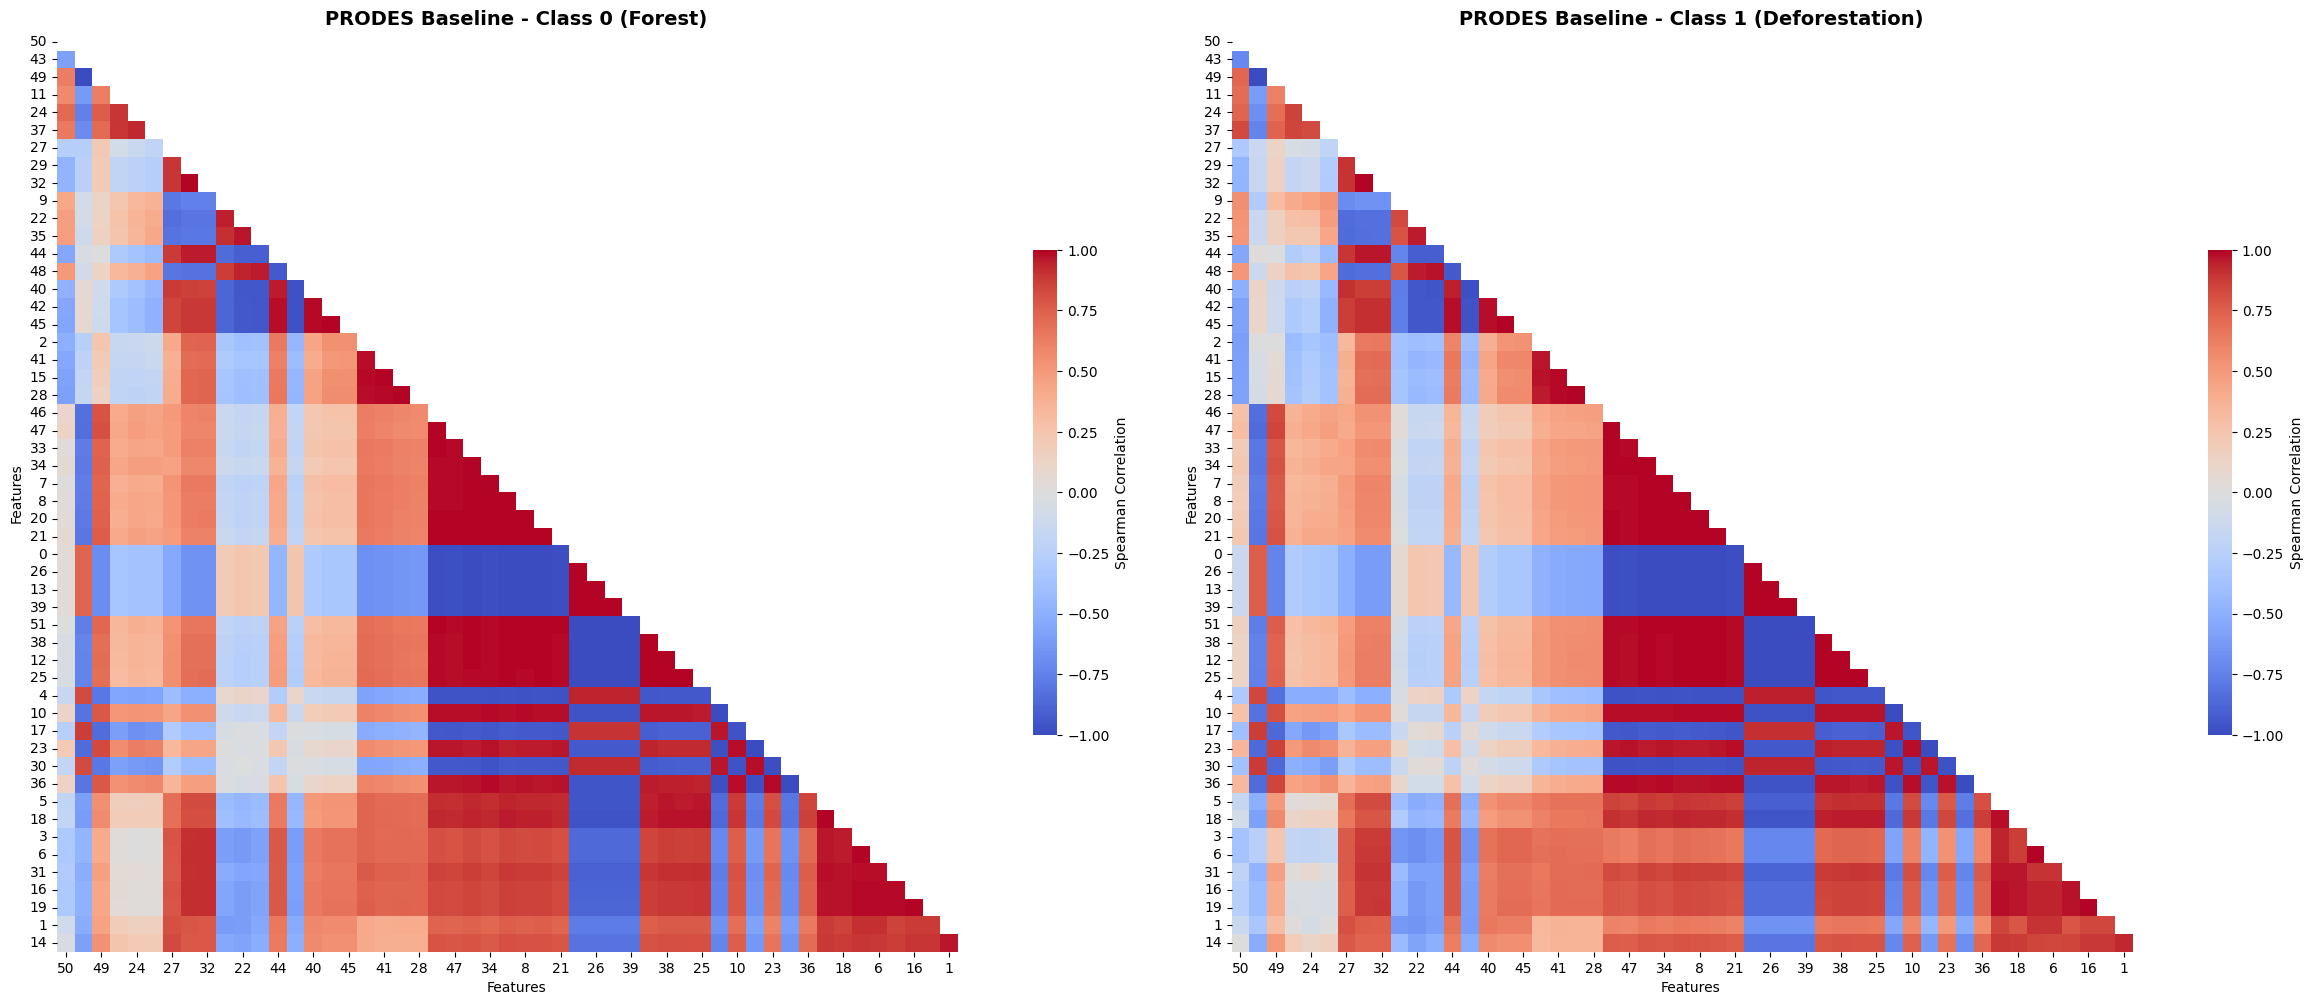


PRODES Class 0 (Forest):
  Mean correlation: 0.1710
  Std correlation:  0.6720
  Min correlation:  -0.9979
  Max correlation:  1.0000
  High correlations (|r| > 0.7): 618
  Medium correlations (0.4 < |r| <= 0.7): 368

PRODES Class 1 (Deforestation):
  Mean correlation: 0.1591
  Std correlation:  0.6541
  Min correlation:  -0.9981
  Max correlation:  1.0000
  High correlations (|r| > 0.7): 566
  Medium correlations (0.4 < |r| <= 0.7): 387

✓ Feature order established from PRODES baseline (52 features)
  This order will be used for all subsequent heatmaps for consistency.


In [73]:
# Generate PRODES-based Heatmaps (Reference Baseline)
# This establishes the feature order that will be used for ALL heatmaps
print("=" * 60)
print("1. PRODES-based Correlation Heatmaps (Reference Baseline)")
print("=" * 60)

corr_prodes_0, corr_prodes_1, prodes_feature_order = plot_feature_correlation(
    X_train_PRODES_scaled, 
    y_train_PRODES_class, 
    title_prefix="PRODES Baseline",
    method='spearman',
    feature_order=None  # Compute clustering order from PRODES (baseline)
)

# Print summary statistics
summarize_correlation_stats(corr_prodes_0, "PRODES Class 0 (Forest)")
summarize_correlation_stats(corr_prodes_1, "PRODES Class 1 (Deforestation)")

print(f"\n✓ Feature order established from PRODES baseline ({len(prodes_feature_order)} features)")
print("  This order will be used for all subsequent heatmaps for consistency.")

## 2. Best Unbalanced Approach Correlation Heatmaps

2. Best Unbalanced Approach: Campaign-based
   Outlier removal: Tukey
  Class 0 (Forest) samples: 1053
  Class 1 (Non-forest/Deforestation) samples: 706
  Using provided feature order (52 features)


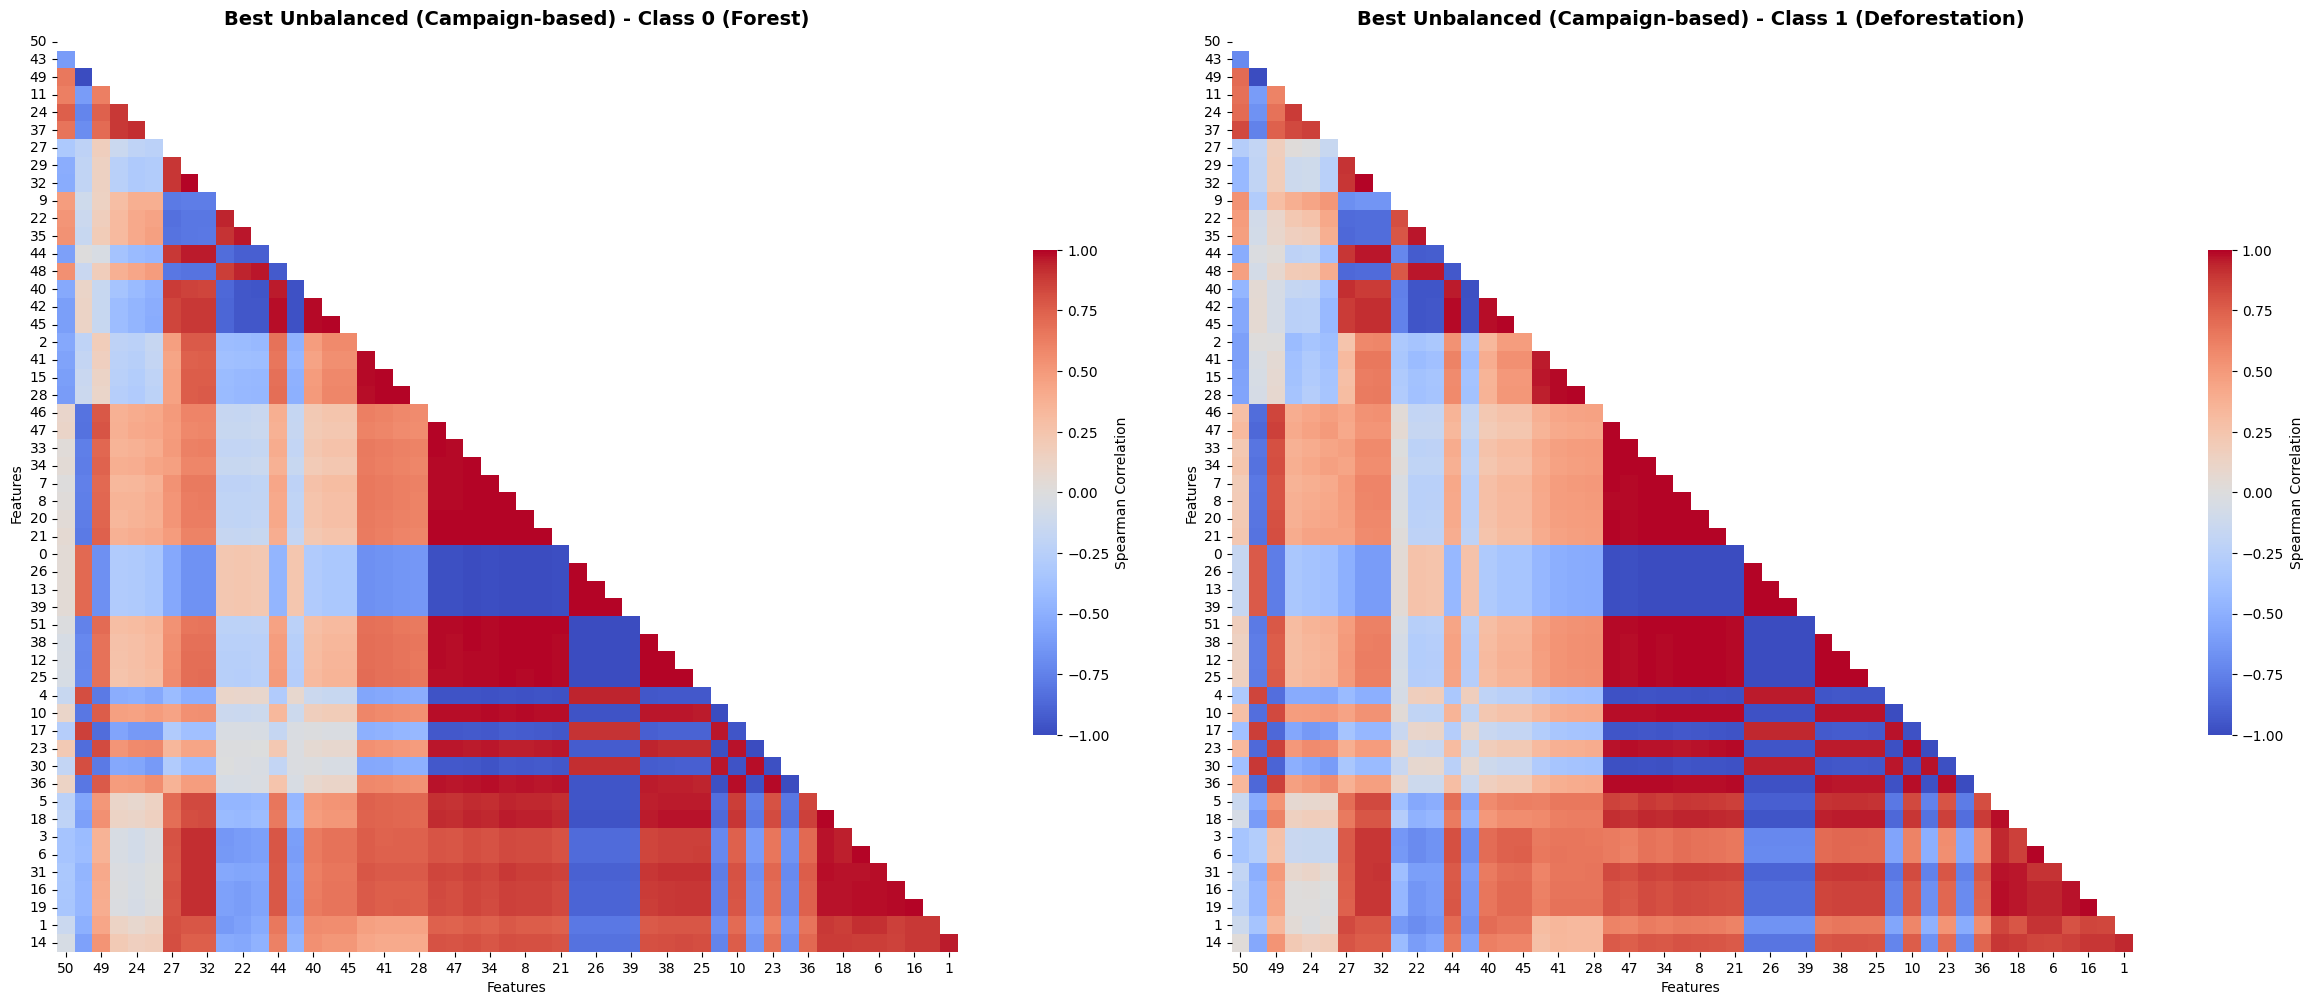


Best Unbalanced Class 0 (Forest):
  Mean correlation: 0.1683
  Std correlation:  0.6728
  Min correlation:  -0.9980
  Max correlation:  1.0000
  High correlations (|r| > 0.7): 619
  Medium correlations (0.4 < |r| <= 0.7): 373

Best Unbalanced Class 1 (Deforestation):
  Mean correlation: 0.1595
  Std correlation:  0.6559
  Min correlation:  -0.9981
  Max correlation:  1.0000
  High correlations (|r| > 0.7): 565
  Medium correlations (0.4 < |r| <= 0.7): 373


In [74]:
# Generate Best Unbalanced Approach Heatmaps
# Using the same feature order as PRODES baseline for consistency
print("=" * 60)
print(f"2. Best Unbalanced Approach: {best_unbalanced_name}")
print(f"   Outlier removal: {remove_outliers_approach_names[best_unbalanced_idx]}")
print("=" * 60)

corr_unbal_0, corr_unbal_1, _ = plot_feature_correlation(
    X_train_best_unbalanced, 
    y_train_best_unbalanced, 
    title_prefix=f"Best Unbalanced ({best_unbalanced_name})",
    method='spearman',
    feature_order=prodes_feature_order  # Use PRODES feature order
)

# Print summary statistics
summarize_correlation_stats(corr_unbal_0, "Best Unbalanced Class 0 (Forest)")
summarize_correlation_stats(corr_unbal_1, "Best Unbalanced Class 1 (Deforestation)")

## 3. Best Balanced Approach Correlation Heatmaps

3. Best Balanced Approach: Descending Entropy Undersample
   Outlier removal: Perc. Task
  Class 0 (Forest) samples: 260
  Class 1 (Non-forest/Deforestation) samples: 260
  Using provided feature order (52 features)


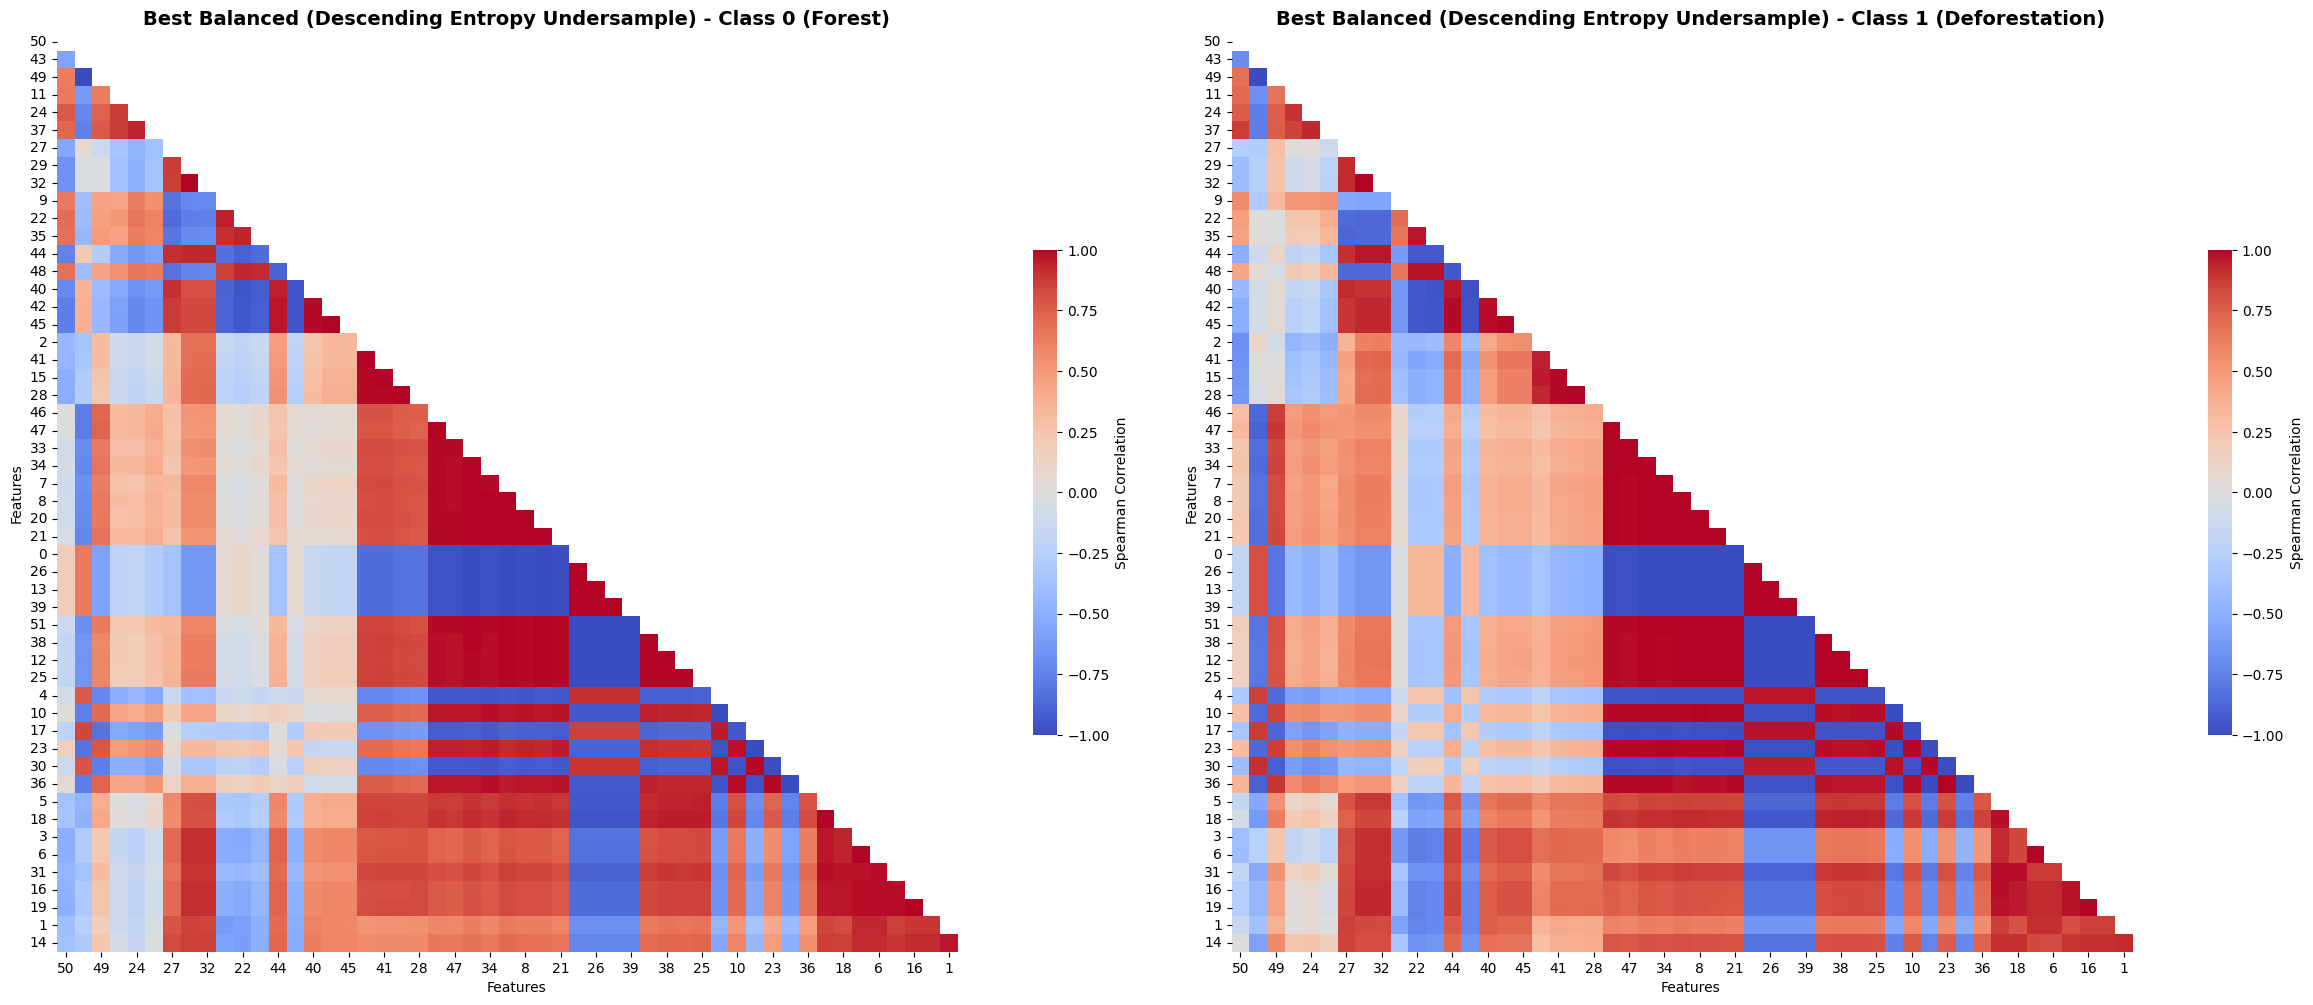


Best Balanced Class 0 (Forest):
  Mean correlation: 0.1647
  Std correlation:  0.6613
  Min correlation:  -0.9988
  Max correlation:  1.0000
  High correlations (|r| > 0.7): 640
  Medium correlations (0.4 < |r| <= 0.7): 281

Best Balanced Class 1 (Deforestation):
  Mean correlation: 0.1632
  Std correlation:  0.6694
  Min correlation:  -0.9983
  Max correlation:  1.0000
  High correlations (|r| > 0.7): 590
  Medium correlations (0.4 < |r| <= 0.7): 404


In [75]:
# Generate Best Balanced Approach Heatmaps
# Using the same feature order as PRODES baseline for consistency
print("=" * 60)
print(f"3. Best Balanced Approach: {best_balanced_name}")
print(f"   Outlier removal: {remove_outliers_approach_names[best_balanced_idx]}")
print("=" * 60)

corr_bal_0, corr_bal_1, _ = plot_feature_correlation(
    X_train_best_balanced, 
    y_train_best_balanced, 
    title_prefix=f"Best Balanced ({best_balanced_name})",
    method='spearman',
    feature_order=prodes_feature_order  # Use PRODES feature order
)

# Print summary statistics
summarize_correlation_stats(corr_bal_0, "Best Balanced Class 0 (Forest)")
summarize_correlation_stats(corr_bal_1, "Best Balanced Class 1 (Deforestation)")

## 4. Distortion Analysis: Difference Heatmaps

The difference heatmaps reveal **where** your balancing method distorted the data.

**What to look for:**
- **Red areas** = High distortion (correlations changed significantly)
- **"Fading" Effect** = If the balanced heatmap has paler colors, the balancing added noise that diluted feature relationships
- **"Hallucination" Effect** = New red spots in the balanced heatmap that don't exist in PRODES indicate artificially created patterns (common cause of high CV but lower test scores)

DISTORTION ANALYSIS: Comparing to PRODES Baseline

--- Best Unbalanced vs PRODES: Class 0 (Forest) ---

--- Best Unbalanced vs PRODES: Class 1 (Deforestation) ---

--- Best Balanced vs PRODES: Class 0 (Forest) ---

--- Best Balanced vs PRODES: Class 1 (Deforestation) ---


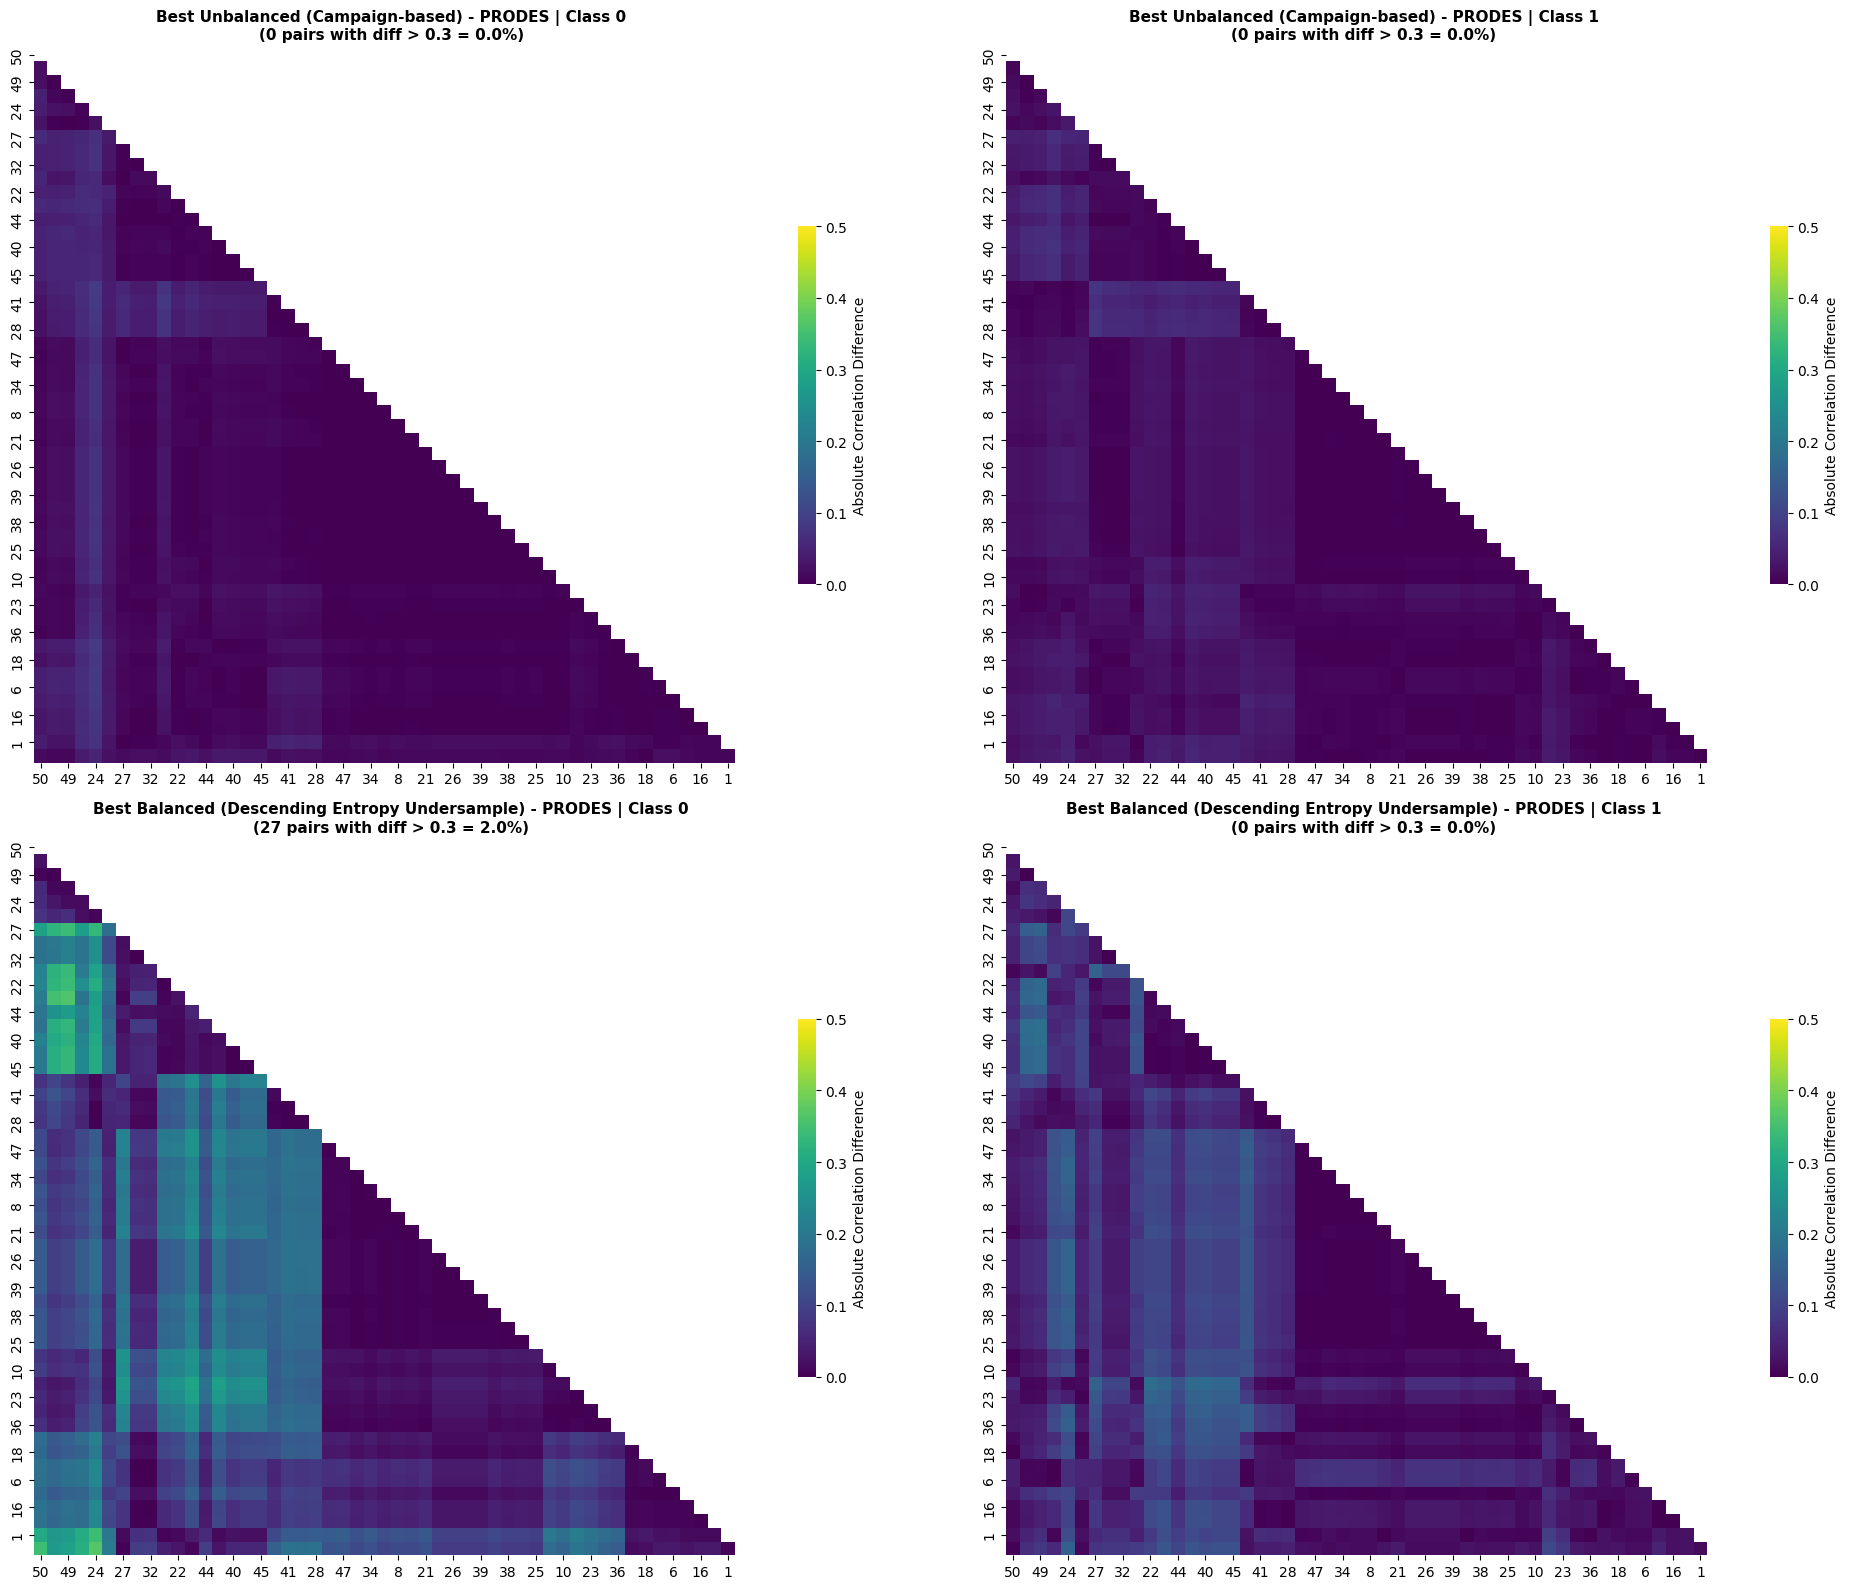


DISTORTION SUMMARY
                                      Approach             Class  Distorted Pairs
              Best Unbalanced (Campaign-based)        Forest (0)                0
              Best Unbalanced (Campaign-based) Deforestation (1)                0
Best Balanced (Descending Entropy Undersample)        Forest (0)               27
Best Balanced (Descending Entropy Undersample) Deforestation (1)                0


In [76]:
# Distortion Analysis: Compare each approach to PRODES baseline
print("=" * 60)
print("DISTORTION ANALYSIS: Comparing to PRODES Baseline")
print("=" * 60)

# Create figure with 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 4.1 Best Unbalanced vs PRODES - Class 0 (Forest)
print("\n--- Best Unbalanced vs PRODES: Class 0 (Forest) ---")
diff_unbal_0 = np.abs(corr_prodes_0 - corr_unbal_0)
mask_lower = np.tril(np.ones_like(diff_unbal_0, dtype=bool), k=-1)
threshold = 0.3
significant_distortions_unbal_0 = (diff_unbal_0.values[mask_lower] > threshold).sum()
total_pairs = mask_lower.sum()
distortion_pct_unbal_0 = 100 * significant_distortions_unbal_0 / total_pairs

mask = np.triu(np.ones_like(diff_unbal_0, dtype=bool))
sns.heatmap(diff_unbal_0, mask=mask, cmap='viridis', vmin=0, vmax=0.5, 
            square=True, cbar_kws={'shrink': 0.5, 'label': 'Absolute Correlation Difference'},
            ax=axes[0, 0])
axes[0, 0].set_title(f"Best Unbalanced ({best_unbalanced_name}) - PRODES | Class 0\n"
                     f"({significant_distortions_unbal_0} pairs with diff > {threshold} = {distortion_pct_unbal_0:.1f}%)", 
                     fontsize=11, fontweight='bold')

# 4.2 Best Unbalanced vs PRODES - Class 1 (Deforestation)
print("\n--- Best Unbalanced vs PRODES: Class 1 (Deforestation) ---")
diff_unbal_1 = np.abs(corr_prodes_1 - corr_unbal_1)
significant_distortions_unbal_1 = (diff_unbal_1.values[mask_lower] > threshold).sum()
distortion_pct_unbal_1 = 100 * significant_distortions_unbal_1 / total_pairs

sns.heatmap(diff_unbal_1, mask=mask, cmap='viridis', vmin=0, vmax=0.5, 
            square=True, cbar_kws={'shrink': 0.5, 'label': 'Absolute Correlation Difference'},
            ax=axes[0, 1])
axes[0, 1].set_title(f"Best Unbalanced ({best_unbalanced_name}) - PRODES | Class 1\n"
                     f"({significant_distortions_unbal_1} pairs with diff > {threshold} = {distortion_pct_unbal_1:.1f}%)", 
                     fontsize=11, fontweight='bold')

# 4.3 Best Balanced vs PRODES - Class 0 (Forest)
print("\n--- Best Balanced vs PRODES: Class 0 (Forest) ---")
diff_bal_0 = np.abs(corr_prodes_0 - corr_bal_0)
significant_distortions_bal_0 = (diff_bal_0.values[mask_lower] > threshold).sum()
distortion_pct_bal_0 = 100 * significant_distortions_bal_0 / total_pairs

sns.heatmap(diff_bal_0, mask=mask, cmap='viridis', vmin=0, vmax=0.5, 
            square=True, cbar_kws={'shrink': 0.5, 'label': 'Absolute Correlation Difference'},
            ax=axes[1, 0])
axes[1, 0].set_title(f"Best Balanced ({best_balanced_name}) - PRODES | Class 0\n"
                     f"({significant_distortions_bal_0} pairs with diff > {threshold} = {distortion_pct_bal_0:.1f}%)", 
                     fontsize=11, fontweight='bold')

# 4.4 Best Balanced vs PRODES - Class 1 (Deforestation)
print("\n--- Best Balanced vs PRODES: Class 1 (Deforestation) ---")
diff_bal_1 = np.abs(corr_prodes_1 - corr_bal_1)
significant_distortions_bal_1 = (diff_bal_1.values[mask_lower] > threshold).sum()
distortion_pct_bal_1 = 100 * significant_distortions_bal_1 / total_pairs

sns.heatmap(diff_bal_1, mask=mask, cmap='viridis', vmin=0, vmax=0.5, 
            square=True, cbar_kws={'shrink': 0.5, 'label': 'Absolute Correlation Difference'},
            ax=axes[1, 1])
axes[1, 1].set_title(f"Best Balanced ({best_balanced_name}) - PRODES | Class 1\n"
                     f"({significant_distortions_bal_1} pairs with diff > {threshold} = {distortion_pct_bal_1:.1f}%)", 
                     fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*60)
print("DISTORTION SUMMARY")
print("="*60)
summary_data = {
    'Approach': [
        f'Best Unbalanced ({best_unbalanced_name})',
        f'Best Unbalanced ({best_unbalanced_name})',
        f'Best Balanced ({best_balanced_name})',
        f'Best Balanced ({best_balanced_name})'
    ],
    'Class': ['Forest (0)', 'Deforestation (1)', 'Forest (0)', 'Deforestation (1)'],
    'Distorted Pairs': [
        significant_distortions_unbal_0,
        significant_distortions_unbal_1,
        significant_distortions_bal_0,
        significant_distortions_bal_1
    ]
}
summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*60)

## 5. Summary: Distortion Comparison

In [77]:
# Summary: Compare distortion levels across approaches
print("=" * 70)
print("DISTORTION SUMMARY: Feature Pairs with Correlation Difference > 0.3")
print("=" * 70)

summary_data = {
    'Approach': [
        f'Best Unbalanced ({best_unbalanced_name})',
        f'Best Unbalanced ({best_unbalanced_name})',
        f'Best Balanced ({best_balanced_name})',
        f'Best Balanced ({best_balanced_name})'
    ],
    'Class': ['Forest (0)', 'Deforestation (1)', 'Forest (0)', 'Deforestation (1)'],
    'Distorted Pairs': [significant_distortions_unbal_0, significant_distortions_unbal_1, 
                        significant_distortions_bal_0, significant_distortions_bal_1]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Calculate mean distortion for each approach
print("\n" + "-" * 70)

# Mean absolute distortion
mean_distort_unbal_0 = diff_unbal_0.values[np.tril_indices_from(diff_unbal_0.values, k=-1)].mean()
mean_distort_unbal_1 = diff_unbal_1.values[np.tril_indices_from(diff_unbal_1.values, k=-1)].mean()
mean_distort_bal_0 = diff_bal_0.values[np.tril_indices_from(diff_bal_0.values, k=-1)].mean()
mean_distort_bal_1 = diff_bal_1.values[np.tril_indices_from(diff_bal_1.values, k=-1)].mean()

print("\nMean Absolute Correlation Distortion:")
print(f"  Best Unbalanced - Class 0 (Forest):      {mean_distort_unbal_0:.4f}")
print(f"  Best Unbalanced - Class 1 (Deforestation): {mean_distort_unbal_1:.4f}")
print(f"  Best Balanced   - Class 0 (Forest):      {mean_distort_bal_0:.4f}")
print(f"  Best Balanced   - Class 1 (Deforestation): {mean_distort_bal_1:.4f}")

# Interpretation
print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

if mean_distort_bal_1 > mean_distort_unbal_1 * 1.5:
    print("\n⚠️  WARNING: The Balanced approach shows SIGNIFICANTLY higher distortion")
    print("   in Class 1 (Deforestation) correlations compared to Unbalanced.")
    print("   This suggests the balancing method (SMOTE/ADASYN) may have created")
    print("   artificial correlations that don't exist in the real data.")
    print("   This could explain why CV scores are high but test scores are lower.")
elif mean_distort_bal_1 > mean_distort_unbal_1:
    print("\n⚠️  The Balanced approach shows moderately higher distortion in Class 1.")
    print("   Some artificial patterns may have been introduced by the balancing method.")
else:
    print("\n✓  The Balanced approach does not show significantly more distortion")
    print("   than the Unbalanced approach.")

if significant_distortions_bal_1 > significant_distortions_bal_0:
    print("\n📊 The Deforestation class (Class 1) shows more distorted feature pairs")
    print("   than the Forest class (Class 0) in the Balanced approach.")
    print("   This is expected since balancing typically generates synthetic samples")
    print("   for the minority class, potentially creating unrealistic correlations.")

print("=" * 70)

DISTORTION SUMMARY: Feature Pairs with Correlation Difference > 0.3
                                      Approach             Class  Distorted Pairs
              Best Unbalanced (Campaign-based)        Forest (0)                0
              Best Unbalanced (Campaign-based) Deforestation (1)                0
Best Balanced (Descending Entropy Undersample)        Forest (0)               27
Best Balanced (Descending Entropy Undersample) Deforestation (1)                0

----------------------------------------------------------------------

Mean Absolute Correlation Distortion:
  Best Unbalanced - Class 0 (Forest):      0.0145
  Best Unbalanced - Class 1 (Deforestation): 0.0172
  Best Balanced   - Class 0 (Forest):      0.0998
  Best Balanced   - Class 1 (Deforestation): 0.0533

INTERPRETATION

⚠️  WARNING: The Balanced approach shows SIGNIFICANTLY higher distortion
   in Class 1 (Deforestation) correlations compared to Unbalanced.
   This suggests the balancing method (SMOTE/ADASY

## 6. Export Correlation Matrices to CSV

In [78]:
# Create output directory for correlation data
import os

output_dir = f"correlation_analysis/{CAMPAIGN_NAME_PATH}"
os.makedirs(output_dir, exist_ok=True)

# Save all correlation matrices to CSV
print("=" * 60)
print("Exporting Correlation Matrices to CSV")
print("=" * 60)

# 1. PRODES Baseline correlations
corr_prodes_0.to_csv(f"{output_dir}/corr_prodes_class0_forest.csv")
corr_prodes_1.to_csv(f"{output_dir}/corr_prodes_class1_deforestation.csv")
print(f"✓ Saved: {output_dir}/corr_prodes_class0_forest.csv")
print(f"✓ Saved: {output_dir}/corr_prodes_class1_deforestation.csv")

# 2. Best Unbalanced approach correlations
corr_unbal_0.to_csv(f"{output_dir}/corr_unbalanced_class0_forest.csv")
corr_unbal_1.to_csv(f"{output_dir}/corr_unbalanced_class1_deforestation.csv")
print(f"✓ Saved: {output_dir}/corr_unbalanced_class0_forest.csv")
print(f"✓ Saved: {output_dir}/corr_unbalanced_class1_deforestation.csv")

# 3. Best Balanced approach correlations
corr_bal_0.to_csv(f"{output_dir}/corr_balanced_class0_forest.csv")
corr_bal_1.to_csv(f"{output_dir}/corr_balanced_class1_deforestation.csv")
print(f"✓ Saved: {output_dir}/corr_balanced_class0_forest.csv")
print(f"✓ Saved: {output_dir}/corr_balanced_class1_deforestation.csv")

# 4. Difference/Distortion matrices
diff_unbal_0.to_csv(f"{output_dir}/diff_unbalanced_vs_prodes_class0_forest.csv")
diff_unbal_1.to_csv(f"{output_dir}/diff_unbalanced_vs_prodes_class1_deforestation.csv")
diff_bal_0.to_csv(f"{output_dir}/diff_balanced_vs_prodes_class0_forest.csv")
diff_bal_1.to_csv(f"{output_dir}/diff_balanced_vs_prodes_class1_deforestation.csv")
print(f"✓ Saved: {output_dir}/diff_unbalanced_vs_prodes_class0_forest.csv")
print(f"✓ Saved: {output_dir}/diff_unbalanced_vs_prodes_class1_deforestation.csv")
print(f"✓ Saved: {output_dir}/diff_balanced_vs_prodes_class0_forest.csv")
print(f"✓ Saved: {output_dir}/diff_balanced_vs_prodes_class1_deforestation.csv")

# 5. Save feature order for reference
feature_order_df = pd.DataFrame({
    'original_index': prodes_feature_order,
    'clustered_position': range(len(prodes_feature_order))
})
feature_order_df.to_csv(f"{output_dir}/feature_order_clustering.csv", index=False)
print(f"✓ Saved: {output_dir}/feature_order_clustering.csv")

print("\n" + "=" * 60)
print(f"All {12} correlation files saved to '{output_dir}/' directory")
print("=" * 60)

Exporting Correlation Matrices to CSV
✓ Saved: correlation_analysis/Sentinel-2_Campaign/corr_prodes_class0_forest.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/corr_prodes_class1_deforestation.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/corr_unbalanced_class0_forest.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/corr_unbalanced_class1_deforestation.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/corr_balanced_class0_forest.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/corr_balanced_class1_deforestation.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/diff_unbalanced_vs_prodes_class0_forest.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/diff_unbalanced_vs_prodes_class1_deforestation.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/diff_balanced_vs_prodes_class0_forest.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/diff_balanced_vs_prodes_class1_deforestation.csv
✓ Saved: correlation_analysis/Sentinel-2_Campaign/feature_order

HARALICK FEATURE CORRELATION ANALYSIS (Mean Across 4 Channels)

1. PRODES Baseline
----------------------------------------
  Aggregated 52 features -> 13 features (mean across 4 channels)
  Class 0 (Forest) samples: 900
  Class 1 (Non-forest/Deforestation) samples: 900


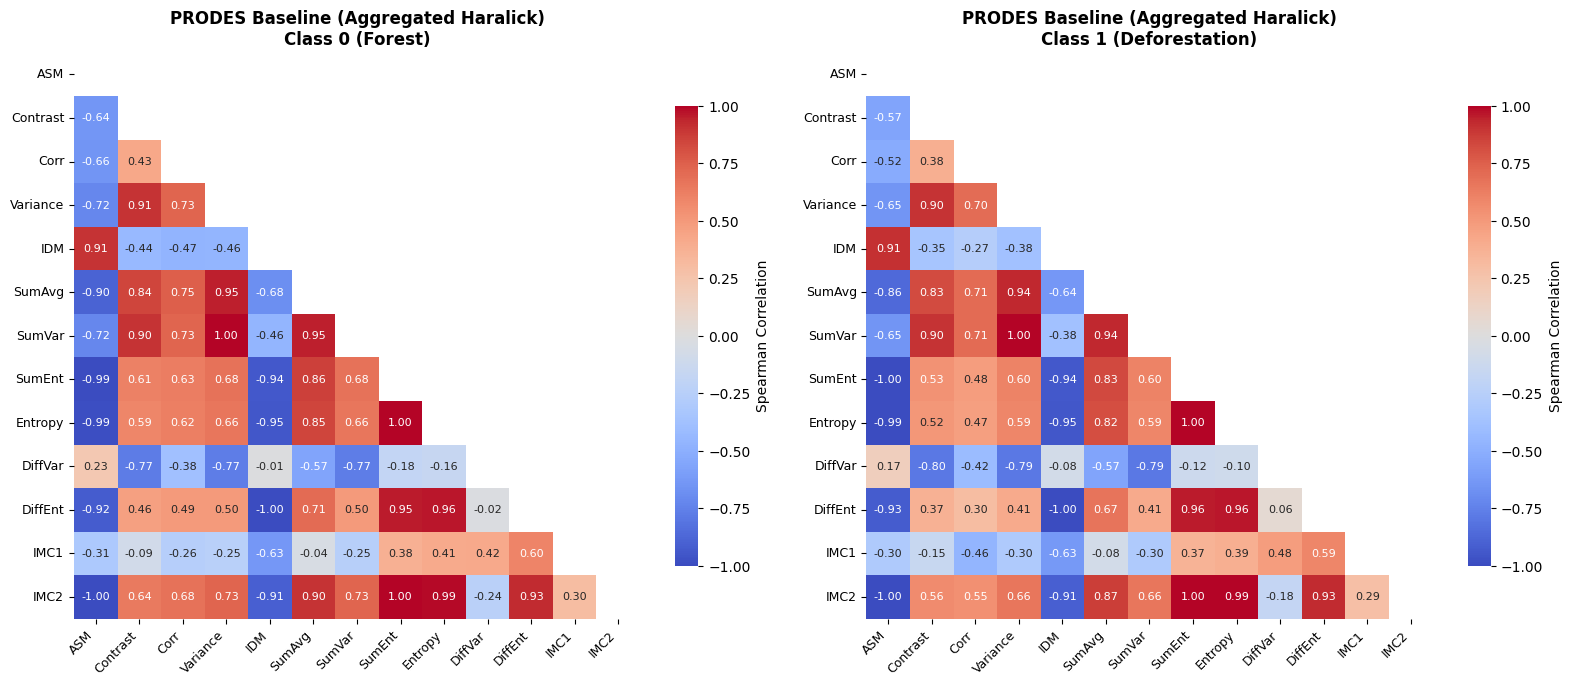


2. Best Unbalanced: Campaign-based - Tukey
----------------------------------------
  Aggregated 52 features -> 13 features (mean across 4 channels)
  Class 0 (Forest) samples: 1053
  Class 1 (Non-forest/Deforestation) samples: 706


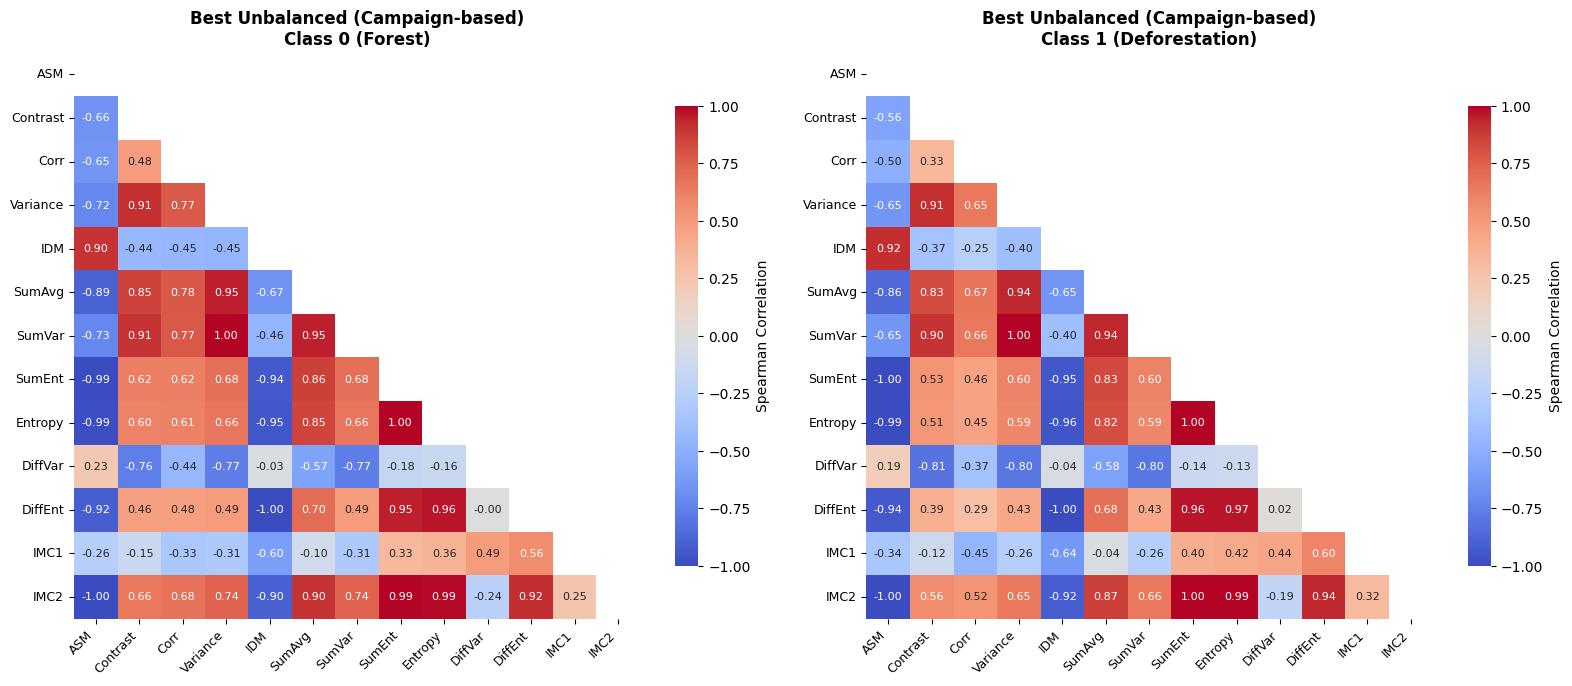


3. Best Balanced: Descending Entropy Undersample - Perc. Task
----------------------------------------
  Aggregated 52 features -> 13 features (mean across 4 channels)
  Class 0 (Forest) samples: 260
  Class 1 (Non-forest/Deforestation) samples: 260


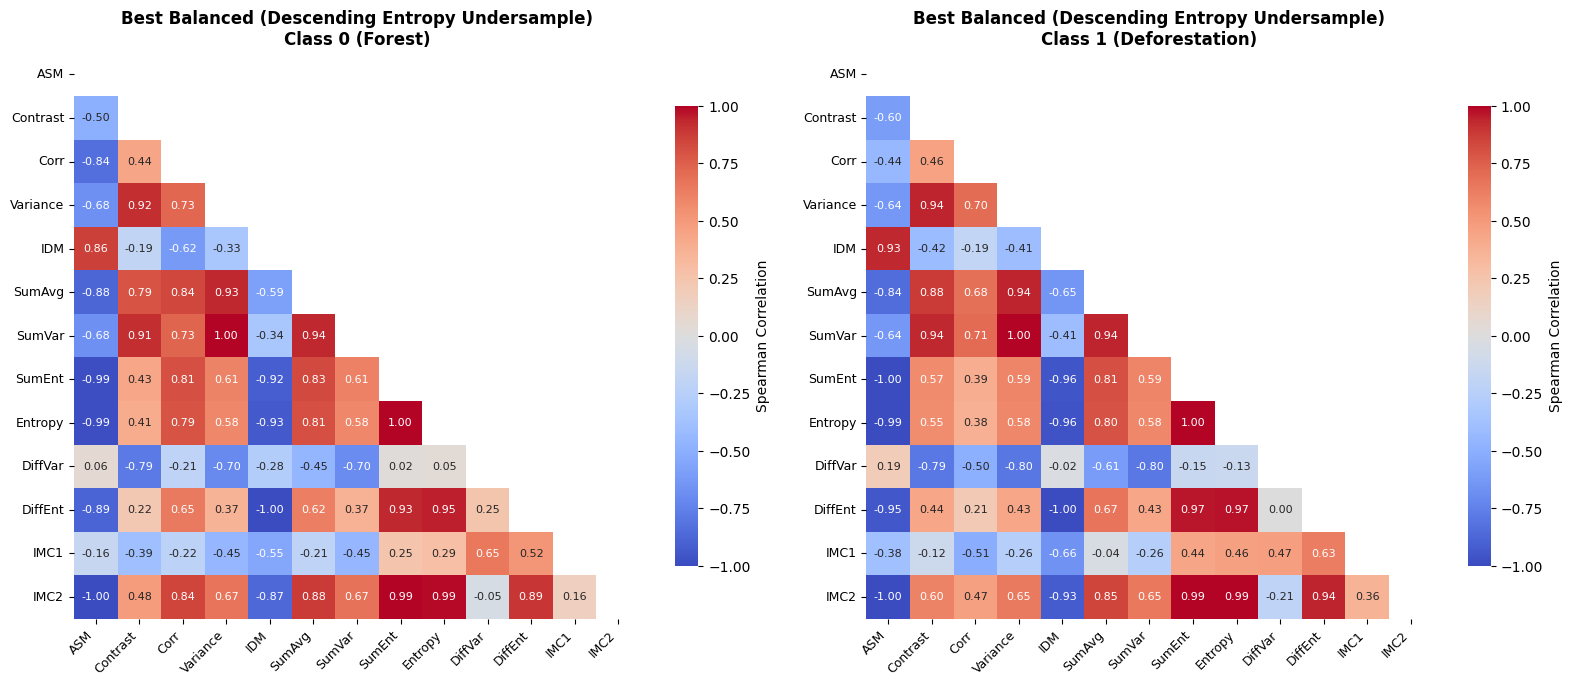


Haralick Feature Names (mahotas order):
   1. ASM        = Angular Second Moment
   2. Contrast   = Contrast
   3. Corr       = Correlation
   4. Variance   = Sum of Squares: Variance
   5. IDM        = Inverse Difference Moment
   6. SumAvg     = Sum Average
   7. SumVar     = Sum Variance
   8. SumEnt     = Sum Entropy
   9. Entropy    = Entropy
  10. DiffVar    = Difference Variance
  11. DiffEnt    = Difference Entropy
  12. IMC1       = Info Measure Corr 1
  13. IMC2       = Info Measure Corr 2


In [79]:
# Feature Aggregation: Mean across 4 channels for Haralick features
# Haralick features from mahotas library (13 features per channel)

# Mahotas Haralick feature names in order
HARALICK_NAMES = [
    'Angular Second Moment',
    'Contrast',
    'Correlation',
    'Sum of Squares: Variance',
    'Inverse Difference Moment',
    'Sum Average',
    'Sum Variance',
    'Sum Entropy',
    'Entropy',
    'Difference Variance',
    'Difference Entropy',
    'Info Measure Corr 1',
    'Info Measure Corr 2'
]

# Short names for plotting
HARALICK_SHORT_NAMES = [
    'ASM', 'Contrast', 'Corr', 'Variance', 'IDM',
    'SumAvg', 'SumVar', 'SumEnt', 'Entropy',
    'DiffVar', 'DiffEnt', 'IMC1', 'IMC2'
]

def aggregate_haralick_features(X_data, n_channels=4, n_features=13):
    """
    Aggregate Haralick features by taking the mean across channels.
    
    Parameters:
    -----------
    X_data : array-like
        Feature matrix with shape (n_samples, n_channels * n_features)
    n_channels : int
        Number of spectral channels (default: 4)
    n_features : int
        Number of Haralick features per channel (default: 13)
    
    Returns:
    --------
    X_aggregated : ndarray
        Aggregated feature matrix with shape (n_samples, n_features)
    """
    X = np.array(X_data)
    n_samples = X.shape[0]
    
    X_aggregated = np.zeros((n_samples, n_features))
    
    for feat_idx in range(n_features):
        # Collect the same feature from all channels
        channel_features = []
        for ch in range(n_channels):
            col_idx = ch * n_features + feat_idx
            channel_features.append(X[:, col_idx])
        
        # Take the mean across channels
        X_aggregated[:, feat_idx] = np.mean(channel_features, axis=0)
    
    return X_aggregated


def plot_haralick_correlation(X_data, y_data, title_prefix="Dataset", method='spearman', figsize=(16, 7)):
    """
    Plots Spearman correlation heatmaps for aggregated Haralick features.
    
    Parameters:
    -----------
    X_data : array-like
        Feature matrix (will be aggregated if 52 features, otherwise used as-is)
    y_data : array-like  
        Target labels
    title_prefix : str
        Prefix for plot titles
    method : str
        Correlation method ('spearman' or 'pearson')
    figsize : tuple
        Figure size
        
    Returns:
    --------
    corr_0, corr_1 : DataFrames
        Correlation matrices for each class
    """
    X = np.array(X_data)
    
    # Aggregate if needed (52 features -> 13 features)
    if X.shape[1] == 52:
        X_agg = aggregate_haralick_features(X)
        print(f"  Aggregated {X.shape[1]} features -> {X_agg.shape[1]} features (mean across 4 channels)")
    else:
        X_agg = X
        print(f"  Using {X_agg.shape[1]} features as-is")
    
    # Create DataFrame with named columns
    df = pd.DataFrame(X_agg, columns=HARALICK_SHORT_NAMES)
    
    # Convert labels to numeric for filtering
    if isinstance(y_data[0], str):
        label_map = {'Forest': 0, 'Non-forest': 1}
        y_numeric = np.array([label_map[label] for label in y_data])
    else:
        y_numeric = np.array(y_data)
    
    df['target'] = y_numeric
    
    # Split by class
    class_0 = df[df['target'] == 0].drop('target', axis=1)
    class_1 = df[df['target'] == 1].drop('target', axis=1)
    
    print(f"  Class 0 (Forest) samples: {len(class_0)}")
    print(f"  Class 1 (Non-forest/Deforestation) samples: {len(class_1)}")
    
    # Compute Correlations
    corr_0 = class_0.corr(method=method)
    corr_1 = class_1.corr(method=method)
    
    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Mask to hide the upper triangle
    mask = np.triu(np.ones_like(corr_0, dtype=bool))
    
    # Heatmap Class 0
    sns.heatmap(corr_0, ax=axes[0], mask=mask, cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
                annot_kws={'size': 8},
                cbar_kws={'shrink': 0.7, 'label': f'{method.capitalize()} Correlation'})
    axes[0].set_title(f'{title_prefix}\nClass 0 (Forest)', fontsize=12, fontweight='bold')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
    axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=9)
    
    # Heatmap Class 1
    sns.heatmap(corr_1, ax=axes[1], mask=mask, cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
                annot_kws={'size': 8},
                cbar_kws={'shrink': 0.7, 'label': f'{method.capitalize()} Correlation'})
    axes[1].set_title(f'{title_prefix}\nClass 1 (Deforestation)', fontsize=12, fontweight='bold')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
    axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return corr_0, corr_1


# Generate correlation heatmaps with aggregated Haralick features
print("=" * 70)
print("HARALICK FEATURE CORRELATION ANALYSIS (Mean Across 4 Channels)")
print("=" * 70)

# 1. PRODES Baseline
print("\n1. PRODES Baseline")
print("-" * 40)
corr_prodes_agg_0, corr_prodes_agg_1 = plot_haralick_correlation(
    X_train_PRODES_scaled, 
    y_train_PRODES_class, 
    title_prefix="PRODES Baseline (Aggregated Haralick)",
    method='spearman'
)

# 2. Best Unbalanced Approach
print(f"\n2. Best Unbalanced: {best_unbalanced_name} - {remove_outliers_approach_names[best_unbalanced_idx]}")
print("-" * 40)
corr_unbal_agg_0, corr_unbal_agg_1 = plot_haralick_correlation(
    X_train_best_unbalanced, 
    y_train_best_unbalanced, 
    title_prefix=f"Best Unbalanced ({best_unbalanced_name})",
    method='spearman'
)

# 3. Best Balanced Approach
print(f"\n3. Best Balanced: {best_balanced_name} - {remove_outliers_approach_names[best_balanced_idx]}")
print("-" * 40)
corr_bal_agg_0, corr_bal_agg_1 = plot_haralick_correlation(
    X_train_best_balanced, 
    y_train_best_balanced, 
    title_prefix=f"Best Balanced ({best_balanced_name})",
    method='spearman'
)

print("\n" + "=" * 70)
print("Haralick Feature Names (mahotas order):")
print("=" * 70)
for i, (short, full) in enumerate(zip(HARALICK_SHORT_NAMES, HARALICK_NAMES)):
    print(f"  {i+1:2d}. {short:10s} = {full}")
print("=" * 70)

COMBINED HARALICK CORRELATION HEATMAPS (All Approaches)


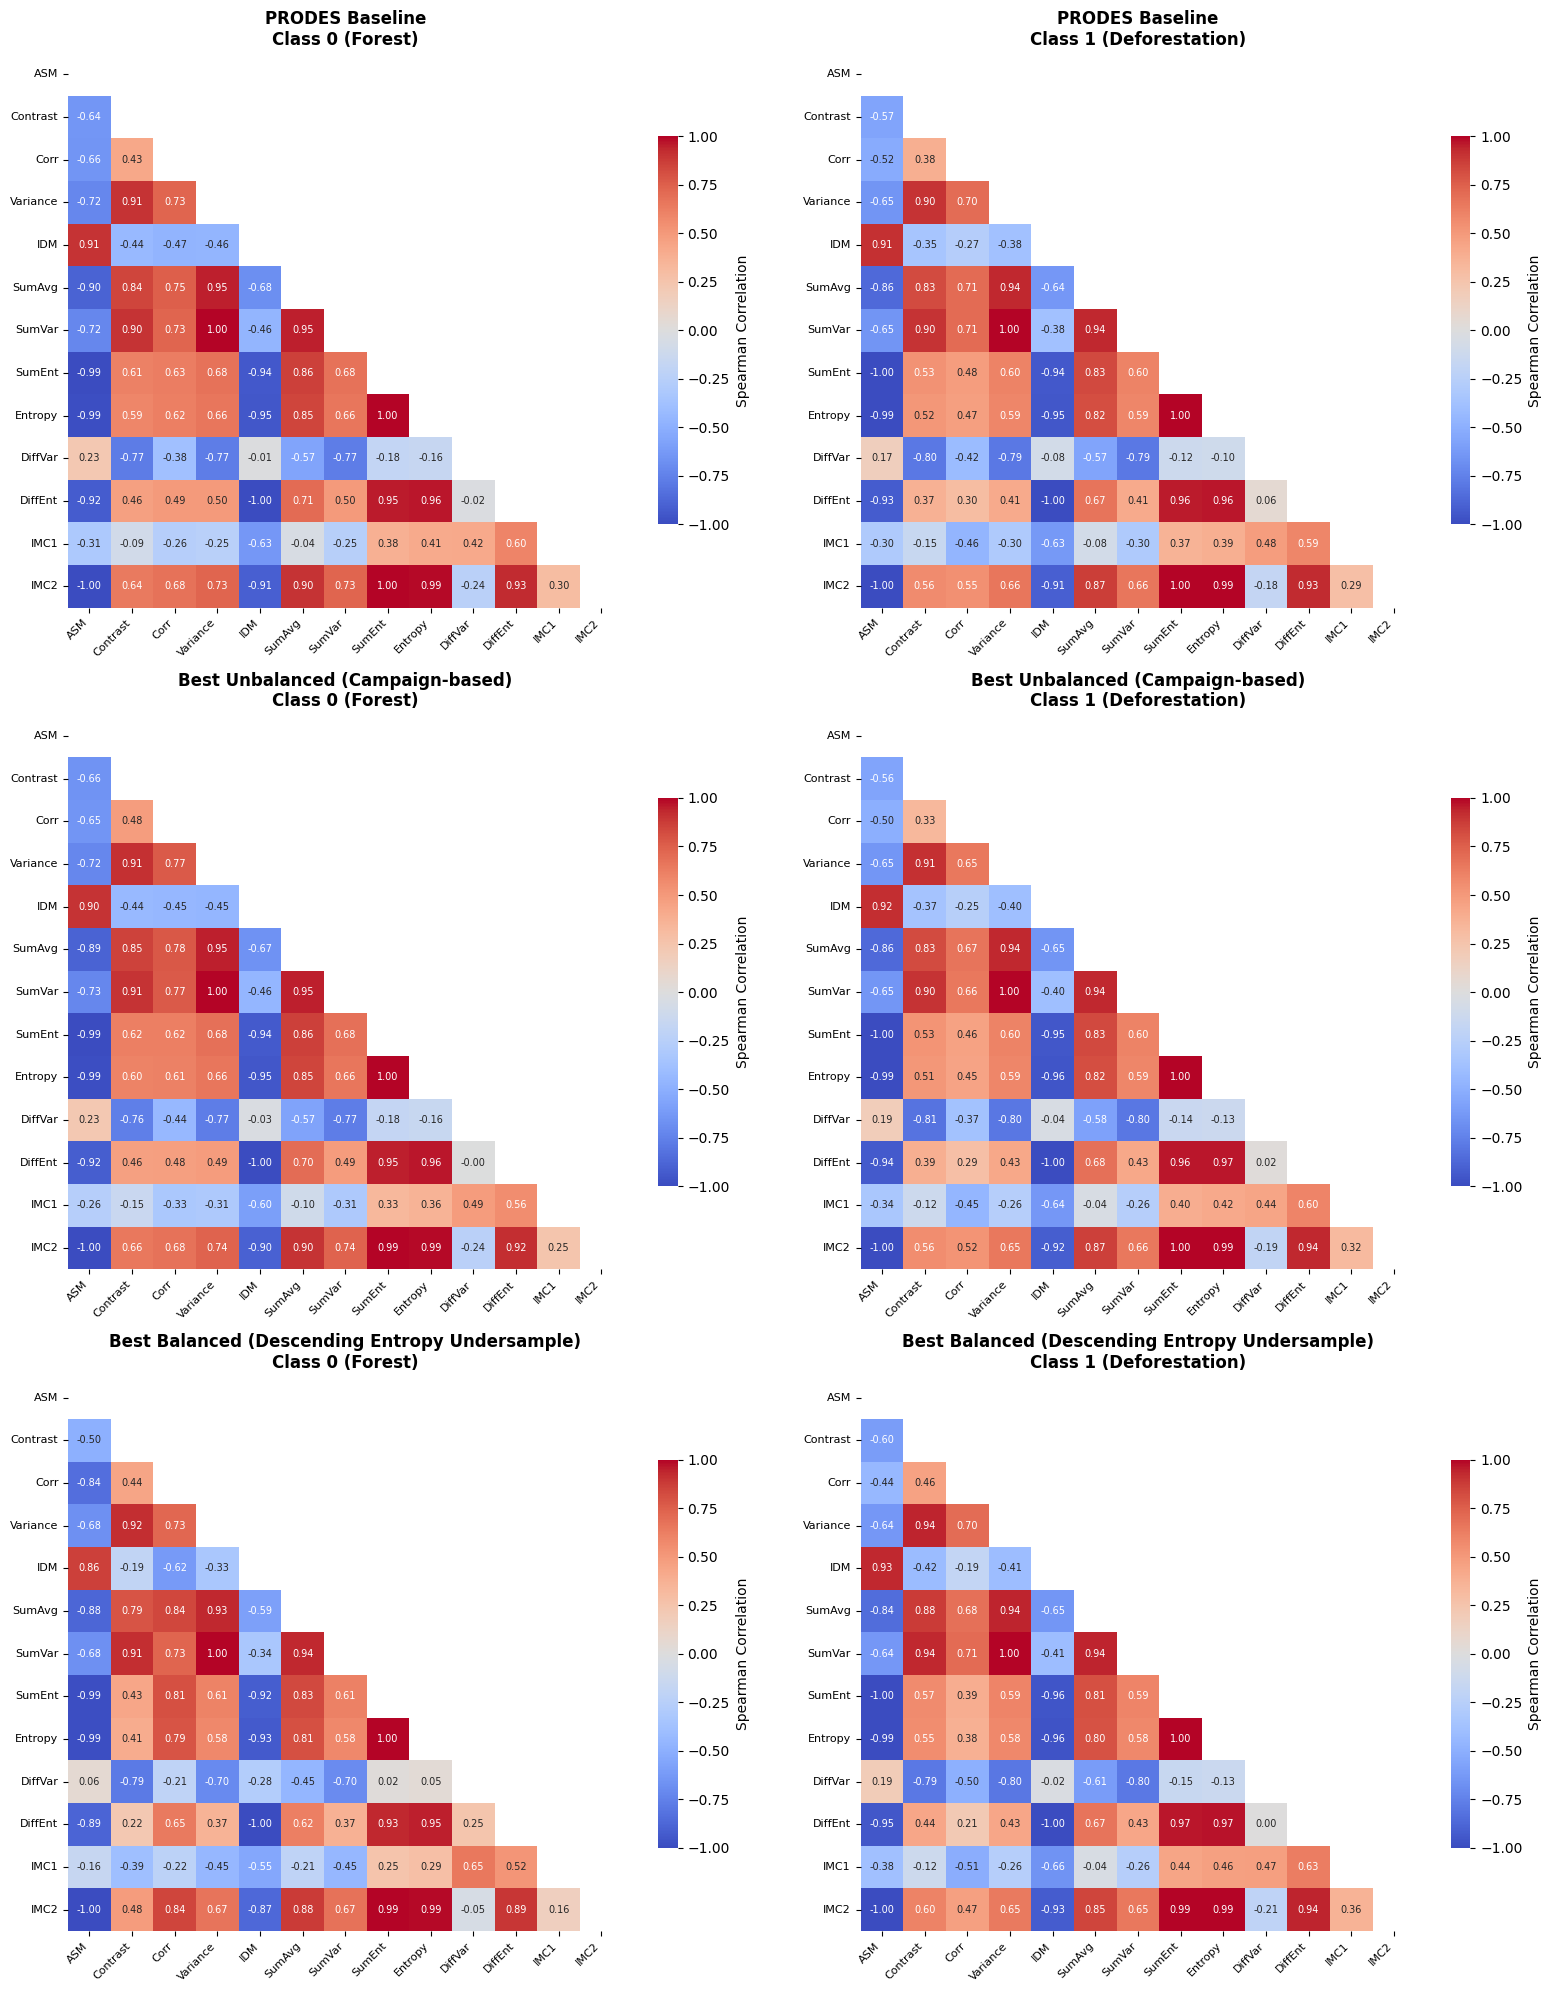


Combined visualization complete!


In [80]:
print("=" * 70)
print("COMBINED HARALICK CORRELATION HEATMAPS (All Approaches)")
print("=" * 70)

# Re-aggregate features for all approaches
def aggregate_and_get_correlations(X_data, y_data, n_channels=4, n_features=13):
    """Helper function to aggregate features and compute correlations by class."""
    X = np.array(X_data)
    
    # Aggregate if needed (52 features -> 13 features)
    if X.shape[1] == 52:
        X_agg = np.zeros((X.shape[0], n_features))
        for feat_idx in range(n_features):
            channel_features = []
            for ch in range(n_channels):
                col_idx = ch * n_features + feat_idx
                channel_features.append(X[:, col_idx])
            X_agg[:, feat_idx] = np.mean(channel_features, axis=0)
    else:
        X_agg = X
    
    # Create DataFrame with named columns
    df = pd.DataFrame(X_agg, columns=HARALICK_SHORT_NAMES)
    
    # Convert labels to numeric
    if isinstance(y_data[0], str):
        label_map = {'Forest': 0, 'Non-forest': 1}
        y_numeric = np.array([label_map[label] for label in y_data])
    else:
        y_numeric = np.array(y_data)
    
    df['target'] = y_numeric
    
    # Split by class
    class_0 = df[df['target'] == 0].drop('target', axis=1)
    class_1 = df[df['target'] == 1].drop('target', axis=1)
    
    # Compute correlations
    corr_0 = class_0.corr(method='spearman')
    corr_1 = class_1.corr(method='spearman')
    
    return corr_0, corr_1

# Compute correlations for all three approaches
prodes_corr_0, prodes_corr_1 = aggregate_and_get_correlations(X_train_PRODES_scaled, y_train_PRODES_class)
unbal_corr_0, unbal_corr_1 = aggregate_and_get_correlations(X_train_best_unbalanced, y_train_best_unbalanced)
bal_corr_0, bal_corr_1 = aggregate_and_get_correlations(X_train_best_balanced, y_train_best_balanced)

# Create a 3x2 subplot (3 approaches x 2 classes)
fig, axes = plt.subplots(3, 2, figsize=(16, 20))

# Mask for upper triangle
mask = np.triu(np.ones_like(prodes_corr_0, dtype=bool))

# Row 1: PRODES Baseline
sns.heatmap(prodes_corr_0, ax=axes[0, 0], mask=mask, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation'})
axes[0, 0].set_title('PRODES Baseline\nClass 0 (Forest)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0, 0].set_yticklabels(axes[0, 0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(prodes_corr_1, ax=axes[0, 1], mask=mask, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation'})
axes[0, 1].set_title('PRODES Baseline\nClass 1 (Deforestation)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0, 1].set_yticklabels(axes[0, 1].get_yticklabels(), rotation=0, fontsize=8)

# Row 2: Best Unbalanced
sns.heatmap(unbal_corr_0, ax=axes[1, 0], mask=mask, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation'})
axes[1, 0].set_title(f'Best Unbalanced ({best_unbalanced_name})\nClass 0 (Forest)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(unbal_corr_1, ax=axes[1, 1], mask=mask, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation'})
axes[1, 1].set_title(f'Best Unbalanced ({best_unbalanced_name})\nClass 1 (Deforestation)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1, 1].set_yticklabels(axes[1, 1].get_yticklabels(), rotation=0, fontsize=8)

# Row 3: Best Balanced
sns.heatmap(bal_corr_0, ax=axes[2, 0], mask=mask, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation'})
axes[2, 0].set_title(f'Best Balanced ({best_balanced_name})\nClass 0 (Forest)', 
                     fontsize=12, fontweight='bold')
axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[2, 0].set_yticklabels(axes[2, 0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(bal_corr_1, ax=axes[2, 1], mask=mask, cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7, 'label': 'Spearman Correlation'})
axes[2, 1].set_title(f'Best Balanced ({best_balanced_name})\nClass 1 (Deforestation)', 
                     fontsize=12, fontweight='bold')
axes[2, 1].set_xticklabels(axes[2, 1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[2, 1].set_yticklabels(axes[2, 1].get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Combined visualization complete!")
print("=" * 70)